# Predikcija nivoa rizika od raka pluća
**Master rad — Mašinsko učenje**

### Sadržaj
1. Uvoz biblioteka i konfiguracija
2. Učitavanje i priprema podataka
3. Eksplorativna analiza podataka (EDA)
4. Automatski benchmark — LazyPredict
5. Baseline evaluacija odabranih slabih modela
6. Optimizacija hiperparametara
7. Stacking Ensemble
8. Interpretabilnost modela
9. Redukcija dimenzionalnosti
10. Data leakage eksperiment
11. Zaključak i demonstracija


## 1. Uvoz biblioteka i konfiguracija

### 1.1 Instalacija

In [ ]:
# Instaliramo biblioteke koje nisu standardno dostupne u Colab okruženju.
# -q (quiet) = tiha instalacija bez ispisa svakog koraka.
!pip install -q lazypredict lime shap lightgbm statsmodels 2>&1 | tail -5

### 1.2 Uvoz svih biblioteka

In [ ]:
# ── Osnove ────────────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
from scipy.stats import spearmanr

# ── Priprema podataka evaluacija ────────────────────────────────────────
from sklearn.model_selection import (
    train_test_split, StratifiedKFold, RandomizedSearchCV,
    cross_val_score, learning_curve
)
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay
)
from sklearn.inspection import permutation_importance
from sklearn.feature_selection import SelectKBest, f_classif, mutual_info_classif, RFECV
from sklearn.decomposition import PCA
from sklearn.base import clone
from sklearn.pipeline import Pipeline

# ── Baseline (slabi) modeli ────────────────────────────────────────────────
from sklearn.naive_bayes import GaussianNB
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import RidgeClassifier, LogisticRegression
from sklearn.neighbors import NearestCentroid
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

# ── Jaki modeli (samo za Stacking Ensemble u Poglavlju 7) ─────────────────
from sklearn.ensemble import (
    RandomForestClassifier, ExtraTreesClassifier,
    BaggingClassifier, StackingClassifier
)
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

# ── AutoML benchmark ───────────────────────────────────────────────────────
from lazypredict.Supervised import LazyClassifier

# ── Interpretabilnost ──────────────────────────────────────────────────────
import lime
import lime.lime_tabular
from lime.lime_tabular import LimeTabularExplainer
import shap

# ── Statistički testovi ────────────────────────────────────────────────────
from statsmodels.stats.contingency_tables import mcnemar

# ── Čuvanje modela ─────────────────────────────────────────────────────────
import joblib

print("Sve biblioteke uvezene.")

Sve biblioteke uvezene.


### 1.3 Globalna konfiguracija

In [ ]:
# RANDOM_STATE = 42: fiksira nasumičnost — svako pokretanje daje iste rezultate.
# Bez ovoga, algoritmi koji koriste slučajne brojeve bi davali drugačije
# rezultate svaki put, što onemogućava reproducibilnost naučnog rada.
warnings.filterwarnings('ignore')
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 11
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.titleweight'] = 'bold'

pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 200)
pd.set_option('display.float_format', '{:.4f}'.format)

print(f"NumPy: {np.__version__} | Pandas: {pd.__version__}")
print(f"RANDOM_STATE: {RANDOM_STATE}")

NumPy: 2.1.3 | Pandas: 2.2.3
RANDOM_STATE: 42


### 1.4 Globalni tracker rezultata

In [ ]:
# DataFrame koji punimo rezultatima svakog modela kroz projekat.
# Na kraju (Poglavlje 11) imamo kompletnu istoriju svih modela na jednom mestu.
result_df = pd.DataFrame(columns=[
    'Model', 'Type', 'Accuracy', 'F1_Weighted',
    'Precision_Weighted', 'Recall_Weighted',
    'F1_Low', 'F1_Medium', 'F1_High'
])
print(f"Tracker inicijalizovan ({len(result_df.columns)} kolona).")

Tracker inicijalizovan (9 kolona).


---
## 2. Učitavanje i priprema podataka

Prije nego što treniramo bilo koji model, moramo učitati i pripremiti podatke.
Loši podaci = loš model, ma koliko dobar algoritam koristili.


### 2.1 Google Drive i učitavanje

In [ ]:
# try/except: pokušavamo montirati Drive (Colab), ako ne uspije (lokalno) — preskačemo.
# Ovako isti kod radi i na Colabu i lokalno bez izmjena.
try:
    from google.colab import drive
    drive.mount('/content/drive')
    IN_COLAB = True
    print("Google Drive montiran.")
except ImportError:
    IN_COLAB = False
    print("Lokalno okruženje — preskačemo Drive montiranje.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Google Drive montiran.


In [ ]:
# Prilagoditi putanju prema svojoj strukturi foldera na Google Drive-u.
DATA_PATH = '/content/drive/MyDrive/Colab_Notebooks/ML/Lung_Cancer_Prediction/cancer patient data sets.csv'

dataset = pd.read_csv(DATA_PATH)
print(f"Dataset učitan: {dataset.shape[0]} redova × {dataset.shape[1]} kolona")
print(f"Memorija: {dataset.memory_usage(deep=True).sum() / 1024:.1f} KB")
dataset.head(5)

Dataset učitan: 1000 redova × 26 kolona
Memorija: 291.4 KB


,index,Patient Id,Age,Gender,Air Pollution,Alcohol use,Dust Allergy,OccuPational Hazards,Genetic Risk,chronic Lung Disease,Balanced Diet,Obesity,Smoking,Passive Smoker,Chest Pain,Coughing of Blood,Fatigue,Weight Loss,Shortness of Breath,Wheezing,Swallowing Difficulty,Clubbing of Finger Nails,Frequent Cold,Dry Cough,Snoring,Level
0,0,P1,33,1,2,4,5,4,3,2,2,4,3,2,2,4,3,4,2,2,3,1,2,3,4,Low
1,1,P10,17,1,3,1,5,3,4,2,2,2,2,4,2,3,1,3,7,8,6,2,1,7,2,Medium
2,2,P100,35,1,4,5,6,5,5,4,6,7,2,3,4,8,8,7,9,2,1,4,6,7,2,High
3,3,P1000,37,1,7,7,7,7,6,7,7,7,7,7,7,8,4,2,3,1,4,5,6,7,5,High
4,4,P101,46,1,6,8,7,7,7,6,7,7,8,7,7,9,3,2,4,1,4,2,4,2,3,High


In [ ]:
# info() prikazuje tipove podataka i broj non-null vrijednosti po koloni.
# Brza provera: ima li praznih mesta, jesu li tipovi ispravni.
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 26 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   index                     1000 non-null   int64 
 1   Patient Id                1000 non-null   object
 2   Age                       1000 non-null   int64 
 3   Gender                    1000 non-null   int64 
 4   Air Pollution             1000 non-null   int64 
 5   Alcohol use               1000 non-null   int64 
 6   Dust Allergy              1000 non-null   int64 
 7   OccuPational Hazards      1000 non-null   int64 
 8   Genetic Risk              1000 non-null   int64 
 9   chronic Lung Disease      1000 non-null   int64 
 10  Balanced Diet             1000 non-null   int64 
 11  Obesity                   1000 non-null   int64 
 12  Smoking                   1000 non-null   int64 
 13  Passive Smoker            1000 non-null   int64 
 14  Chest Pain               

In [ ]:
# describe() daje deskriptivne statistike: min, max, prosjek, std, kvartile.
# Koristimo da vidimo raspone vrednosti i otkrijemo moguće anomalije.
dataset.describe()

,index,Age,Gender,Air Pollution,Alcohol use,Dust Allergy,OccuPational Hazards,Genetic Risk,chronic Lung Disease,Balanced Diet,Obesity,Smoking,Passive Smoker,Chest Pain,Coughing of Blood,Fatigue,Weight Loss,Shortness of Breath,Wheezing,Swallowing Difficulty,Clubbing of Finger Nails,Frequent Cold,Dry Cough,Snoring
count,1000.0000,1000.0000,1000.0000,1000.0000,1000.0000,1000.0000,1000.0000,1000.0000,1000.0000,1000.0000,1000.0000,1000.0000,1000.0000,1000.0000,1000.0000,1000.0000,1000.0000,1000.0000,1000.0000,1000.0000,1000.0000,1000.0000,1000.0000,1000.0000
mean,499.5000,37.1740,1.4020,3.8400,4.5630,5.1650,4.8400,4.5800,4.3800,4.4910,4.4650,3.9480,4.1950,4.4380,4.8590,3.8560,3.8550,4.2400,3.7770,3.7460,3.9230,3.5360,3.8530,2.9260
std,288.8194,12.0055,0.4905,2.0304,2.6205,1.9808,2.1078,2.1270,1.8485,2.1355,2.1249,2.4959,2.3118,2.2802,2.4280,2.2446,2.2065,2.2851,2.0419,2.2704,2.3880,1.8325,2.0390,1.4747
min,0.0000,14.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000
25%,249.7500,27.7500,1.0000,2.0000,2.0000,4.0000,3.0000,2.0000,3.0000,2.0000,3.0000,2.0000,2.0000,2.0000,3.0000,2.0000,2.0000,2.0000,2.0000,2.0000,2.0000,2.0000,2.0000,2.0000
50%,499.5000,36.0000,1.0000,3.0000,5.0000,6.0000,5.0000,5.0000,4.0000,4.0000,4.0000,3.0000,4.0000,4.0000,4.0000,3.0000,3.0000,4.0000,4.0000,4.0000,4.0000,3.0000,4.0000,3.0000
75%,749.2500,45.0000,2.0000,6.0000,7.0000,7.0000,7.0000,7.0000,6.0000,7.0000,7.0000,7.0000,7.0000,7.0000,7.0000,5.0000,6.0000,6.0000,5.0000,5.0000,5.0000,5.0000,6.0000,4.0000
max,999.0000,73.0000,2.0000,8.0000,8.0000,8.0000,8.0000,7.0000,7.0000,7.0000,7.0000,8.0000,8.0000,9.0000,9.0000,9.0000,8.0000,9.0000,8.0000,8.0000,9.0000,7.0000,7.0000,7.0000


### 2.2 Čišćenje podataka

In [ ]:
# Izbacujemo identifikatore koji ne nose informaciju o bolesti.
# 'index' = redni broj, 'Patient Id' = string identifikator.
# Ako bismo ih ostavili, model bi mogao naučiti "pacijent P42 = High rizik" —
# što je besmisleno za novog pacijenta kojeg nikad nije video.
dataset = dataset.drop(columns=['index', 'Patient Id'])
print(f"Dimenzije nakon izbacivanja identifikatora: {dataset.shape}")

Dimenzije nakon izbacivanja identifikatora: (1000, 24)


In [ ]:
# Provera null (praznih) vrednosti.
# Scikit-learn ne može trenirati model na podacima s praznim mestima.
null_counts = dataset.isnull().sum()
total_nulls = null_counts.sum()
if total_nulls == 0:
    print(f"Null vrijednosti: 0 — imputacija nije potrebna.")
else:
    print(f"PROBLEM — null vrijednosti: {total_nulls}")
    print(null_counts[null_counts > 0])

Null vrijednosti: 0 — imputacija nije potrebna.


In [ ]:
# Provera duplikata (identičnih redova).
# Duplikat = isti pacijent se pojavljuje više puta.
# UPOZORENJE: visok procenat duplikata uzrokuje data leakage — detalji u Poglavlju 10.
n_dup = dataset.duplicated().sum()
n_total = len(dataset)
n_unique = n_total - n_dup
print(f"Ukupno redova:     {n_total}")
print(f"Duplikati:         {n_dup} ({n_dup/n_total*100:.1f}%)")
print(f"Jedinstveni redovi: {n_unique}")
print()
print("UPOZORENJE: visok procenat duplikata znači da isti pacijent")
print("može biti i u train i u test setu — analiza u Poglavlju 10!")

Ukupno redova:     1000
Duplikati:         848 (84.8%)
Jedinstveni redovi: 152

UPOZORENJE: visok procenat duplikata znači da isti pacijent
može biti i u train i u test setu — analiza u Poglavlju 10!


### 2.3 Enkodiranje target varijable i podjela

In [ ]:
# Pretvaramo tekstualne oznake u brojeve jer algoritmi rade samo s brojevima.
# Koristimo ORDINALNO enkodiranje (0/1/2) jer postoji prirodan redosled: Low < Medium < High.
# One-hot encoding (0/1 po koloni) ne bi sačuvao taj redosled.
level_mapping = {'Low': 0, 'Medium': 1, 'High': 2}
level_mapping_reverse = {0: 'Low', 1: 'Medium', 2: 'High'}

before = dataset['Level'].value_counts()
dataset['Level'] = dataset['Level'].map(level_mapping)
after = dataset['Level'].value_counts().sort_index()

enc_df = pd.DataFrame({
    'Klasa': ['Low', 'Medium', 'High'],
    'Enkodirana vrijednost': [0, 1, 2],
    'Broj primjera': [after.get(i, 0) for i in [0, 1, 2]]
})
display(enc_df)

X = dataset.drop(columns=['Level'])
y = dataset['Level']
CLASS_NAMES = ['Low', 'Medium', 'High']
FEATURE_NAMES = X.columns.tolist()

print(f"\nX (feature-i): {X.shape}")
print(f"y (target):    {y.shape}")
print(f"Feature-i ({len(FEATURE_NAMES)}): {FEATURE_NAMES}")

,Klasa,Enkodirana vrijednost,Broj primjera
0,Low,0,303
1,Medium,1,332
2,High,2,365



X (feature-i): (1000, 23)
y (target):    (1000,)
Feature-i (23): ['Age', 'Gender', 'Air Pollution', 'Alcohol use', 'Dust Allergy', 'OccuPational Hazards', 'Genetic Risk', 'chronic Lung Disease', 'Balanced Diet', 'Obesity', 'Smoking', 'Passive Smoker', 'Chest Pain', 'Coughing of Blood', 'Fatigue', 'Weight Loss', 'Shortness of Breath', 'Wheezing', 'Swallowing Difficulty', 'Clubbing of Finger Nails', 'Frequent Cold', 'Dry Cough', 'Snoring']


In [ ]:
# Train/test split: 80% za učenje, 20% za testiranje.
# stratify=y: oba seta imaju iste proporcije klasa — sprečava slučajnu neravnotežu.
# random_state=42: reproducibilna podjela.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)
print(f"X_train: {X_train.shape} | X_test: {X_test.shape}")

# Provjera stratifikacije: proporcije klasa trebaju biti iste u oba seta.
split_check = pd.DataFrame({
    'Klasa': CLASS_NAMES,
    'Train (n)':  [(y_train == c).sum() for c in [0,1,2]],
    'Test (n)':   [(y_test  == c).sum() for c in [0,1,2]],
    'Train (%)':  [(y_train == c).mean()*100 for c in [0,1,2]],
    'Test (%)':   [(y_test  == c).mean()*100 for c in [0,1,2]]
}).round(1)
display(split_check)

X_train: (800, 23) | X_test: (200, 23)


,Klasa,Train (n),Test (n),Train (%),Test (%)
0,Low,242,61,30.2000,30.5000
1,Medium,266,66,33.2000,33.0000
2,High,292,73,36.5000,36.5000


---
## 3. Eksplorativna analiza podataka (EDA)

EDA znači: gledamo i razumemo podatke PRE modelovanja.
Kao detektiv koji istražuje scenu pre nego što izvede zaključak.
Cilj: otkriti distribucije, veze između feature-a i potencijalne probleme.


### 3.1 Distribucija ciljne varijable

,Klasa,N,%
0,Low,303,30.3000
1,Medium,332,33.2000
2,High,365,36.5000


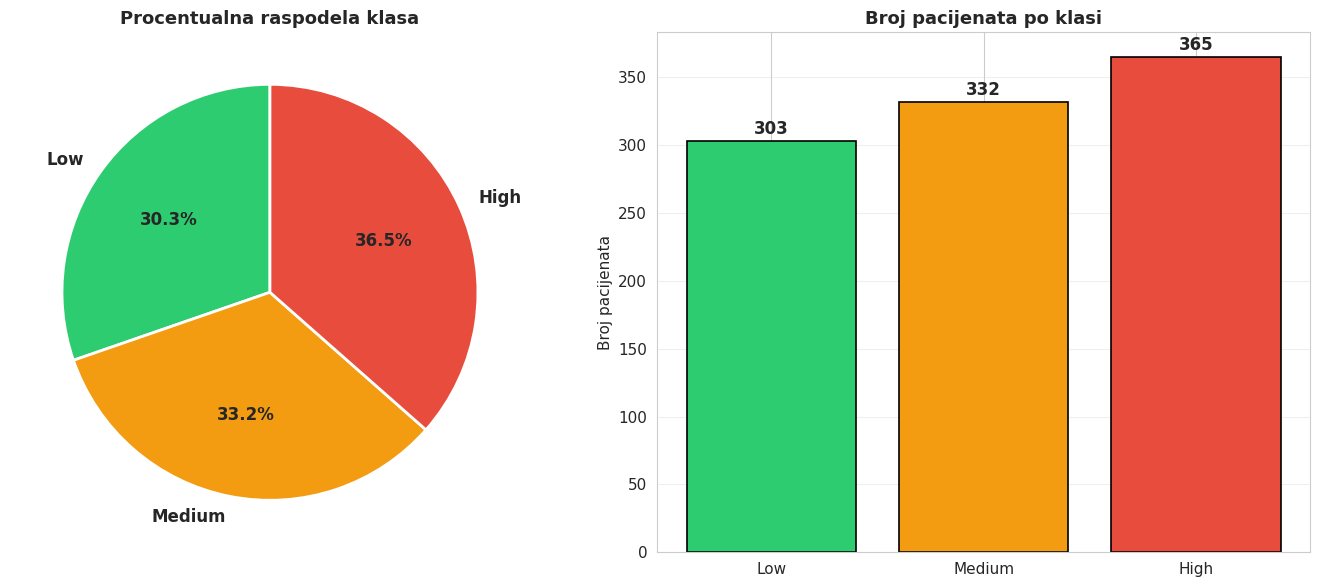

Imbalance ratio: 1.20 — balansirano
Zaključak: F1-weighted je ispravna metrika, SMOTE nije neophodan.


In [ ]:
# Koliko pacijenata ima svaki nivo rizika?
# Ako je jedna klasa dominantna (npr. 90% Low), model bi mogao uvek
# predviđati Low i imati 90% tačnosti — ali zapravo ništa ne bi radio.
target_counts = dataset['Level'].value_counts().sort_index()
target_pct = (target_counts / len(dataset) * 100).round(2)

summary = pd.DataFrame({
    'Klasa': CLASS_NAMES,
    'N': target_counts.values,
    '%': target_pct.values
})
display(summary)

colors = ['#2ecc71', '#f39c12', '#e74c3c']
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].pie(target_counts.values, labels=CLASS_NAMES, autopct='%1.1f%%',
            colors=colors, startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2},
            textprops={'fontsize': 12, 'fontweight': 'bold'})
axes[0].set_title('Procentualna raspodela klasa')

bars = axes[1].bar(CLASS_NAMES, target_counts.values, color=colors,
                   edgecolor='black', linewidth=1.2)
axes[1].set_title('Broj pacijenata po klasi')
axes[1].set_ylabel('Broj pacijenata')
axes[1].grid(axis='y', alpha=0.3)
for bar, v in zip(bars, target_counts.values):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+5,
                 str(v), ha='center', fontweight='bold', fontsize=12)
plt.tight_layout(); plt.show()

ratio = target_counts.max() / target_counts.min()
label = 'balansirano' if ratio < 1.5 else 'blago neizbalansirano' if ratio < 3 else 'jako neizbalansirano'
print(f"Imbalance ratio: {ratio:.2f} — {label}")
print("Zaključak: F1-weighted je ispravna metrika, SMOTE nije neophodan.")

### 3.2 Histogrami svih feature-a

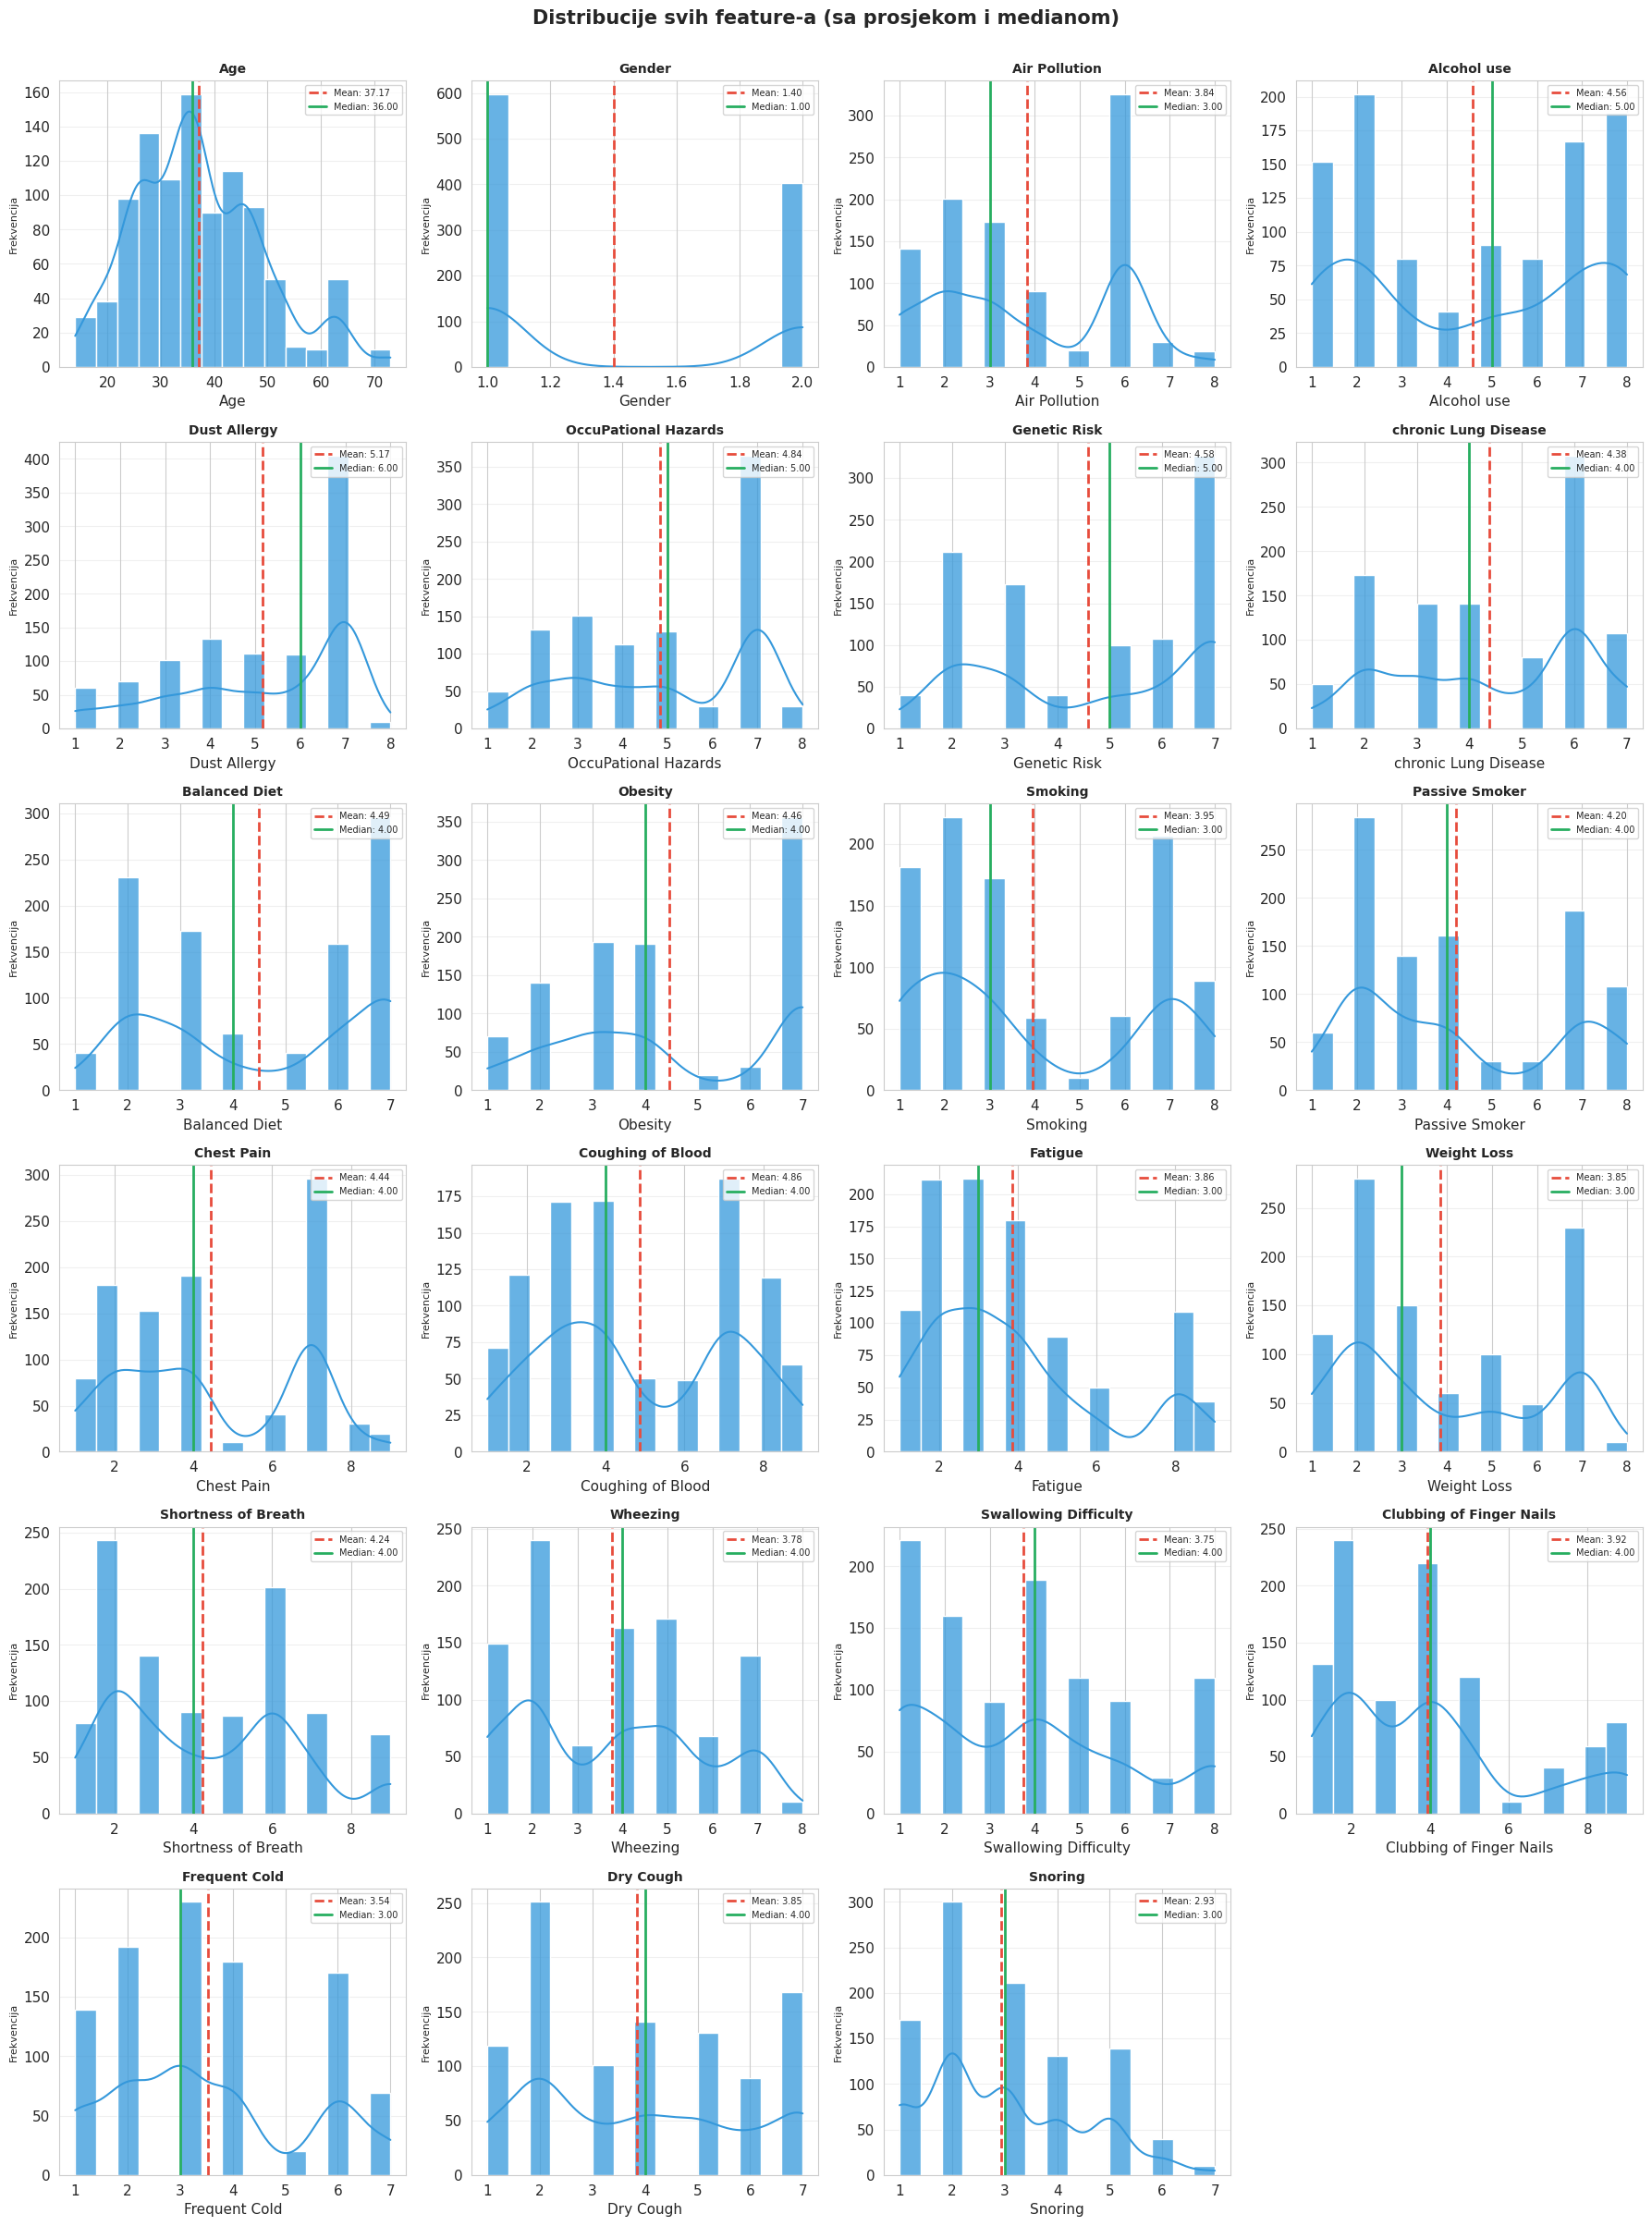

In [ ]:
# Prikazujemo distribuciju svake feature-a sa KDE krivom, prosekom i medianom.
# KDE (Kernel Density Estimate) = izglađena kriva distribucije.
# Razlika prosek vs medijan ukazuje na asimetriju distribucije.
feature_cols = X.columns.tolist()
n_features = len(feature_cols)
n_cols_plot = 4
n_rows_plot = int(np.ceil(n_features / n_cols_plot))

fig, axes = plt.subplots(n_rows_plot, n_cols_plot,
                         figsize=(18, 4 * n_rows_plot))
axes = axes.flatten()

for i, col in enumerate(feature_cols):
    ax = axes[i]
    data = dataset[col]
    sns.histplot(data, kde=True, ax=ax, color='#3498db',
                 edgecolor='white', alpha=0.75, bins=15)
    mean_val = data.mean()
    med_val  = data.median()
    ax.axvline(mean_val, color='#e74c3c', linestyle='--',
               linewidth=2, label=f'Mean: {mean_val:.2f}')
    ax.axvline(med_val,  color='#27ae60', linestyle='-',
               linewidth=2, label=f'Median: {med_val:.2f}')
    ax.set_title(col, fontsize=10, fontweight='bold')
    ax.set_ylabel('Frekvencija', fontsize=8)
    ax.legend(fontsize=7, loc='upper right')
    ax.grid(axis='y', alpha=0.3)

for j in range(n_features, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Distribucije svih feature-a (sa prosjekom i medianom)',
             fontsize=15, fontweight='bold', y=1.002)
plt.tight_layout(); plt.show()

### 3.3 Boxplotovi po klasama rizika

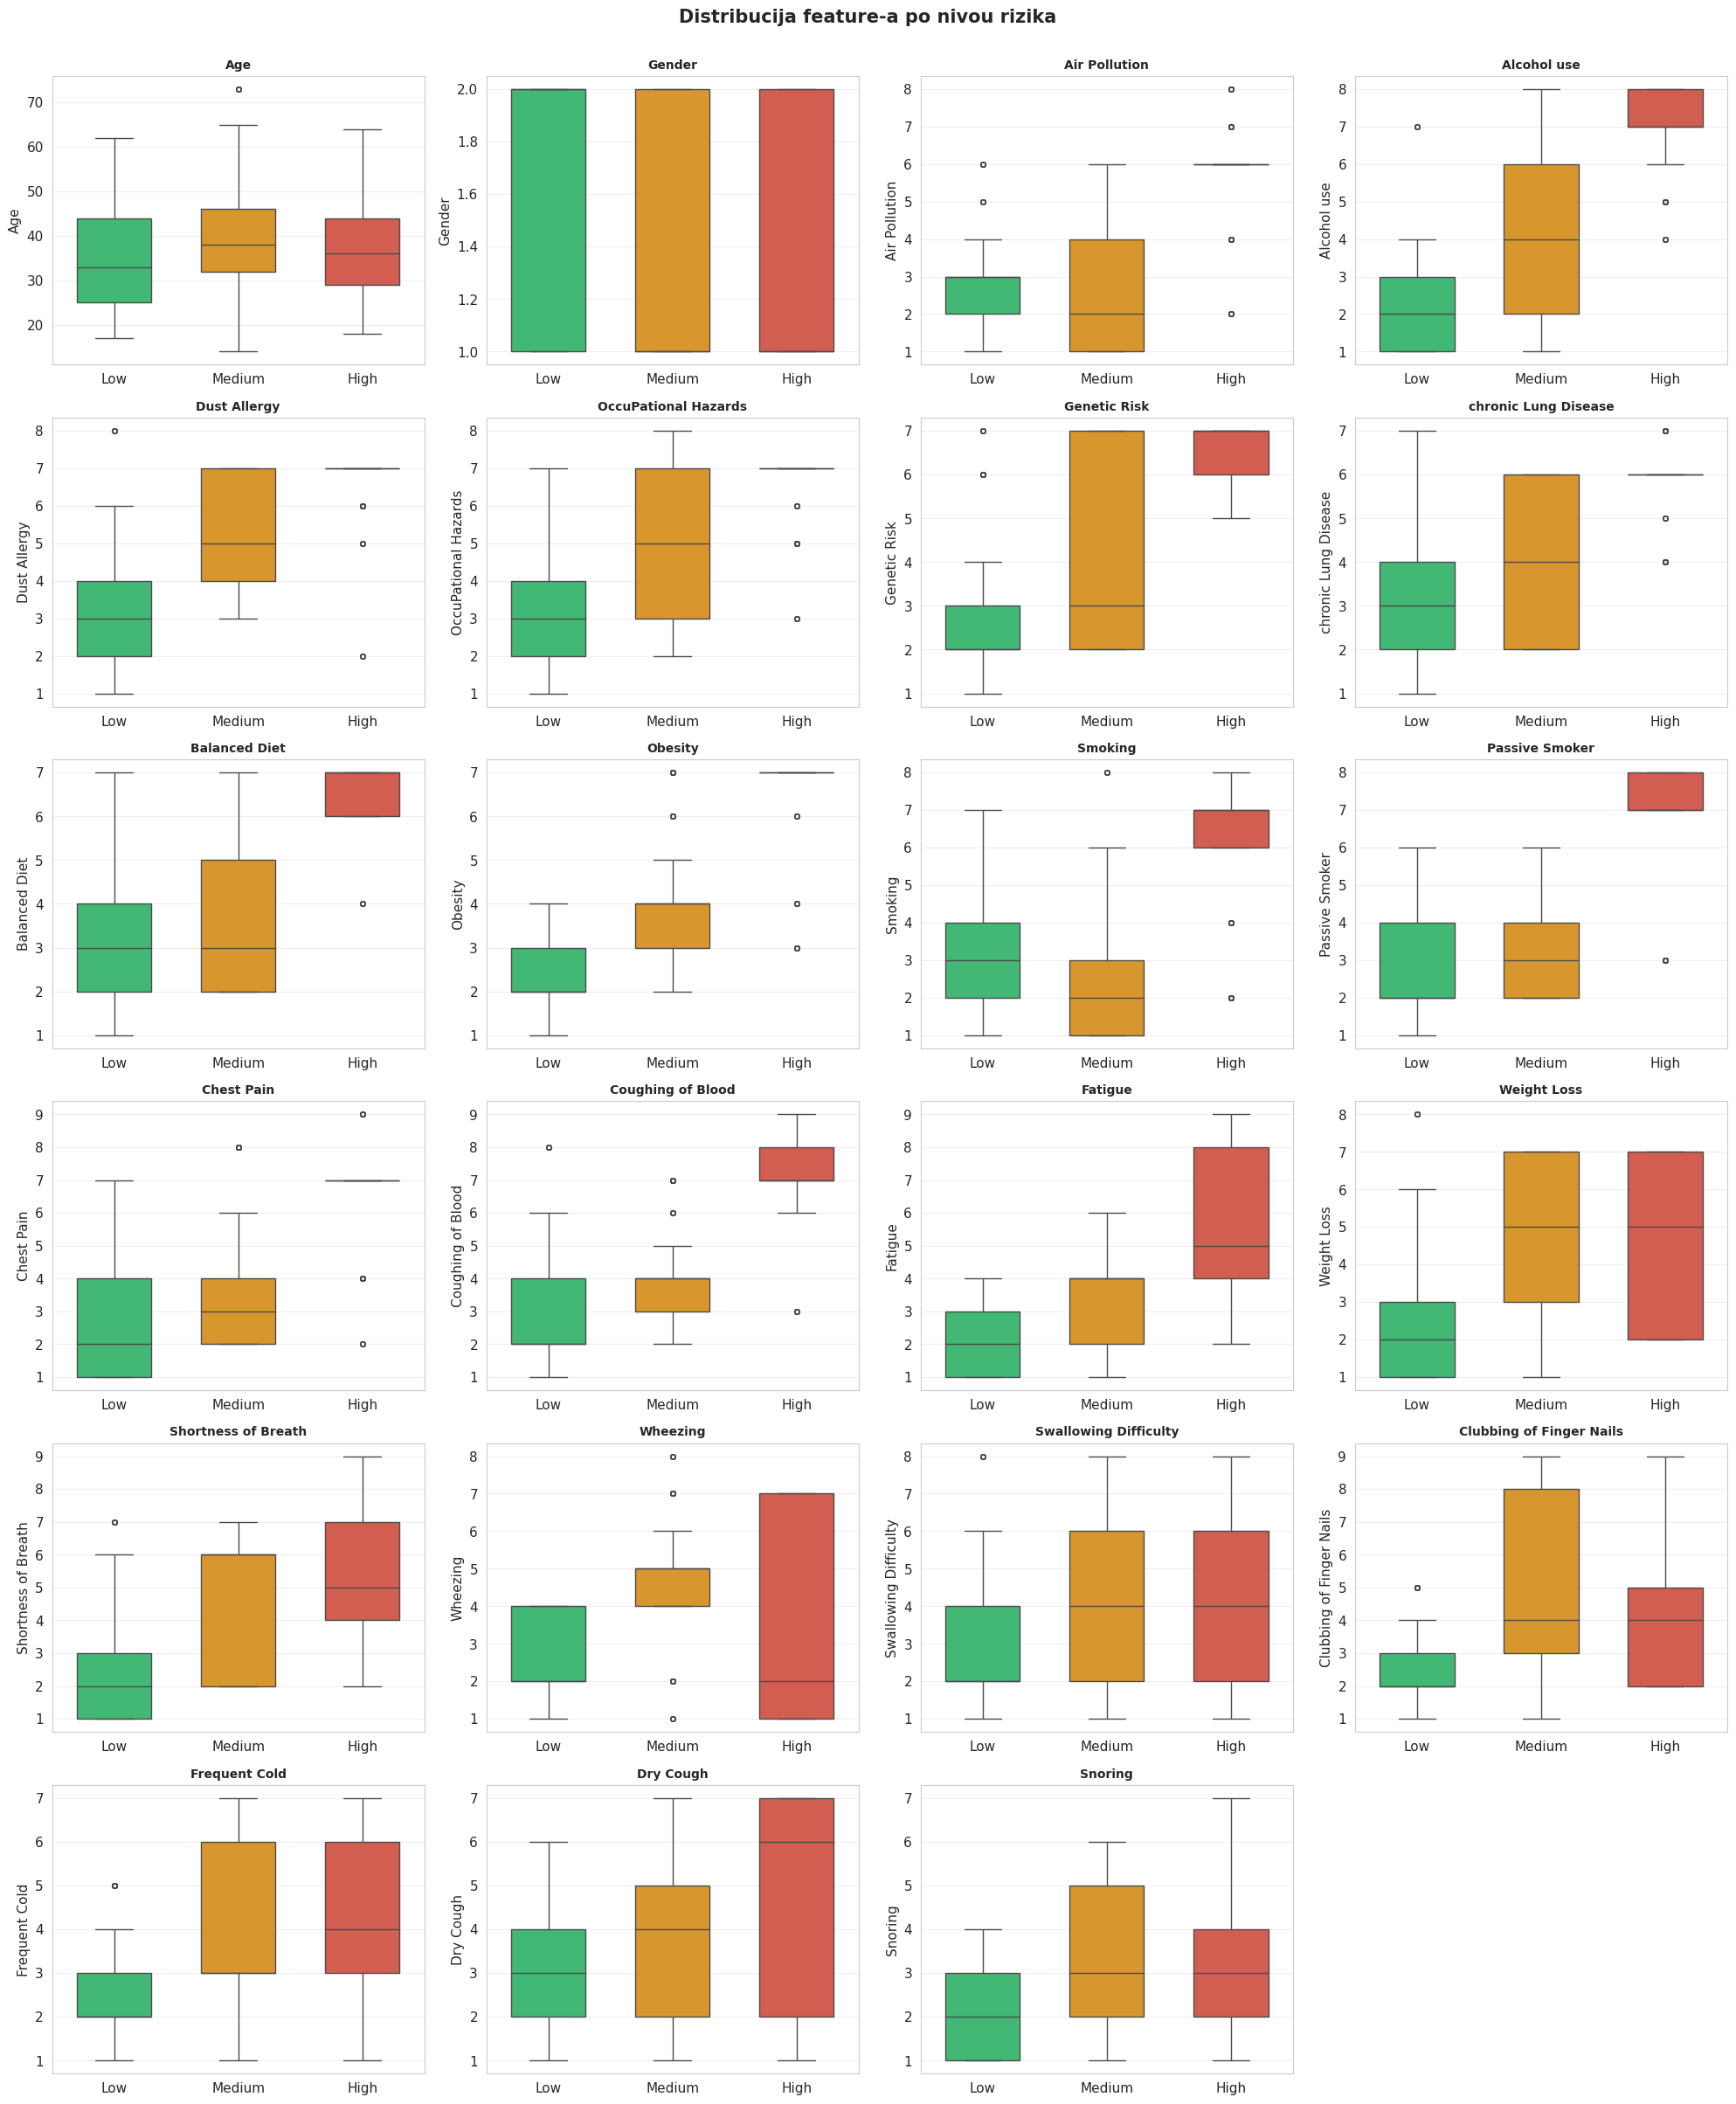

In [ ]:
# Boxplot po klasama pokazuje koliko svaki feature razdvaja Low/Medium/High.
# Dobra separacija kutija = feature koristan za klasifikaciju.
# Preklapanje kutija = feature sam za sebe ne pomaže (ali može kroz kombinacije).
plot_df = dataset.copy()
plot_df['Risk Level'] = plot_df['Level'].map(level_mapping_reverse)
order = ['Low', 'Medium', 'High']
palette = {'Low': '#2ecc71', 'Medium': '#f39c12', 'High': '#e74c3c'}

fig, axes = plt.subplots(n_rows_plot, n_cols_plot,
                         figsize=(20, 4 * n_rows_plot))
axes = axes.flatten()

for i, col in enumerate(feature_cols):
    ax = axes[i]
    sns.boxplot(data=plot_df, x='Risk Level', y=col,
                order=order, palette=palette, ax=ax, width=0.6,
                flierprops={'marker':'o','markersize':4,'alpha':0.5})
    ax.set_title(col, fontsize=10, fontweight='bold')
    ax.set_xlabel('')
    ax.grid(axis='y', alpha=0.3)

for j in range(n_features, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Distribucija feature-a po nivou rizika',
             fontsize=15, fontweight='bold', y=1.002)
plt.tight_layout(); plt.show()

### 3.4 Spearman korelaciona matrica

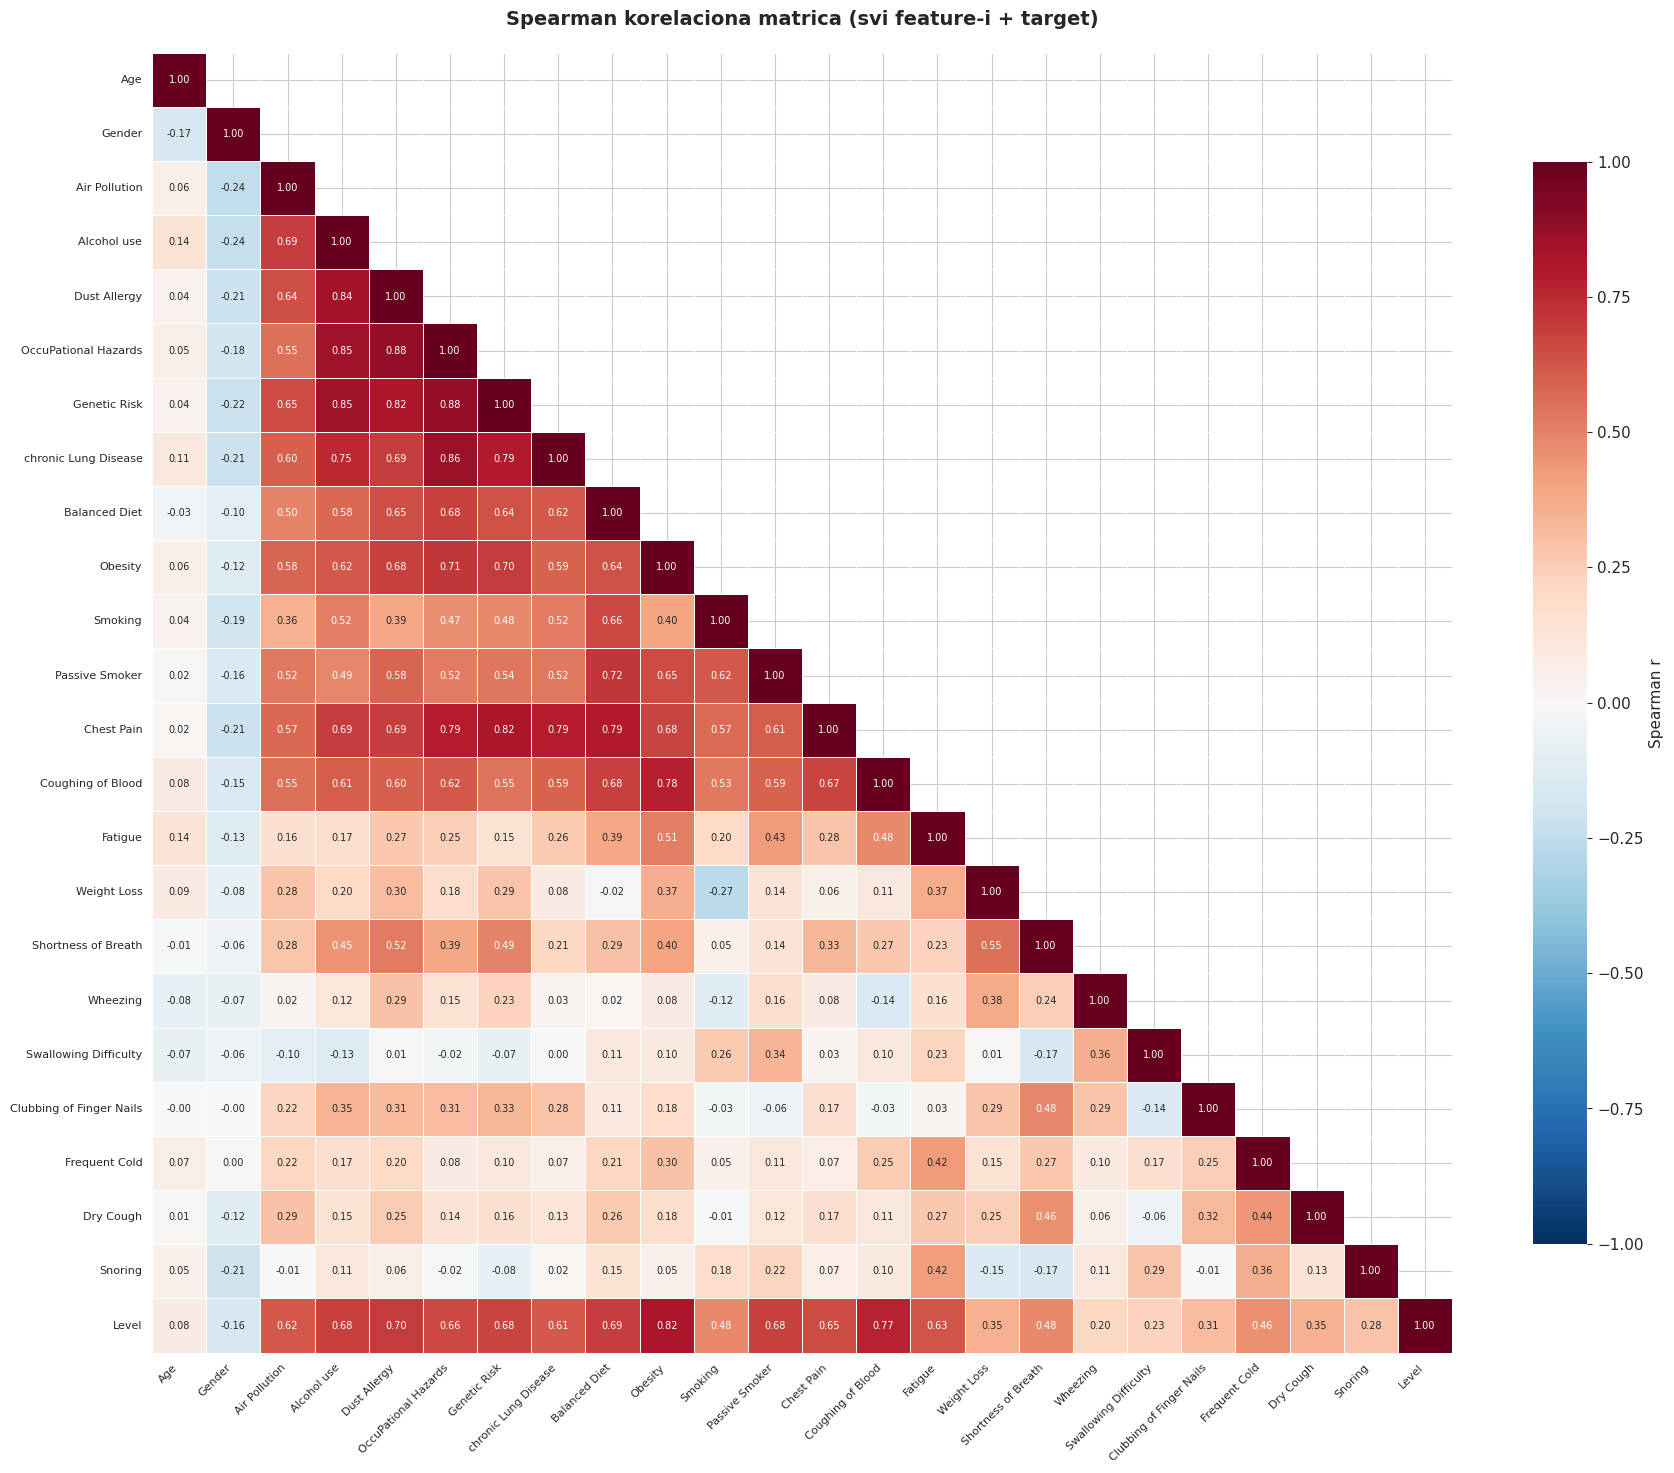

Parovi s visokom korelacijom (|r| > 0.7): 17


,Feature 1,Feature 2,Spearman r
6,OccuPational Hazards,Genetic Risk,0.8770
4,Dust Allergy,OccuPational Hazards,0.8750
7,OccuPational Hazards,chronic Lung Disease,0.8600
1,Alcohol use,OccuPational Hazards,0.8510
2,Alcohol use,Genetic Risk,0.8480
0,Alcohol use,Dust Allergy,0.8380
5,Dust Allergy,Genetic Risk,0.8200
12,Genetic Risk,Chest Pain,0.8170
15,Balanced Diet,Chest Pain,0.7940
10,Genetic Risk,chronic Lung Disease,0.7920



Zaključak: Mnogi feature-i su redundantni → modeli koji pretpostavljaju
nezavisnost feature-a (npr. Naive Bayes) će biti posebno loši.


In [ ]:
# Koristimo Spearman (ne Pearson) jer su feature-i ordinalni (skala 1-9), ne kontinualni.
# Pearson pretpostavlja linearnost i normalnost — što ovdje ne vredi.
# Spearman meri monotone veze (generalno rastuće/opadajuće) bez tih pretpostavki.
corr_matrix = dataset.corr(method='spearman')

fig, ax = plt.subplots(figsize=(18, 15))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            ax=ax, square=True, linewidths=0.5,
            annot_kws={'size': 7},
            cbar_kws={'shrink': 0.8, 'label': 'Spearman r'})
ax.set_title('Spearman korelaciona matrica (svi feature-i + target)',
             fontsize=14, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(fontsize=8)
plt.tight_layout(); plt.show()

# Detekcija multikolinearnosti: parovi s |r| > 0.7
# Multikolinearnost = dva feature-a govore "istu priču" — jedan je skoro redundantan.
# Ovo direktno objašnjava zašto će Permutation Importance (Pogl. 8) biti ~0 za mnoge feature-e.
fc = X.corr(method='spearman')
high_corr = []
for i in range(len(fc.columns)):
    for j in range(i+1, len(fc.columns)):
        r = fc.iloc[i,j]
        if abs(r) > 0.7:
            high_corr.append({'Feature 1': fc.columns[i],
                               'Feature 2': fc.columns[j],
                               'Spearman r': round(r, 3)})
if high_corr:
    hc_df = pd.DataFrame(high_corr).sort_values('Spearman r', key=abs, ascending=False)
    print(f"Parovi s visokom korelacijom (|r| > 0.7): {len(high_corr)}")
    display(hc_df.head(15))
    print("\nZaključak: Mnogi feature-i su redundantni → modeli koji pretpostavljaju")
    print("nezavisnost feature-a (npr. Naive Bayes) će biti posebno loši.")

### 3.5 Mutual Information

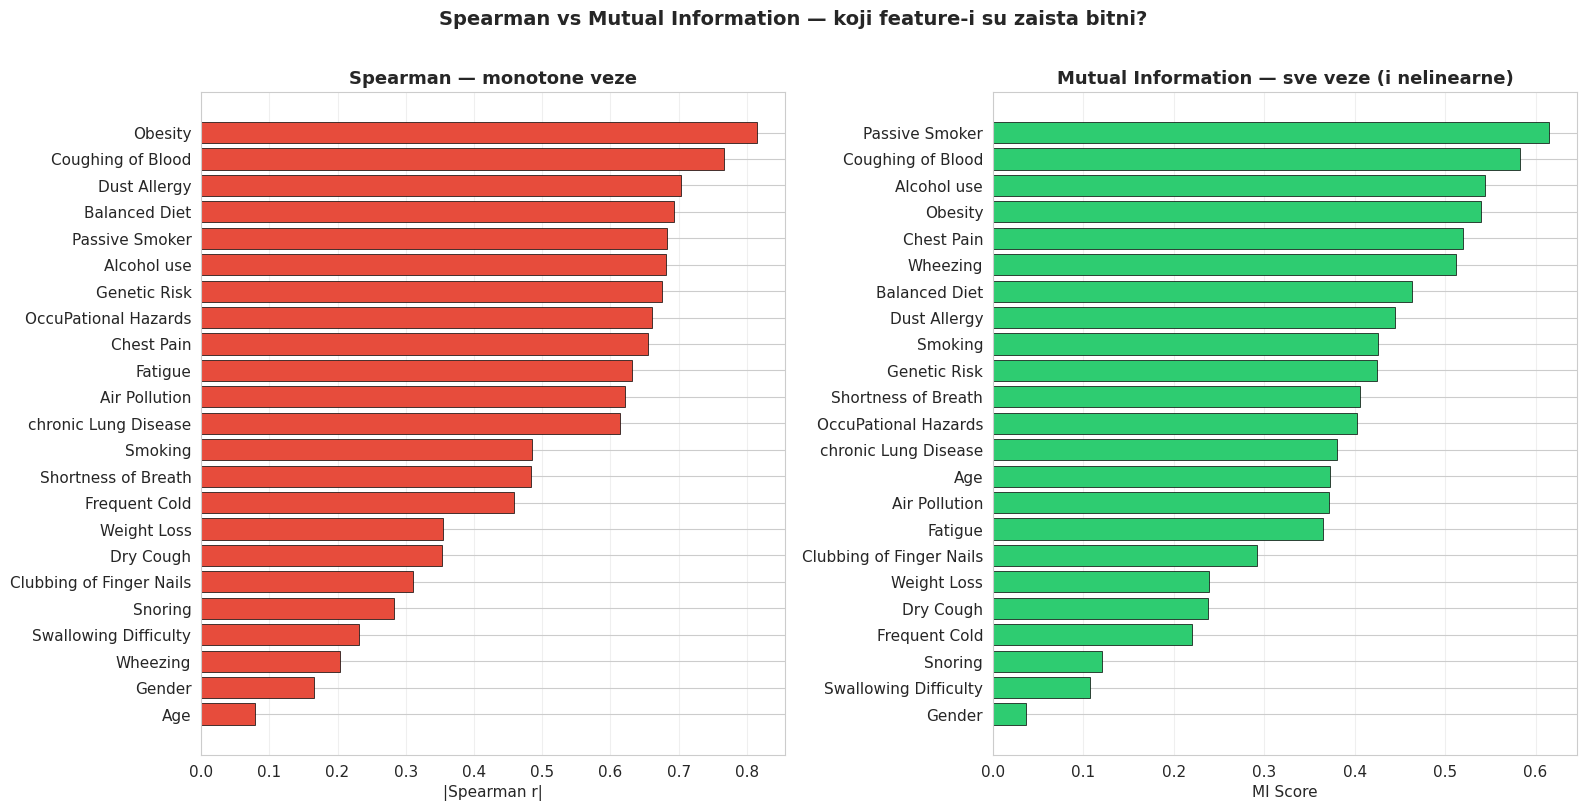

Zapažanje: Feature-i s velikom razlikom u rangu između Spearman i MI
nose nelinearne veze — tree-based modeli ih hvate, linearni ne.


In [ ]:
# Spearman hvata samo MONOTONE (linearno rastuće/opadajuće) veze.
# Mutual Information (MI) hvata SVE vrste veza — i nelinearne i kompleksne.
# MI = koliko znanje o feature-u smanjuje "nesigurnost" o target klasi.
# Feature s niskim Spearman ali visokim MI nosi nelinearnu informaciju.
mi_scores = mutual_info_classif(X, y, random_state=RANDOM_STATE, n_neighbors=5)
mi_df = pd.DataFrame({'Feature': FEATURE_NAMES,
                       'MI Score': np.round(mi_scores, 4)}).sort_values('MI Score', ascending=False)

spearman_res = []
for col in FEATURE_NAMES:
    r, p = spearmanr(X[col], y)
    spearman_res.append({'Feature': col, '|Spearman r|': round(abs(r), 4), 'p': round(p, 6)})
sp_df = pd.DataFrame(spearman_res).sort_values('|Spearman r|', ascending=False)

# Merge i sortiraj za vizualizaciju
comp = sp_df[['Feature','|Spearman r|']].merge(mi_df, on='Feature').sort_values('|Spearman r|', ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(16, 8))
axes[0].barh(comp['Feature'], comp['|Spearman r|'],
             color='#e74c3c', edgecolor='black', linewidth=0.5)
axes[0].set_xlabel('|Spearman r|')
axes[0].set_title('Spearman — monotone veze', fontweight='bold')
axes[0].grid(axis='x', alpha=0.3)

comp_mi = comp.sort_values('MI Score', ascending=True)
axes[1].barh(comp_mi['Feature'], comp_mi['MI Score'],
             color='#2ecc71', edgecolor='black', linewidth=0.5)
axes[1].set_xlabel('MI Score')
axes[1].set_title('Mutual Information — sve veze (i nelinearne)', fontweight='bold')
axes[1].grid(axis='x', alpha=0.3)

plt.suptitle('Spearman vs Mutual Information — koji feature-i su zaista bitni?',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout(); plt.show()

print("Zapažanje: Feature-i s velikom razlikom u rangu između Spearman i MI")
print("nose nelinearne veze — tree-based modeli ih hvate, linearni ne.")

### 3.6 Violinplot i pairplot ključnih feature-a

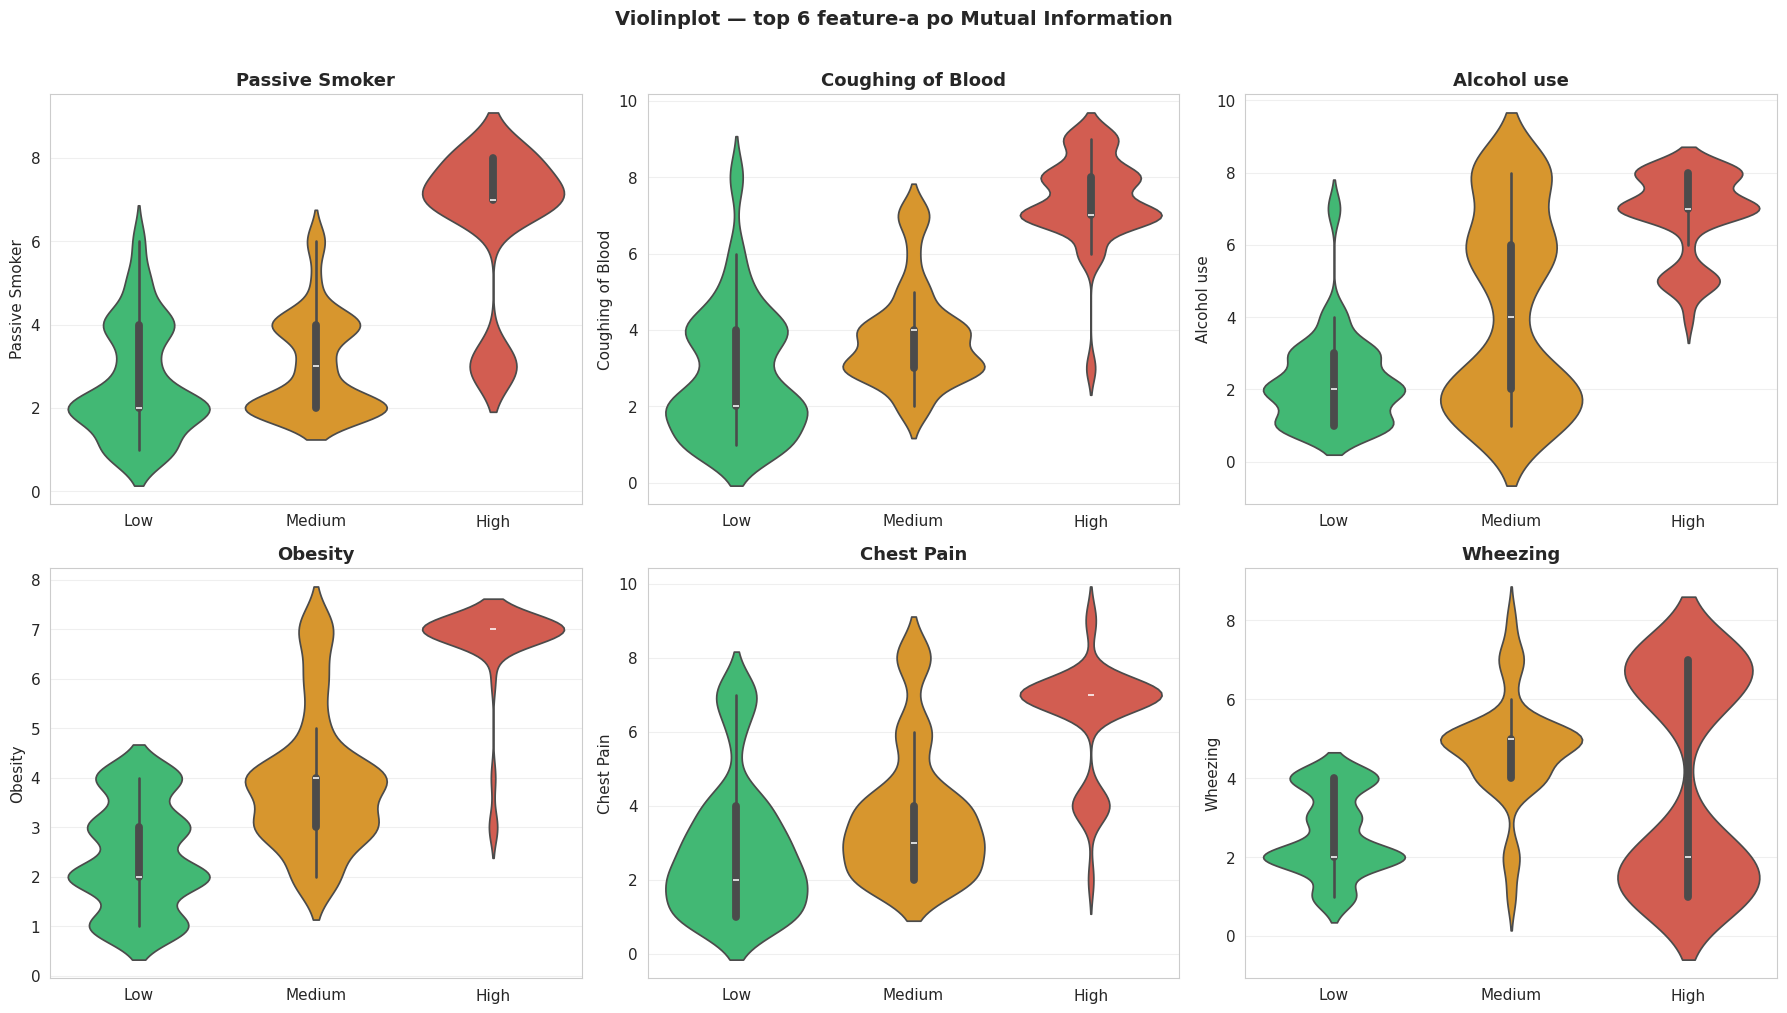

In [ ]:
# Violinplot kombinuje boxplot i distribuciju u jednom grafikonu.
# Širi dio = više pacijenata na toj vrijednosti.
# Koristimo za top 6 feature-a po MI skoru.
top6_mi = mi_df.head(6)['Feature'].tolist()
plot_df2 = dataset.copy()
plot_df2['Risk Level'] = plot_df2['Level'].map(level_mapping_reverse)

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()
for i, col in enumerate(top6_mi):
    sns.violinplot(data=plot_df2, x='Risk Level', y=col,
                   order=['Low','Medium','High'],
                   palette={'Low':'#2ecc71','Medium':'#f39c12','High':'#e74c3c'},
                   ax=axes[i], inner='box')
    axes[i].set_title(f'{col}', fontweight='bold')
    axes[i].set_xlabel('')
    axes[i].grid(axis='y', alpha=0.3)
plt.suptitle('Violinplot — top 6 feature-a po Mutual Information',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout(); plt.show()

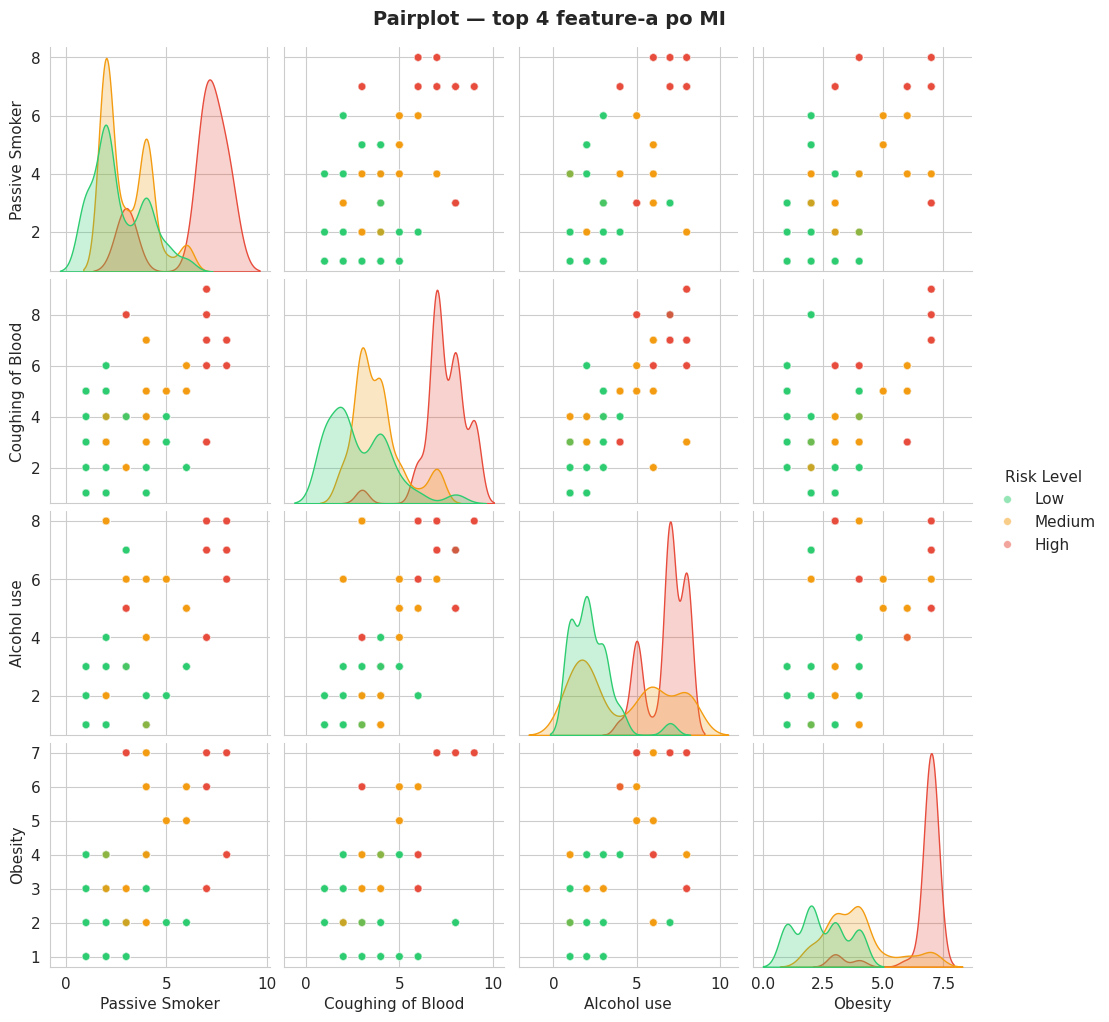

In [ ]:
# Pairplot: svaki feature nasuprot svakom drugom, obojeni po klasi.
# Dobra separacija tačaka po boji = ti feature-i zajedno dobro razdvajaju klase.
# Koristimo top 4 feature-a da pairplot ostane čitljiv.
top4_mi = mi_df.head(4)['Feature'].tolist()
pairplot_df = dataset[top4_mi + ['Level']].copy()
pairplot_df['Risk Level'] = pairplot_df['Level'].map(level_mapping_reverse)
pairplot_df = pairplot_df.drop(columns=['Level'])

pp = sns.pairplot(pairplot_df, hue='Risk Level',
                  hue_order=['Low','Medium','High'],
                  palette={'Low':'#2ecc71','Medium':'#f39c12','High':'#e74c3c'},
                  diag_kind='kde', plot_kws={'alpha':0.5, 's':30})
pp.fig.suptitle('Pairplot — top 4 feature-a po MI', y=1.02, fontsize=14, fontweight='bold')
plt.show()

---
## 4. Automatski benchmark — LazyPredict

### Zašto biramo NAJLOŠIJE modele?
Standardni pristup (uzimanje best modela) ima problem: ako svi modeli imaju ~100%,
optimizacija nema šta da popravi. Nema demonstracije znanja.

Sa **najlošijim** modelima:
- Svaki je loš iz **drugog razloga** — daje različite lekcije
- Ima merljiv prostor za poboljšanje
- Optimizacija pokazuje konkretan skok


In [ ]:
# LazyPredict trenira ~27 algoritama s default parametrima i poredi ih.
# Mi gledamo tabelu i biramo 5 pri DNU — to su naši kandidati.
print("Pokretanje LazyPredict benchmarka (~27 modela)...")
lazy_clf = LazyClassifier(verbose=0, ignore_warnings=True, custom_metric=None)
lazy_models, lazy_predictions = lazy_clf.fit(X_train, X_test, y_train, y_test)
lazy_sorted = lazy_models.sort_values('Accuracy', ascending=False)
display(lazy_sorted)

Pokretanje LazyPredict benchmarka (~27 modela)...


,Accuracy,Balanced Accuracy,ROC AUC,F1 Score,Precision,Recall,Time Taken
Model,,,,,,,
AdaBoostClassifier,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,0.3755
BaggingClassifier,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,0.1019
DecisionTreeClassifier,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,0.0768
LabelPropagation,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,0.2169
ExtraTreeClassifier,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,0.0452
KNeighborsClassifier,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,0.0828
ExtraTreesClassifier,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,0.3652
LGBMClassifier,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,0.3610
RandomForestClassifier,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,0.4282


### Naših 5 kandidata (biramo na osnovu LazyPredict rezultata):
| Model | Zašto je loš |
|---|---|
| **Dummy Classifier** | Ne uči ništa — uvek predviđa istu klasu. Nulta referenta tačka. |
| **Gaussian Naive Bayes** | Pretpostavlja nezavisnost feature-a (EDA pokazala visoku korelaciju!) i normalnu distribuciju (skala 1-8 nije normalna) |
| **Nearest Centroid** | Klasificira po "prosečnom pacijentu" klase — previše grub pristup za složene granice |
| **Ridge Classifier** | Linearni model — ne može uhvatiti nelinearne veze koje MI je detektovao |
| **Linear Discriminant Analysis** | Pretpostavlja jednaku raspršenost svih klasa — što violinplot pokazuje da nije tačno |


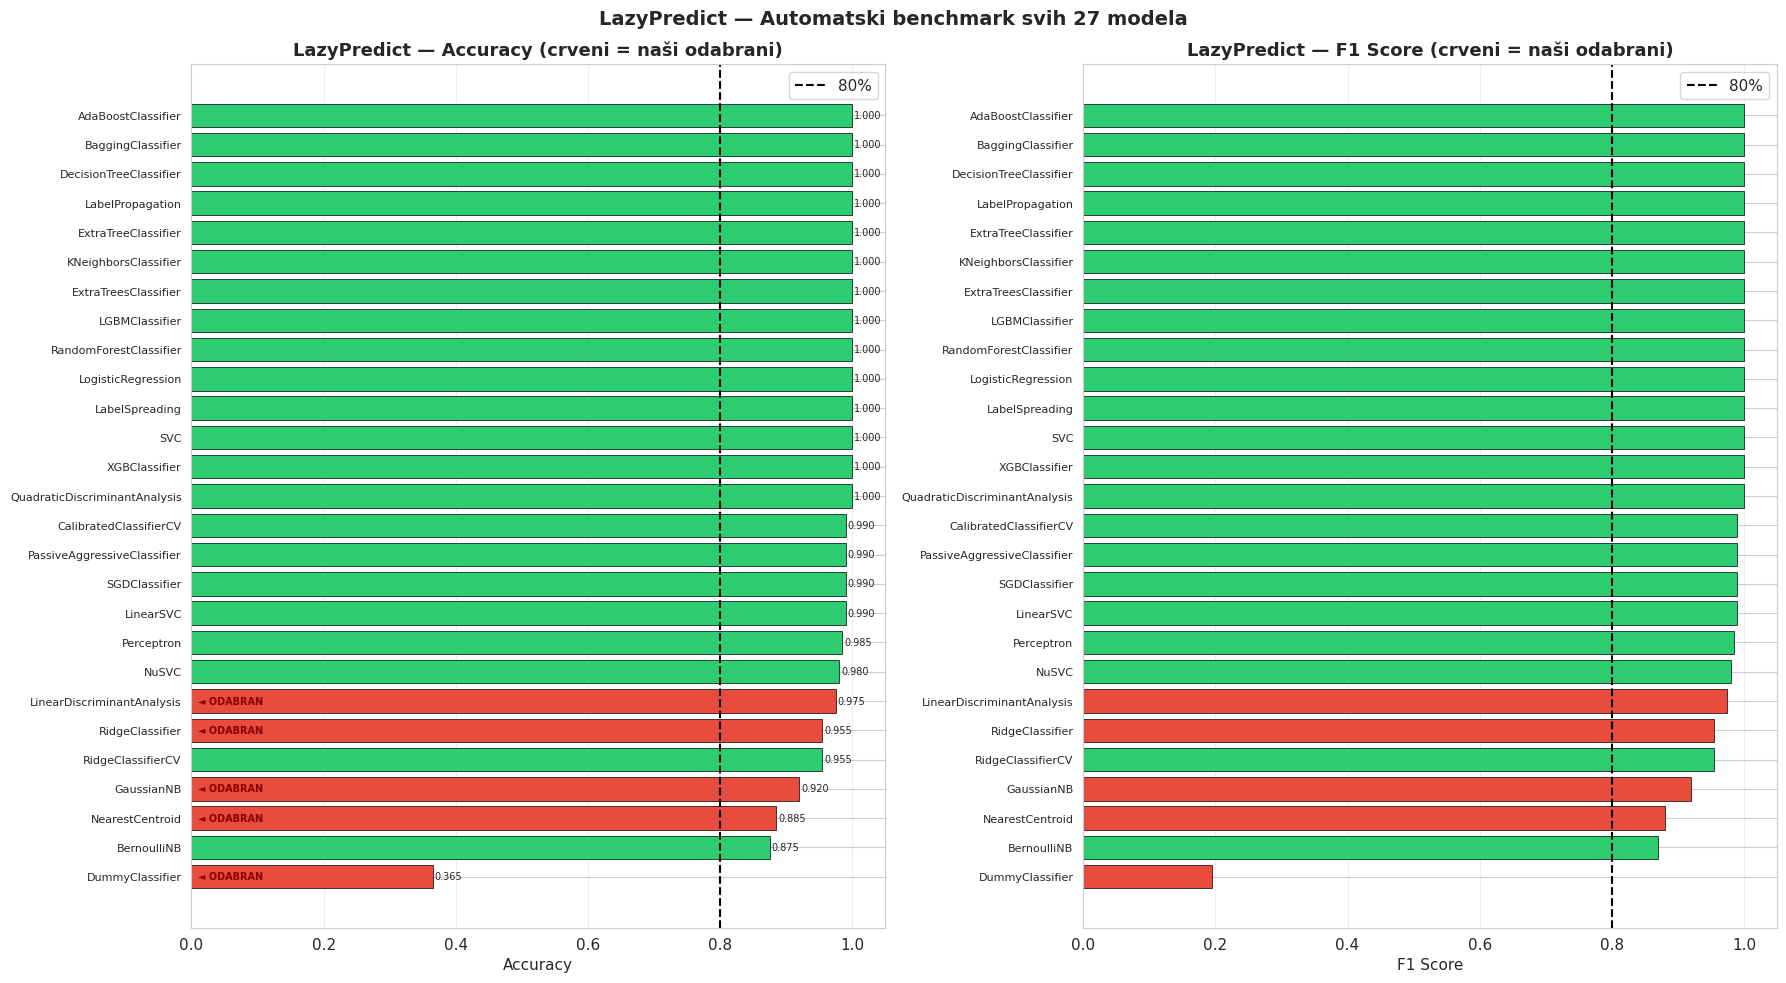

Modeli ispod 80% Accuracy: 1
Naših 5 odabranih nalaze se pri dnu tabele.


In [ ]:
# Vizualizacija: zeleni = dobri, crveni = loši.
# Mi namerno biramo crvene — prostor za poboljšanje.
TARGET_MODELS = ['DummyClassifier', 'GaussianNB', 'NearestCentroid',
                 'RidgeClassifier', 'LinearDiscriminantAnalysis']

fig, axes = plt.subplots(1, 2, figsize=(18, 10))

# Accuracy
clrs_acc = ['#e74c3c' if m in TARGET_MODELS else
            '#f39c12' if a < 0.80 else '#2ecc71'
            for m, a in zip(lazy_sorted.index, lazy_sorted['Accuracy'])]

axes[0].barh(range(len(lazy_sorted)), lazy_sorted['Accuracy'],
             color=clrs_acc, edgecolor='black', linewidth=0.5)
axes[0].set_yticks(range(len(lazy_sorted)))
axes[0].set_yticklabels(lazy_sorted.index, fontsize=8)
axes[0].set_xlabel('Accuracy')
axes[0].set_title('LazyPredict — Accuracy (crveni = naši odabrani)', fontweight='bold')
axes[0].axvline(x=0.80, color='black', linestyle='--', linewidth=1.5, label='80%')
axes[0].invert_yaxis()
axes[0].legend()
axes[0].grid(axis='x', alpha=0.3)
for i, v in enumerate(lazy_sorted['Accuracy']):
    axes[0].text(v + 0.003, i, f'{v:.3f}', va='center', fontsize=7)
for i, m in enumerate(lazy_sorted.index):
    if m in TARGET_MODELS:
        axes[0].text(0.01, i, '◄ ODABRAN', va='center', fontsize=7,
                     color='darkred', fontweight='bold')

# F1 Score
clrs_f1 = ['#e74c3c' if m in TARGET_MODELS else
           '#f39c12' if f < 0.80 else '#2ecc71'
           for m, f in zip(lazy_sorted.index, lazy_sorted['F1 Score'])]
axes[1].barh(range(len(lazy_sorted)), lazy_sorted['F1 Score'],
             color=clrs_f1, edgecolor='black', linewidth=0.5)
axes[1].set_yticks(range(len(lazy_sorted)))
axes[1].set_yticklabels(lazy_sorted.index, fontsize=8)
axes[1].set_xlabel('F1 Score')
axes[1].set_title('LazyPredict — F1 Score (crveni = naši odabrani)', fontweight='bold')
axes[1].axvline(x=0.80, color='black', linestyle='--', linewidth=1.5, label='80%')
axes[1].invert_yaxis()
axes[1].legend()
axes[1].grid(axis='x', alpha=0.3)

plt.suptitle('LazyPredict — Automatski benchmark svih 27 modela',
             fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

below_80 = (lazy_sorted['Accuracy'] < 0.80).sum()
print(f"Modeli ispod 80% Accuracy: {below_80}")
print(f"Naših 5 odabranih nalaze se pri dnu tabele.")

---
## 5. Baseline evaluacija odabranih slabih modela

Treniramo svakih 5 modela s **podrazumevanim podešavanjima**.
Ovo je naša polazna tačka — fotografija "pre" u priči o poboljšanju.


### 5.1 Helper funkcije za evaluaciju

In [ ]:
def plot_confusion_matrix(y_true, y_pred, model_name):
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    cm = confusion_matrix(y_true, y_pred)
    ConfusionMatrixDisplay(cm, display_labels=CLASS_NAMES).plot(
        ax=axes[0], cmap='Blues', values_format='d')
    axes[0].set_title(f'{model_name}\nBroj grešaka (apsolutno)')

    cm_n = confusion_matrix(y_true, y_pred, normalize='true')
    ConfusionMatrixDisplay(cm_n, display_labels=CLASS_NAMES).plot(
        ax=axes[1], cmap='Oranges', values_format='.1%')
    axes[1].set_title(f'{model_name}\nProcenti — Recall po klasi')
    plt.tight_layout()
    plt.show()


def evaluate_model(model, X_te, y_te, name, mtype='Baseline', show_cm=True, show_report=True):
    global result_df

    # FIX: direktno pozivamo predict, bez duplirane linije
    y_pred = model.predict(X_te)

    report = classification_report(y_te, y_pred, target_names=CLASS_NAMES,
                                   output_dict=True, zero_division=0)
    acc    = accuracy_score(y_te, y_pred)
    f1_w   = f1_score(y_te, y_pred, average='weighted')
    prec_w = precision_score(y_te, y_pred, average='weighted', zero_division=0)
    rec_w  = recall_score(y_te, y_pred, average='weighted',  zero_division=0)

    new_row = pd.DataFrame([{
        'Model': name, 'Type': mtype,
        'Accuracy':            round(acc,   4),
        'F1_Weighted':         round(f1_w,  4),
        'Precision_Weighted':  round(prec_w,4),
        'Recall_Weighted':     round(rec_w, 4),
        'F1_Low':    round(report['Low']['f1-score'],    4),
        'F1_Medium': round(report['Medium']['f1-score'], 4),
        'F1_High':   round(report['High']['f1-score'],   4)
    }])
    result_df = pd.concat([result_df, new_row], ignore_index=True)

    if show_report:
        sep = '=' * 58
        print(f"\n{sep}")
        print(f"  {name}  [{mtype}]")
        print(sep)
        print(f"  Accuracy:        {acc:.4f}")
        print(f"  F1-Weighted:     {f1_w:.4f}")
        print(f"  Precision-W:     {prec_w:.4f}")
        print(f"  Recall-W:        {rec_w:.4f}")
        print()
        print(classification_report(y_te, y_pred, target_names=CLASS_NAMES, zero_division=0))

    if show_cm:
        plot_confusion_matrix(y_te, y_pred, name)

    return y_pred

print("evaluate_model() ispravljena i spremna.")

evaluate_model() ispravljena i spremna.


### 5.2 Dummy Classifier (nulta referenca)


  Dummy Classifier  [Baseline]
  Accuracy:        0.3650
  F1-Weighted:     0.1952
  Precision-W:     0.1332
  Recall-W:        0.3650

              precision    recall  f1-score   support

         Low       0.00      0.00      0.00        61
      Medium       0.00      0.00      0.00        66
        High       0.36      1.00      0.53        73

    accuracy                           0.36       200
   macro avg       0.12      0.33      0.18       200
weighted avg       0.13      0.36      0.20       200



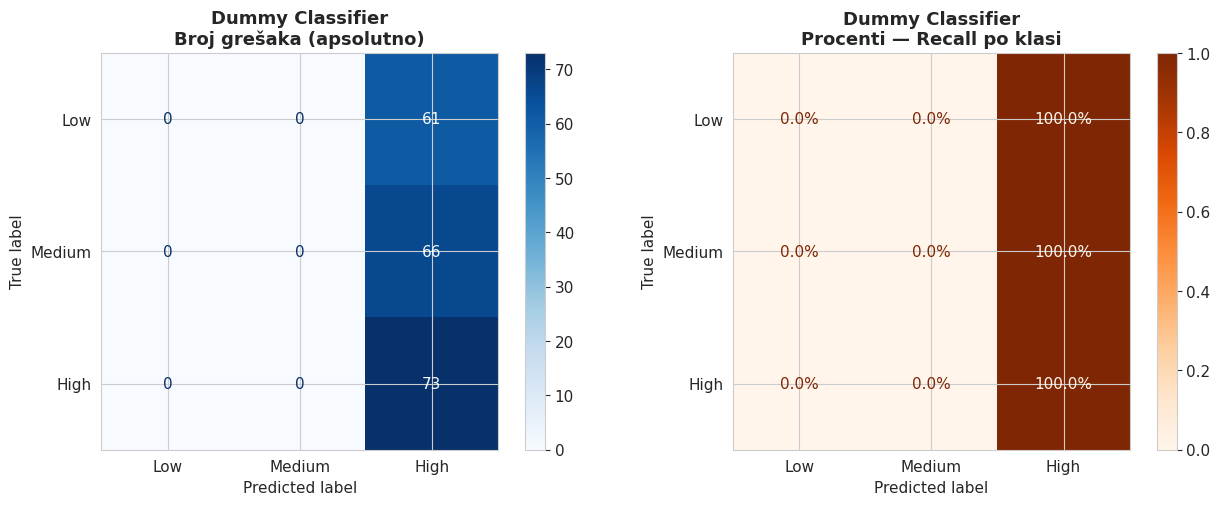

In [ ]:
# DummyClassifier ne uči ništa — uvek predviđa najčešću klasu (ili nasumično).
# Svrha: apsolutna nulta referenta tačka.
# Pravilo: SVAKI drugi model mora biti bolji od Dummy-ja.
# Ako nije — taj model je potpuno beskoristan.
dummy = DummyClassifier(strategy='most_frequent', random_state=RANDOM_STATE)
dummy.fit(X_train, y_train)
y_pred_dummy = evaluate_model(dummy, X_test, y_test, 'Dummy Classifier', 'Baseline')

### 5.3 Gaussian Naive Bayes


  Gaussian Naive Bayes  [Baseline]
  Accuracy:        0.9200
  F1-Weighted:     0.9197
  Precision-W:     0.9268
  Recall-W:        0.9200

              precision    recall  f1-score   support

         Low       1.00      0.95      0.97        61
      Medium       0.95      0.82      0.88        66
        High       0.85      0.99      0.91        73

    accuracy                           0.92       200
   macro avg       0.93      0.92      0.92       200
weighted avg       0.93      0.92      0.92       200



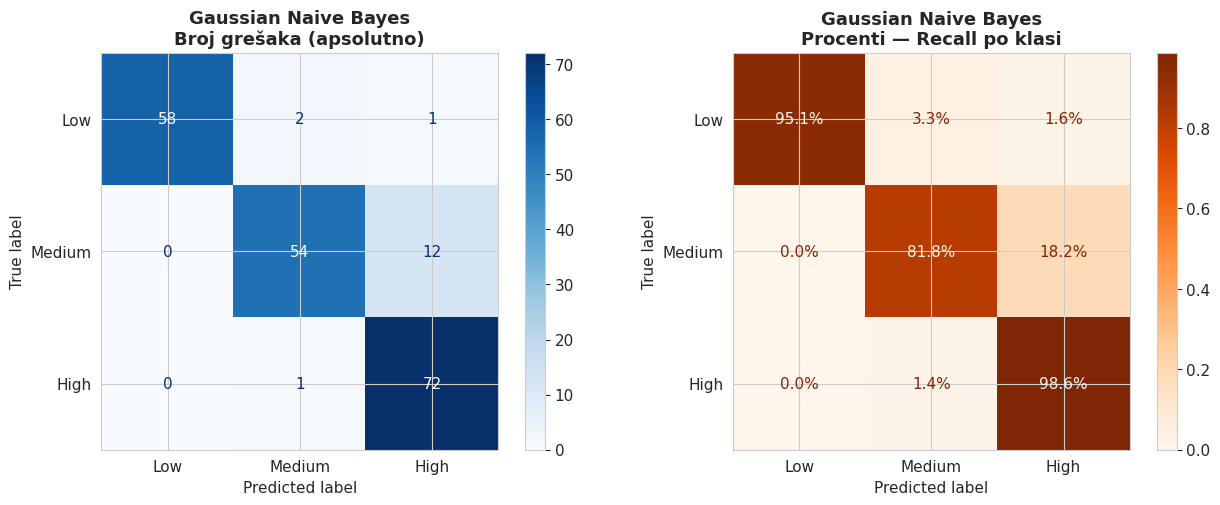

In [ ]:
# "Naivan" jer pretpostavlja dve stvari koje EDA pokazala da nisu tačne:
# 1. Nezavisnost feature-a: Spearman matrica pokazala visoku korelaciju (do 0.95!)
#    između feature-a poput Smoking i Passive Smoker, Chest Pain i Fatigue itd.
# 2. Normalnu (Gaussian) distribuciju: feature-i su na ordinalnoj skali 1-9 —
#    histogrami pokazali pljosnate/uniformne distribucije, ne zvonoliku krivu.
# Ove pretpostavke direktno krše naše podatke → model greši sistematski.
gnb = GaussianNB(var_smoothing=1e-9)
gnb.fit(X_train, y_train)
y_pred_gnb = evaluate_model(gnb, X_test, y_test, 'Gaussian Naive Bayes', 'Baseline')

### 5.4 Nearest Centroid


  Nearest Centroid  [Baseline]
  Accuracy:        0.7800
  F1-Weighted:     0.7772
  Precision-W:     0.7756
  Recall-W:        0.7800

              precision    recall  f1-score   support

         Low       0.75      0.72      0.73        61
      Medium       0.68      0.65      0.67        66
        High       0.88      0.95      0.91        73

    accuracy                           0.78       200
   macro avg       0.77      0.77      0.77       200
weighted avg       0.78      0.78      0.78       200



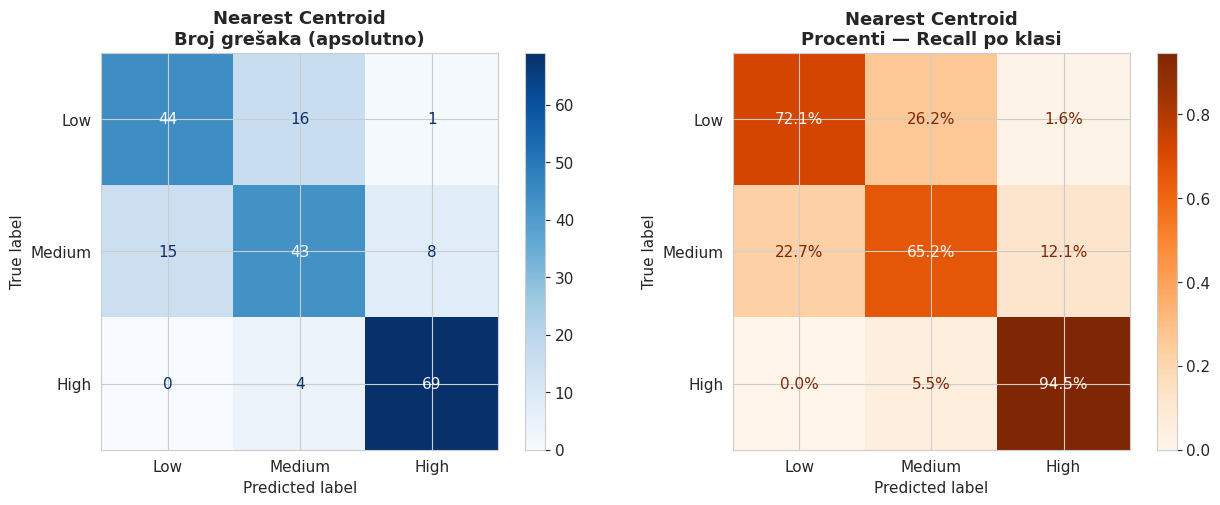

In [ ]:
# Za svaku klasu izračuna "prosečnog pacijenta" (centroid = središte svih primera).
# Novi pacijent se dodijeli klasi čijem centroidu je najbliži.
# Problem: pairplot i violinplot pokazali su da klase NISU okrugle lopte u prostoru —
# imaju nepravilne, isprepletene oblike koje centroidi ne mogu uhvatiti.
nc = NearestCentroid()
nc.fit(X_train, y_train)
y_pred_nc = evaluate_model(nc, X_test, y_test, 'Nearest Centroid', 'Baseline')

### 5.5 Ridge Classifier


  Ridge Classifier  [Baseline]
  Accuracy:        0.9550
  F1-Weighted:     0.9549
  Precision-W:     0.9549
  Recall-W:        0.9550

              precision    recall  f1-score   support

         Low       0.95      0.92      0.93        61
      Medium       0.93      0.94      0.93        66
        High       0.99      1.00      0.99        73

    accuracy                           0.95       200
   macro avg       0.95      0.95      0.95       200
weighted avg       0.95      0.95      0.95       200



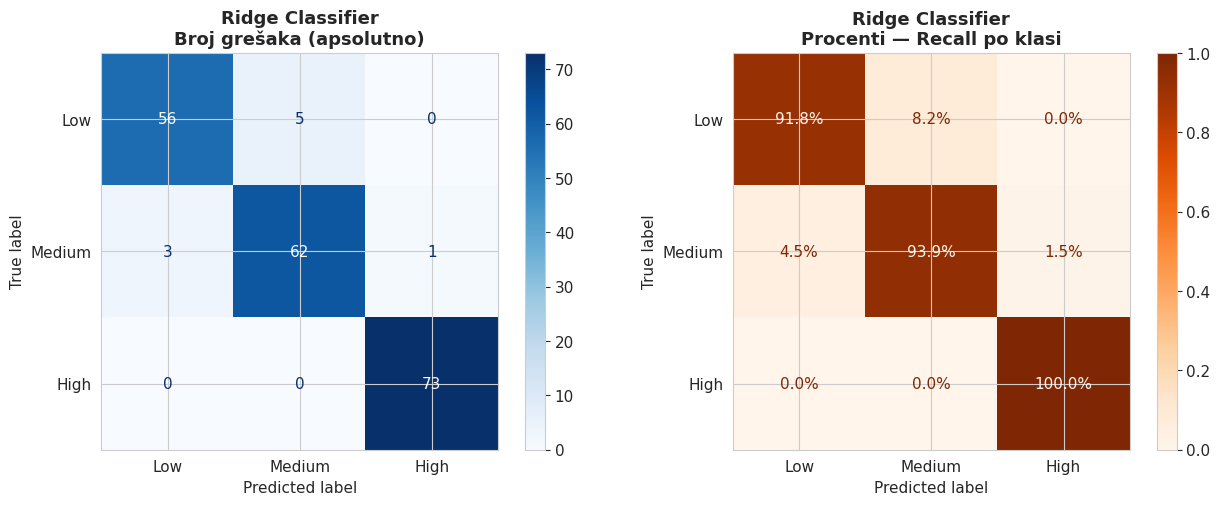

In [ ]:
# Linearni model — povlači ravnu hiper-ravninu između klasa.
# Problem: Mutual Information je detektovao nelinearne veze između feature-a i rizika.
# Ravna linija ne može opisati krivolinijsku granicu između klasa.
# alpha=1.0: podrazumevana regularizacija — kazna za previše kompleksna rešenja.
rc = RidgeClassifier(alpha=1.0, random_state=RANDOM_STATE)
rc.fit(X_train, y_train)
y_pred_rc = evaluate_model(rc, X_test, y_test, 'Ridge Classifier', 'Baseline')

### 5.6 Linear Discriminant Analysis (LDA)


  Linear Discriminant Analysis  [Baseline]
  Accuracy:        0.9750
  F1-Weighted:     0.9750
  Precision-W:     0.9759
  Recall-W:        0.9750

              precision    recall  f1-score   support

         Low       1.00      0.93      0.97        61
      Medium       0.94      0.98      0.96        66
        High       0.99      1.00      0.99        73

    accuracy                           0.97       200
   macro avg       0.98      0.97      0.97       200
weighted avg       0.98      0.97      0.97       200



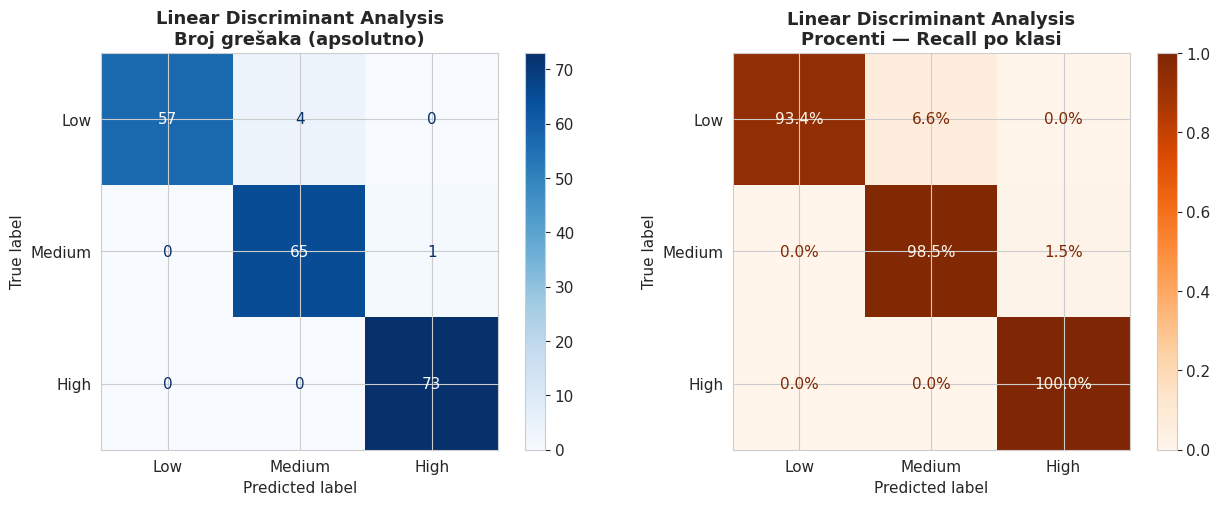

In [ ]:
# LDA pretpostavlja da sve klase imaju JEDNAKU kovariijansku matricu —
# tj. jednako "rasipanje" podataka oko centroida.
# Violinplot je jasno pokazao da High rizik klasa ima potpuno drugačiju
# distribuciju od Low rizik klase za većinu feature-a.
# Ta kršena pretpostavka direktno uzrokuje greške.
lda = LinearDiscriminantAnalysis(solver='svd')
lda.fit(X_train, y_train)
y_pred_lda = evaluate_model(lda, X_test, y_test, 'Linear Discriminant Analysis', 'Baseline')

### 5.7 Pregled i vizualizacija svih baseline rezultata

,Model,Accuracy,F1_Weighted,F1_Low,F1_Medium,F1_High
0,Dummy Classifier,0.3650,0.1952,0.0000,0.0000,0.5348
1,Gaussian Naive Bayes,0.9200,0.9197,0.9748,0.8780,0.9114
2,Nearest Centroid,0.7800,0.7772,0.7333,0.6667,0.9139
3,Ridge Classifier,0.9550,0.9549,0.9333,0.9323,0.9932
4,Linear Discriminant Analysis,0.9750,0.9750,0.9661,0.9630,0.9932


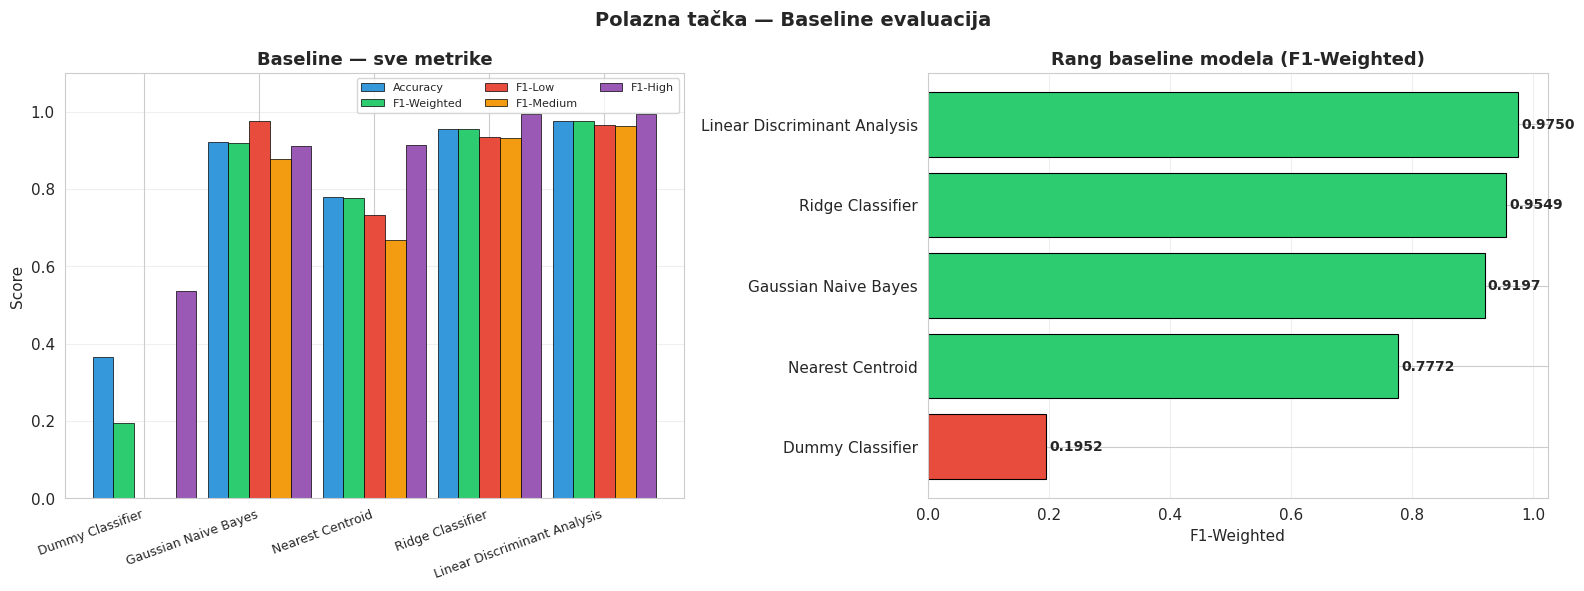

Najslabiji baseline: Dummy Classifier
Najjači baseline:    Linear Discriminant Analysis
Cilj Poglavlja 6: optimizacijom poboljšati sve modele što je moguće više.


In [ ]:
# Sumarni prikaz: ovo je naša polazna tačka za svaki model.
# Ova slika postaje "pre" u priči o poboljšanju.
baseline_df = result_df[result_df['Type']=='Baseline'].copy().reset_index(drop=True)
display(baseline_df[['Model','Accuracy','F1_Weighted','F1_Low','F1_Medium','F1_High']])

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
x = np.arange(len(baseline_df))
w = 0.18
metrics = ['Accuracy','F1_Weighted','F1_Low','F1_Medium','F1_High']
clrs = ['#3498db','#2ecc71','#e74c3c','#f39c12','#9b59b6']
lbls = ['Accuracy','F1-Weighted','F1-Low','F1-Medium','F1-High']

for i,(m,c,l) in enumerate(zip(metrics,clrs,lbls)):
    axes[0].bar(x + i*w, baseline_df[m].astype(float), w,
                label=l, color=c, edgecolor='black', linewidth=0.5)
axes[0].set_xticks(x + w*2)
axes[0].set_xticklabels(baseline_df['Model'], rotation=20, ha='right', fontsize=9)
axes[0].set_ylabel('Score')
axes[0].set_title('Baseline — sve metrike', fontweight='bold')
axes[0].legend(ncol=3, fontsize=8)
axes[0].set_ylim(0, 1.1)
axes[0].grid(axis='y', alpha=0.3)

# Rang po F1-Weighted
ranked = baseline_df.sort_values('F1_Weighted', ascending=True)
colors_rank = ['#e74c3c' if v < 0.5 else '#f39c12' if v < 0.7 else '#2ecc71'
               for v in ranked['F1_Weighted'].astype(float)]
axes[1].barh(ranked['Model'], ranked['F1_Weighted'].astype(float),
             color=colors_rank, edgecolor='black', linewidth=0.8)
axes[1].set_xlabel('F1-Weighted')
axes[1].set_title('Rang baseline modela (F1-Weighted)', fontweight='bold')
axes[1].grid(axis='x', alpha=0.3)
for i, v in enumerate(ranked['F1_Weighted'].astype(float)):
    axes[1].text(v + 0.005, i, f'{v:.4f}', va='center', fontsize=10, fontweight='bold')

plt.suptitle('Polazna tačka — Baseline evaluacija', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

worst = baseline_df.loc[baseline_df['F1_Weighted'].astype(float).idxmin(), 'Model']
best_b = baseline_df.loc[baseline_df['F1_Weighted'].astype(float).idxmax(), 'Model']
print(f"Najslabiji baseline: {worst}")
print(f"Najjači baseline:    {best_b}")
print("Cilj Poglavlja 6: optimizacijom poboljšati sve modele što je moguće više.")

---
## 6. Optimizacija hiperparametara

### Šta su hiperparametri?
Hiperparametri su podešavanja koja MI biramo PRE treniranja — model ih ne uči sam.
Primer: koliko stabala u Random Forestu, koliko kazna za kompleksnost u Ridgeu.
Pogrešni hiperparametri = loš model čak i s dobrim algoritmom i dobrim podacima.

### RandomizedSearchCV + 5-fold StratifiedKFold
Umesto testiranja SVIH kombinacija (sporo), testiramo nasumičnih 20 i biramo najboljeg.
5-fold: delimo train podatke na 5 delova, 5× treniramo/testiramo, uzimamo prosek.
Stratified: svaki fold ima iste proporcije klasa kao celi dataset.


In [ ]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
best_models = {}  # Čuvamo optimizovane modele za Poglavlje 7 (Stacking) i 8 (Interpretabilnost)
search_objects = {}  # Čuvamo search objekte za analizu CV rezultata
print("StratifiedKFold(n_splits=5) konfigurisan.")

StratifiedKFold(n_splits=5) konfigurisan.


### 6.1 Gaussian Naive Bayes

Best var_smoothing: 1.60e-03
CV F1-Weighted:     0.8950

  Gaussian NB (Optimized)  [Optimized]
  Accuracy:        0.9200
  F1-Weighted:     0.9197
  Precision-W:     0.9268
  Recall-W:        0.9200

              precision    recall  f1-score   support

         Low       1.00      0.95      0.97        61
      Medium       0.95      0.82      0.88        66
        High       0.85      0.99      0.91        73

    accuracy                           0.92       200
   macro avg       0.93      0.92      0.92       200
weighted avg       0.93      0.92      0.92       200



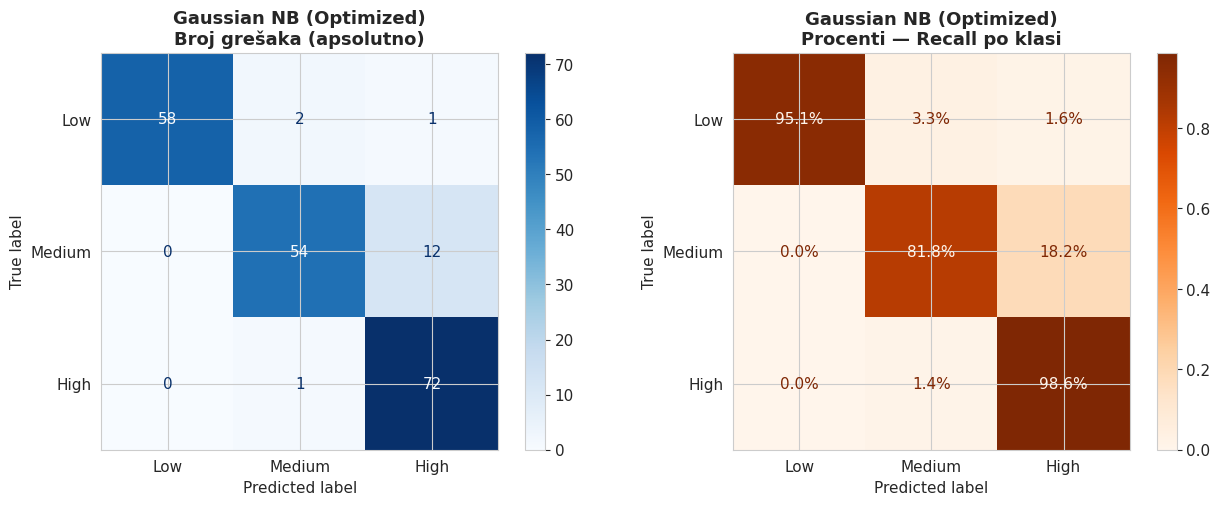

In [ ]:
# var_smoothing: mali broj koji se dodaje varijanci da sprieči deljenje s nulom.
# Ako nijedan pacijent u train setu nema Smoking=8 i High rizik zajedno,
# verovatnoća je 0 — a 0 × bilo šta = 0, što kvari celu računicu.
# var_smoothing "gladi" distribuciju i sprečava ovu nulu.
# np.logspace: 50 vrednosti na logaritamskoj skali od 10^-12 do 10^-1.
gnb_param_grid = {
    'var_smoothing': np.logspace(-12, -1, 50)
}

gnb_search = RandomizedSearchCV(
    GaussianNB(), param_distributions=gnb_param_grid,
    n_iter=20, scoring='f1_weighted', cv=skf,
    random_state=RANDOM_STATE, n_jobs=-1, verbose=0
)
gnb_search.fit(X_train, y_train)
best_gnb = gnb_search.best_estimator_
best_models['Gaussian NB'] = best_gnb
search_objects['Gaussian NB'] = gnb_search

print(f"Best var_smoothing: {gnb_search.best_params_['var_smoothing']:.2e}")
print(f"CV F1-Weighted:     {gnb_search.best_score_:.4f}")
y_pred_gnb_opt = evaluate_model(best_gnb, X_test, y_test,
                                 'Gaussian NB (Optimized)', 'Optimized')

### 6.2 Nearest Centroid

Best params:    {'shrink_threshold': 0.1, 'metric': 'manhattan'}
CV F1-Weighted: 0.7948

  Nearest Centroid (Optimized)  [Optimized]
  Accuracy:        0.8550
  F1-Weighted:     0.8541
  Precision-W:     0.8540
  Recall-W:        0.8550

              precision    recall  f1-score   support

         Low       0.94      0.95      0.94        61
      Medium       0.81      0.76      0.78        66
        High       0.83      0.86      0.85        73

    accuracy                           0.85       200
   macro avg       0.86      0.86      0.86       200
weighted avg       0.85      0.85      0.85       200



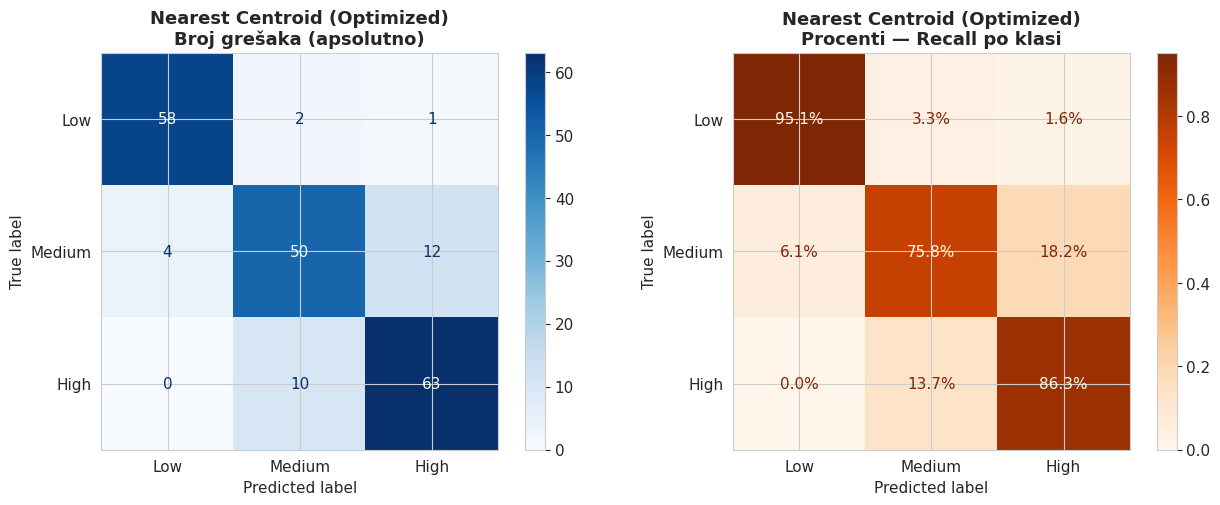

In [ ]:
# metric: kako merimo "udaljenost" pacijenta do centroida klase.
#   euclidean = ravna linija (Pitagora u više dimenzija)
#   manhattan = udaljenost kao hod gradom (samo horizontalno/vertikalno)
# shrink_threshold: ako je feature beznačajan za razdvajanje klasa, ignoriše ga.
#   None = koristimo sve feature-e
#   > 0 = automatska selekcija feature-a (ugrađena u model)
nc_param_grid = {
    'metric': ['euclidean', 'manhattan'],
    'shrink_threshold': [None, 0.1, 0.2, 0.5, 1.0, 2.0, 5.0]
}

nc_search = RandomizedSearchCV(
    NearestCentroid(), param_distributions=nc_param_grid,
    n_iter=14, scoring='f1_weighted', cv=skf,
    random_state=RANDOM_STATE, n_jobs=-1, verbose=0
)
nc_search.fit(X_train, y_train)
best_nc = nc_search.best_estimator_
best_models['Nearest Centroid'] = best_nc
search_objects['Nearest Centroid'] = nc_search

print(f"Best params:    {nc_search.best_params_}")
print(f"CV F1-Weighted: {nc_search.best_score_:.4f}")
y_pred_nc_opt = evaluate_model(best_nc, X_test, y_test,
                                'Nearest Centroid (Optimized)', 'Optimized')

### 6.3 Ridge Classifier

Best params:    {'fit_intercept': True, 'class_weight': 'balanced', 'alpha': 100.0}
CV F1-Weighted: 0.9483

  Ridge Classifier (Optimized)  [Optimized]
  Accuracy:        0.9650
  F1-Weighted:     0.9649
  Precision-W:     0.9648
  Recall-W:        0.9650

              precision    recall  f1-score   support

         Low       0.95      0.95      0.95        61
      Medium       0.95      0.94      0.95        66
        High       0.99      1.00      0.99        73

    accuracy                           0.96       200
   macro avg       0.96      0.96      0.96       200
weighted avg       0.96      0.96      0.96       200



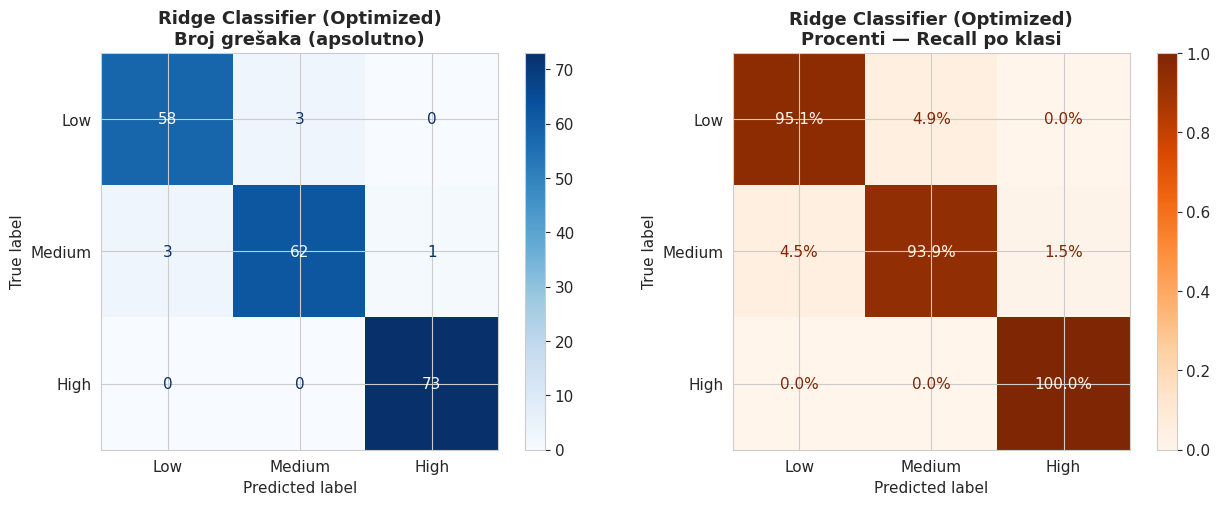

In [ ]:
# alpha: regularizacioni parametar — kazna za kompleksnost.
#   Manji alpha = model slobodnije uči (rizik od overfittinga)
#   Veći alpha = model penaliziran za složena rešenja (glađi, stabilniji)
# class_weight='balanced': automatski daje veću težinu klasi s manje primera.
# fit_intercept: da li model sme imati pomak od nule (skoro uvek True).
rc_param_grid = {
    'alpha': [0.001, 0.01, 0.1, 0.5, 1.0, 5.0, 10.0, 50.0, 100.0],
    'class_weight': [None, 'balanced'],
    'fit_intercept': [True, False]
}

rc_search = RandomizedSearchCV(
    RidgeClassifier(random_state=RANDOM_STATE), param_distributions=rc_param_grid,
    n_iter=20, scoring='f1_weighted', cv=skf,
    random_state=RANDOM_STATE, n_jobs=-1, verbose=0
)
rc_search.fit(X_train, y_train)
best_rc = rc_search.best_estimator_
best_models['Ridge'] = best_rc
search_objects['Ridge'] = rc_search

print(f"Best params:    {rc_search.best_params_}")
print(f"CV F1-Weighted: {rc_search.best_score_:.4f}")
y_pred_rc_opt = evaluate_model(best_rc, X_test, y_test,
                                'Ridge Classifier (Optimized)', 'Optimized')

### 6.4 Linear Discriminant Analysis

Best params:    {'tol': 0.0001, 'solver': 'lsqr', 'shrinkage': 0.0}
CV F1-Weighted: 0.9675

  LDA (Optimized)  [Optimized]
  Accuracy:        0.9750
  F1-Weighted:     0.9750
  Precision-W:     0.9759
  Recall-W:        0.9750

              precision    recall  f1-score   support

         Low       1.00      0.93      0.97        61
      Medium       0.94      0.98      0.96        66
        High       0.99      1.00      0.99        73

    accuracy                           0.97       200
   macro avg       0.98      0.97      0.97       200
weighted avg       0.98      0.97      0.97       200



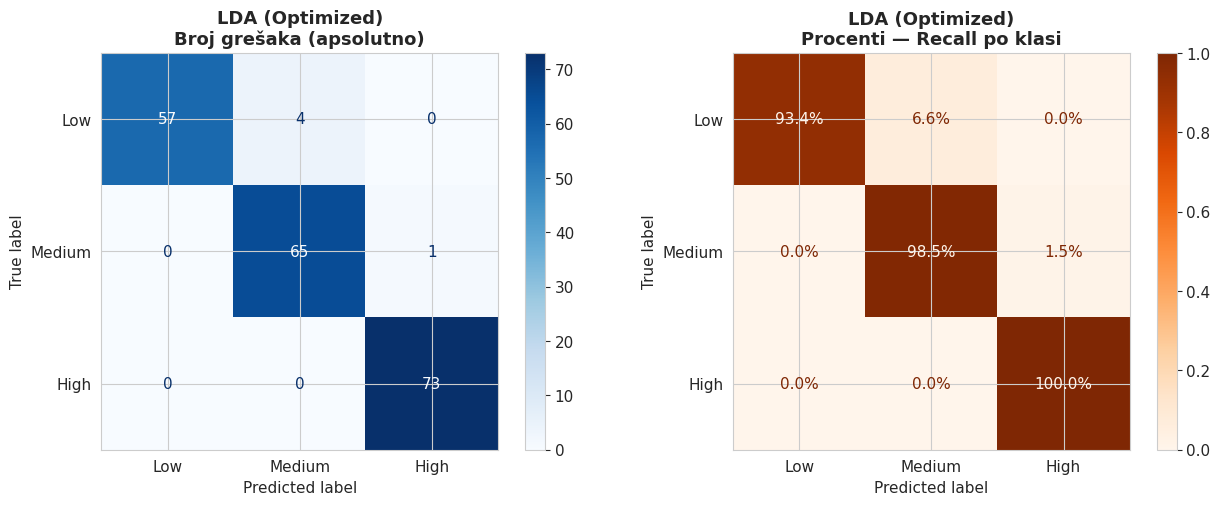

In [ ]:
# solver: matematički metod za pronalaženje granica između klasa.
#   'lsqr' i 'eigen' podržavaju shrinkage regularizaciju (svd ne podržava).
# shrinkage: regularizacija specifična za LDA.
#   None = bez regularizacije
#   'auto' = Ledoit-Wolf metod automatski računa optimalnu vrednost
#   0.0-1.0 = ručno podešavanje
# Shrinkage posebno pomaže kad ima previše feature-a ili visoke korelacije
# između feature-a (što naša EDA potvrdila!).
lda_param_grid = {
    'solver':    ['lsqr', 'eigen'],
    'shrinkage': [None, 'auto', 0.0, 0.1, 0.3, 0.5, 0.7, 1.0],
    'tol':       [1e-4, 1e-3, 1e-2]
}

lda_search = RandomizedSearchCV(
    LinearDiscriminantAnalysis(), param_distributions=lda_param_grid,
    n_iter=20, scoring='f1_weighted', cv=skf,
    random_state=RANDOM_STATE, n_jobs=-1, verbose=0
)
lda_search.fit(X_train, y_train)
best_lda = lda_search.best_estimator_
best_models['LDA'] = best_lda
search_objects['LDA'] = lda_search

print(f"Best params:    {lda_search.best_params_}")
print(f"CV F1-Weighted: {lda_search.best_score_:.4f}")
y_pred_lda_opt = evaluate_model(best_lda, X_test, y_test,
                                 'LDA (Optimized)', 'Optimized')

### 6.5 Dummy — ostaje isti (referenca)


  Dummy (referenca)  [Optimized]
  Accuracy:        0.3650
  F1-Weighted:     0.1952
  Precision-W:     0.1332
  Recall-W:        0.3650

              precision    recall  f1-score   support

         Low       0.00      0.00      0.00        61
      Medium       0.00      0.00      0.00        66
        High       0.36      1.00      0.53        73

    accuracy                           0.36       200
   macro avg       0.12      0.33      0.18       200
weighted avg       0.13      0.36      0.20       200



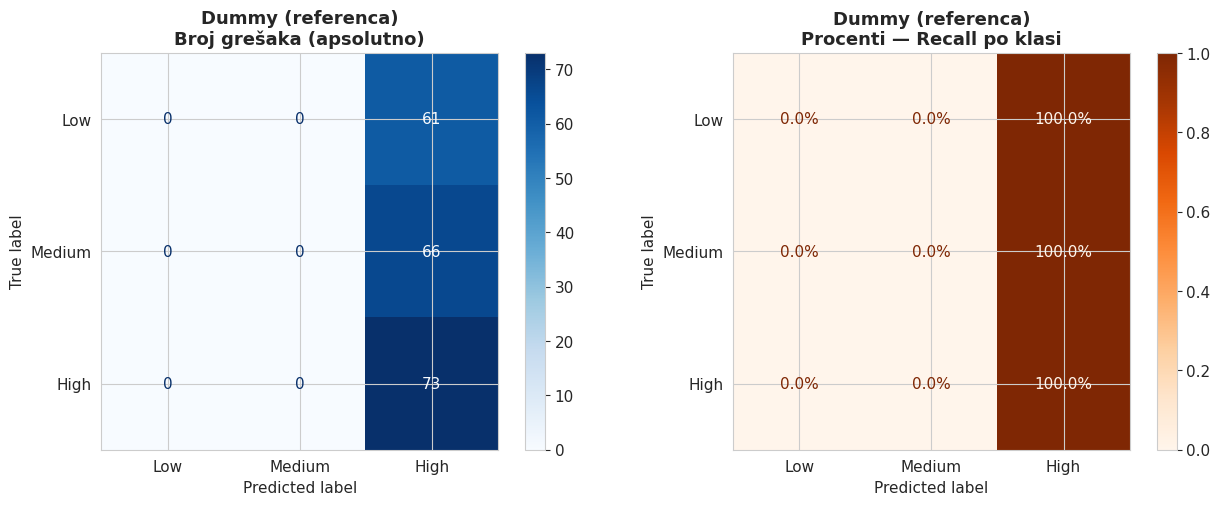

Dummy ne može biti optimizovan — služi kao minimalni prag koji svaki model mora premašiti.


In [ ]:
# Dummy nema hiperparametre koji bi poboljšali rezultat — to je po definiciji.
# Ostavljamo ga kao fiksnu nultu referencu: svaki optimizovani model mora biti bolji.
dummy_ref = DummyClassifier(strategy='most_frequent', random_state=RANDOM_STATE)
dummy_ref.fit(X_train, y_train)
best_models['Dummy'] = dummy_ref
y_pred_dummy_ref = evaluate_model(dummy_ref, X_test, y_test,
                                   'Dummy (referenca)', 'Optimized')
print("Dummy ne može biti optimizovan — služi kao minimalni prag koji svaki model mora premašiti.")

### 6.6 Learning curves

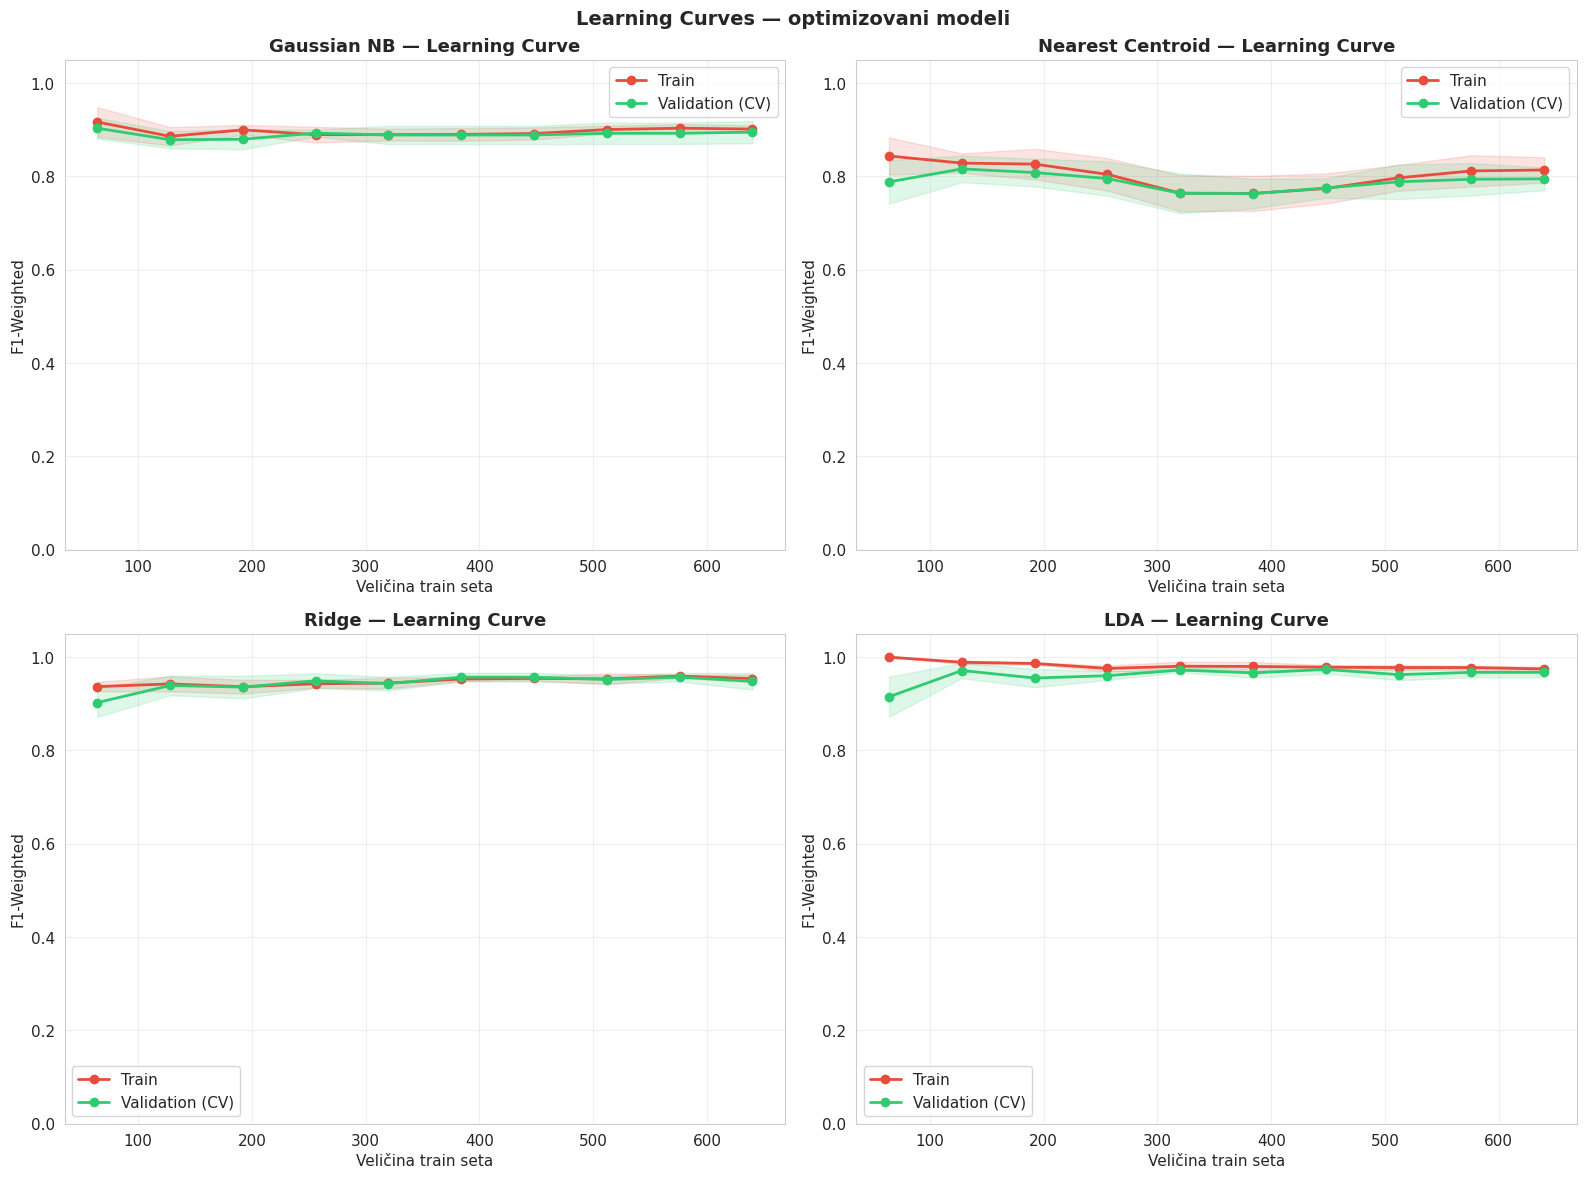

In [ ]:
# Learning curve pokazuje kako se tačnost mnja s veličinom train seta.
# Ako Train >> Validation: model je naučio napamet (overfitting).
# Ako oba konvergiraju na nisku vrednost: model je previše jednostavan (underfitting).
# Idealno: oba se sreću na visokoj vrednosti.
lc_models = {'Gaussian NB': best_gnb, 'Nearest Centroid': best_nc,
             'Ridge': best_rc, 'LDA': best_lda}

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()
train_sizes = np.linspace(0.1, 1.0, 10)

for idx, (name, model) in enumerate(lc_models.items()):
    ax = axes[idx]
    tr_sizes, tr_scores, val_scores = learning_curve(
        model, X_train, y_train,
        train_sizes=train_sizes, cv=skf,
        scoring='f1_weighted', n_jobs=-1
    )
    tr_mean  = tr_scores.mean(axis=1)
    tr_std   = tr_scores.std(axis=1)
    val_mean = val_scores.mean(axis=1)
    val_std  = val_scores.std(axis=1)

    ax.plot(tr_sizes, tr_mean, 'o-', color='#e74c3c', linewidth=2, label='Train')
    ax.fill_between(tr_sizes, tr_mean-tr_std, tr_mean+tr_std,
                    alpha=0.15, color='#e74c3c')
    ax.plot(tr_sizes, val_mean, 'o-', color='#2ecc71', linewidth=2, label='Validation (CV)')
    ax.fill_between(tr_sizes, val_mean-val_std, val_mean+val_std,
                    alpha=0.15, color='#2ecc71')
    ax.set_xlabel('Veličina train seta')
    ax.set_ylabel('F1-Weighted')
    ax.set_title(f'{name} — Learning Curve', fontweight='bold')
    ax.legend()
    ax.set_ylim(0, 1.05)
    ax.grid(alpha=0.3)

plt.suptitle('Learning Curves — optimizovani modeli', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

### 6.8 Baseline vs Optimized — glavni grafik poboljšanja

,Naziv,Baseline,Optimized,Delta
0,Dummy,0.1952,0.1952,0.0000
1,Gaussian NB,0.9197,0.9197,0.0000
2,Nearest\nCentroid,0.7772,0.8541,0.0769
3,Ridge,0.9549,0.9649,0.0100
4,LDA,0.9750,0.9750,0.0000


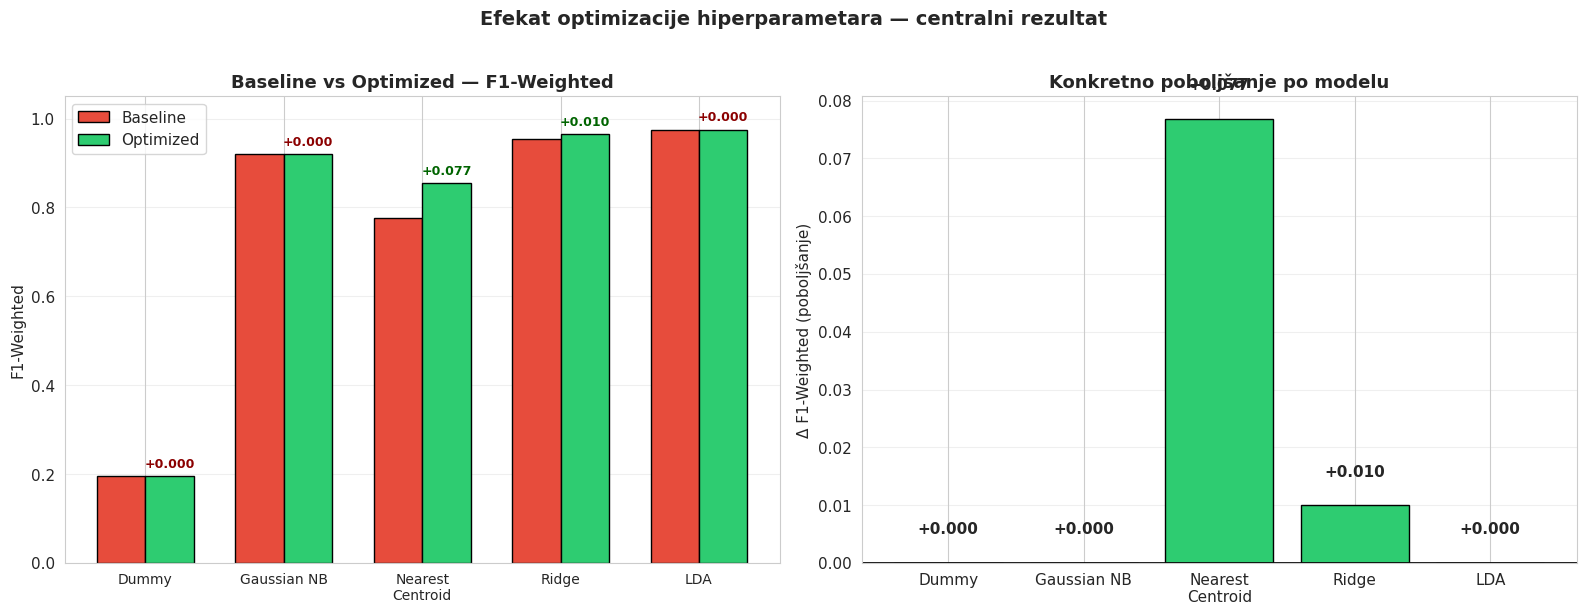

In [ ]:
# Ovo je centralni rezultat projekta: koliko je svaki model napredovao?
model_pairs = [
    ('Dummy Classifier',             'Dummy (referenca)'),
    ('Gaussian Naive Bayes',         'Gaussian NB (Optimized)'),
    ('Nearest Centroid',             'Nearest Centroid (Optimized)'),
    ('Ridge Classifier',             'Ridge Classifier (Optimized)'),
    ('Linear Discriminant Analysis', 'LDA (Optimized)')
]
short_names = ['Dummy', 'Gaussian NB', 'Nearest\nCentroid', 'Ridge', 'LDA']

pair_data = []
for (bn, on), sn in zip(model_pairs, short_names):
    b_row = result_df[result_df['Model']==bn]
    o_row = result_df[result_df['Model']==on]
    if len(b_row) > 0 and len(o_row) > 0:
        bf = float(b_row['F1_Weighted'].values[0])
        of = float(o_row['F1_Weighted'].values[0])
        pair_data.append({'Naziv': sn, 'Baseline': bf,
                          'Optimized': of, 'Delta': round(of-bf,4)})

pair_df = pd.DataFrame(pair_data)
display(pair_df)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
x = np.arange(len(pair_df))
w = 0.35

axes[0].bar(x-w/2, pair_df['Baseline'], w, label='Baseline',
            color='#e74c3c', edgecolor='black', linewidth=1)
axes[0].bar(x+w/2, pair_df['Optimized'], w, label='Optimized',
            color='#2ecc71', edgecolor='black', linewidth=1)
axes[0].set_xticks(x)
axes[0].set_xticklabels(pair_df['Naziv'], fontsize=10)
axes[0].set_ylabel('F1-Weighted')
axes[0].set_title('Baseline vs Optimized — F1-Weighted', fontweight='bold')
axes[0].legend()
axes[0].set_ylim(0, 1.05)
axes[0].grid(axis='y', alpha=0.3)
for i, row in pair_df.iterrows():
    color = 'darkgreen' if row['Delta'] > 0 else 'darkred'
    sign  = '+' if row['Delta'] >= 0 else ''
    axes[0].annotate(f"{sign}{row['Delta']:.3f}",
                     xy=(i+w/2, row['Optimized']+0.02),
                     ha='center', fontsize=9, color=color, fontweight='bold')

delta_colors = ['#2ecc71' if d > 0 else '#e74c3c' for d in pair_df['Delta']]
axes[1].bar(pair_df['Naziv'], pair_df['Delta'],
            color=delta_colors, edgecolor='black', linewidth=1)
axes[1].axhline(y=0, color='black', linewidth=2)
axes[1].set_ylabel('Δ F1-Weighted (poboljšanje)')
axes[1].set_title('Konkretno poboljšanje po modelu', fontweight='bold')
axes[1].grid(axis='y', alpha=0.3)
for i, v in enumerate(pair_df['Delta']):
    axes[1].text(i, v + (0.005 if v >= 0 else -0.015),
                 f'{v:+.3f}', ha='center', fontweight='bold', fontsize=11)

plt.suptitle('Efekat optimizacije hiperparametara — centralni rezultat',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout(); plt.show()

### 6.9 McNemar test — da li modeli prave iste greške?

In [ ]:
# McNemar test: da li par modela greši na ISTIM ili RAZLIČITIM pacijentima?
# Ako greše na istim: nema razlike između njih, kombinovanje ne pomaže.
# Ako greše na različitim: statistički su različiti, kombinovanje može biti korisno.
# p < 0.05: razlika je statistički značajna.
opt_preds_dict = {
    'Gaussian NB': y_pred_gnb_opt,
    'Nearest Centroid': y_pred_nc_opt,
    'Ridge': y_pred_rc_opt,
    'LDA': y_pred_lda_opt
}

mcnemar_rows = []
names_mc = list(opt_preds_dict.keys())
for i in range(len(names_mc)):
    for j in range(i+1, len(names_mc)):
        na, nb = names_mc[i], names_mc[j]
        ca = (opt_preds_dict[na] == y_test.values).astype(int)
        cb = (opt_preds_dict[nb] == y_test.values).astype(int)
        n11 = np.sum((ca==1)&(cb==1))
        n00 = np.sum((ca==0)&(cb==0))
        n10 = np.sum((ca==1)&(cb==0))
        n01 = np.sum((ca==0)&(cb==1))
        ct = np.array([[n11, n10], [n01, n00]])
        if n01+n10 == 0:
            p_val, note = 1.0, "Identične greške — nema razlike"
        else:
            res = mcnemar(ct, exact=True)
            p_val = res.pvalue
            note = "Statistički različiti (p<0.05)" if p_val < 0.05 else "Nije značajno"
        mcnemar_rows.append({
            'Model A': na, 'Model B': nb,
            'Oba tačna': n11, 'Oba pogrešna': n00,
            'Samo A': n10, 'Samo B': n01,
            'Neslaganja': n10+n01,
            'p-value': round(p_val, 4), 'Zaključak': note
        })

mcnemar_df = pd.DataFrame(mcnemar_rows)
display(mcnemar_df)
print("\nModeli koji statistički različito griješe = kandidati za kombinovanje u Stacking Ensemble.")

,Model A,Model B,Oba tačna,Oba pogrešna,Samo A,Samo B,Neslaganja,p-value,Zaključak
0,Gaussian NB,Nearest Centroid,171,16,13,0,13,0.0002,Statistički različiti (p<0.05)
1,Gaussian NB,Ridge,183,6,1,10,11,0.0117,Statistički različiti (p<0.05)
2,Gaussian NB,LDA,183,4,1,12,13,0.0034,Statistički različiti (p<0.05)
3,Nearest Centroid,Ridge,170,6,1,23,24,0.0000,Statistički različiti (p<0.05)
4,Nearest Centroid,LDA,170,4,1,25,26,0.0000,Statistički različiti (p<0.05)
5,Ridge,LDA,192,4,1,3,4,0.6250,Nije značajno



Modeli koji statistički različito griješe = kandidati za kombinovanje u Stacking Ensemble.


---
## 7. Stacking Ensemble

### Šta je Stacking?
Stacking kombinuje više modela u dva nivoa:
- **Nivo 1 (bazni modeli)**: GaussianNB + LDA — svaki daje svoju predikciju
- **Nivo 2 (meta-model)**: Logistic Regression uči kako da kombinuje predikcije nivoa 1

Svaki bazni model ima svoju "slabost" — ali griješe na RAZLIČITIM pacijentima.
Meta-model uči kada vjerovati kojem modelu. Rezultat je bolji od svakog pojedinačno.

### Zašto Logistic Regression kao meta-model?
Jednostavan, interpretabilan, ne overfituje na malom broju ulaza (3 modela × 3 klase = 9 feature-a).
`stack_method='predict_proba'` znači: bazni modeli daju verovatnoće (0.7, 0.2, 0.1),
ne samo klasu — meta-model dobija bogatiju informaciju za odluku.


Treniranje Stacking Ensemble (GNB + LDA + LR → Logistic Regression)...

  Stacking Ensemble  [Optimized]
  Accuracy:        1.0000
  F1-Weighted:     1.0000
  Precision-W:     1.0000
  Recall-W:        1.0000

              precision    recall  f1-score   support

         Low       1.00      1.00      1.00        61
      Medium       1.00      1.00      1.00        66
        High       1.00      1.00      1.00        73

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200



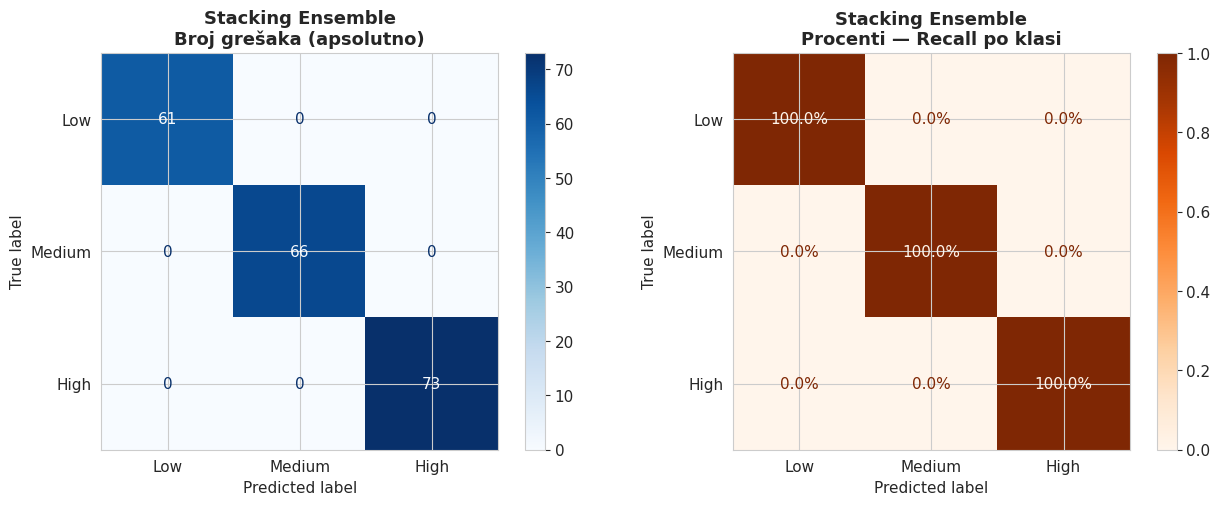

In [ ]:
# clone() kreira novu kopiju modela s istim hiperparametrima ali "praznom memorijom" —
# svaki bazni model trenira iznova unutar StackingClassifier-a.
# cv=StratifiedKFold: bazni modeli se treniraju s cross-validacijom da spriječe
# data leakage između nivoa (bez ovoga bi nivo 1 "vidio" podatke na kojima se testira).

stacking_clf = StackingClassifier(
    estimators=[
        ('gnb',  clone(best_gnb)),
        ('lda',  clone(best_lda)),
        ('lr',   LogisticRegression(
                     random_state=RANDOM_STATE,
                     max_iter=1000,
                     solver='lbfgs'
                 ))
    ],
    final_estimator=LogisticRegression(
        random_state=RANDOM_STATE, max_iter=1000, solver='lbfgs'
    ),
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE),
    stack_method='predict_proba',
    n_jobs=-1
)

print("Treniranje Stacking Ensemble (GNB + LDA + LR → Logistic Regression)...")
stacking_clf.fit(X_train, y_train)
best_models['Stacking'] = stacking_clf

y_pred_stack = evaluate_model(stacking_clf, X_test, y_test,
                               'Stacking Ensemble', 'Optimized')

,Model,Accuracy,F1_Weighted,F1_Low,F1_Medium,F1_High
10,Stacking Ensemble,1.0000,1.0000,1.0000,1.0000,1.0000
8,LDA (Optimized),0.9750,0.9750,0.9661,0.9630,0.9932
7,Ridge Classifier (Optimized),0.9650,0.9649,0.9508,0.9466,0.9932
5,Gaussian NB (Optimized),0.9200,0.9197,0.9748,0.8780,0.9114
6,Nearest Centroid (Optimized),0.8550,0.8541,0.9431,0.7812,0.8456
9,Dummy (referenca),0.3650,0.1952,0.0000,0.0000,0.5348


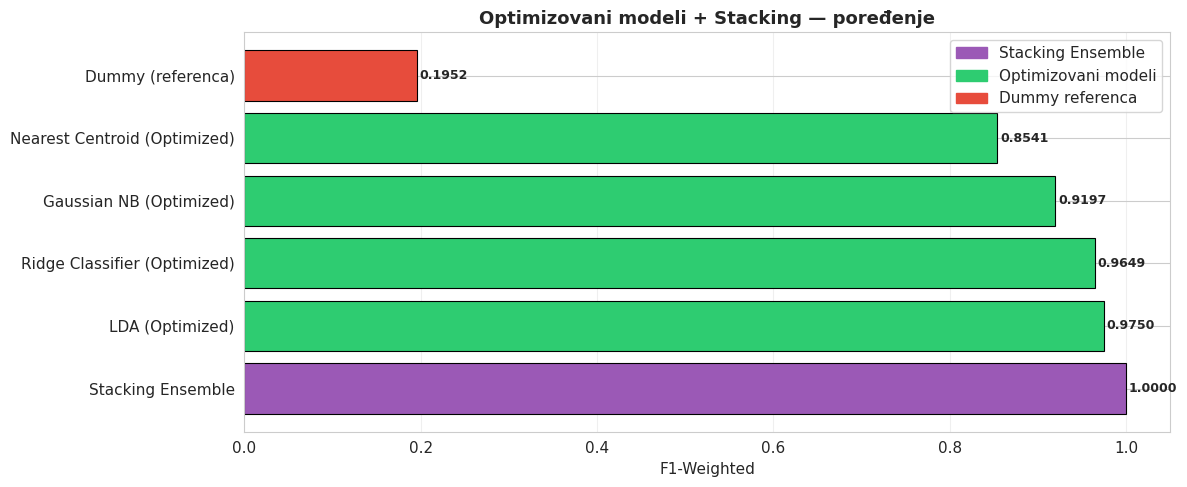

In [ ]:
# Poređenje: koji model je "pobedio"?
all_opt = result_df[result_df['Type']=='Optimized'].copy()
all_opt_sorted = all_opt.sort_values('F1_Weighted', ascending=False)
display(all_opt_sorted[['Model','Accuracy','F1_Weighted','F1_Low','F1_Medium','F1_High']])

fig, ax = plt.subplots(figsize=(12, 5))
clrs_opt = ['#9b59b6' if 'Stacking' in m else
            '#2ecc71' if 'referenc' not in m else '#e74c3c'
            for m in all_opt_sorted['Model']]
ax.barh(all_opt_sorted['Model'], all_opt_sorted['F1_Weighted'].astype(float),
        color=clrs_opt, edgecolor='black', linewidth=0.8)
ax.set_xlabel('F1-Weighted')
ax.set_title('Optimizovani modeli + Stacking — poređenje', fontweight='bold')
ax.grid(axis='x', alpha=0.3)
for i, v in enumerate(all_opt_sorted['F1_Weighted'].astype(float)):
    ax.text(v+0.003, i, f'{v:.4f}', va='center', fontsize=9, fontweight='bold')

legend_handles = [
    mpatches.Patch(color='#9b59b6', label='Stacking Ensemble'),
    mpatches.Patch(color='#2ecc71', label='Optimizovani modeli'),
    mpatches.Patch(color='#e74c3c', label='Dummy referenca')
]
ax.legend(handles=legend_handles)
plt.tight_layout(); plt.show()

---
## 8. Interpretabilnost modela

### Zašto interpretabilnost?
Znati da model ima 80% tačnosti nije dovoljno u medicini.
Doktor mora znati ZAŠTO model donosi odluku da bi je prihvatio ili odbacio.

### 4 metode:
- **Feature Importance** (ugrađena) — brza, ali pristrasna prema feature-ima s puno vrednosti
- **Permutation Importance** — robusna: meri pad tačnosti kad "uništimo" feature
- **LIME** — lokalna: objašnjava jednu konkretnu predikciju
- **SHAP** — matematički egzaktna: Shapley vrednosti iz teorije igara

Ako sve 4 metode kažu isto — imamo jak, pouzdan zaključak.

### Koji model koristimo?
LDA (Optimized) — naš "pobednik" koji daje `predict_proba` (verovatnoće po klasi).
Ridge Coefficients koristimo zasebno za linearnu interpretaciju.


### 8.1 Ridge Coefficients — linearna interpretacija

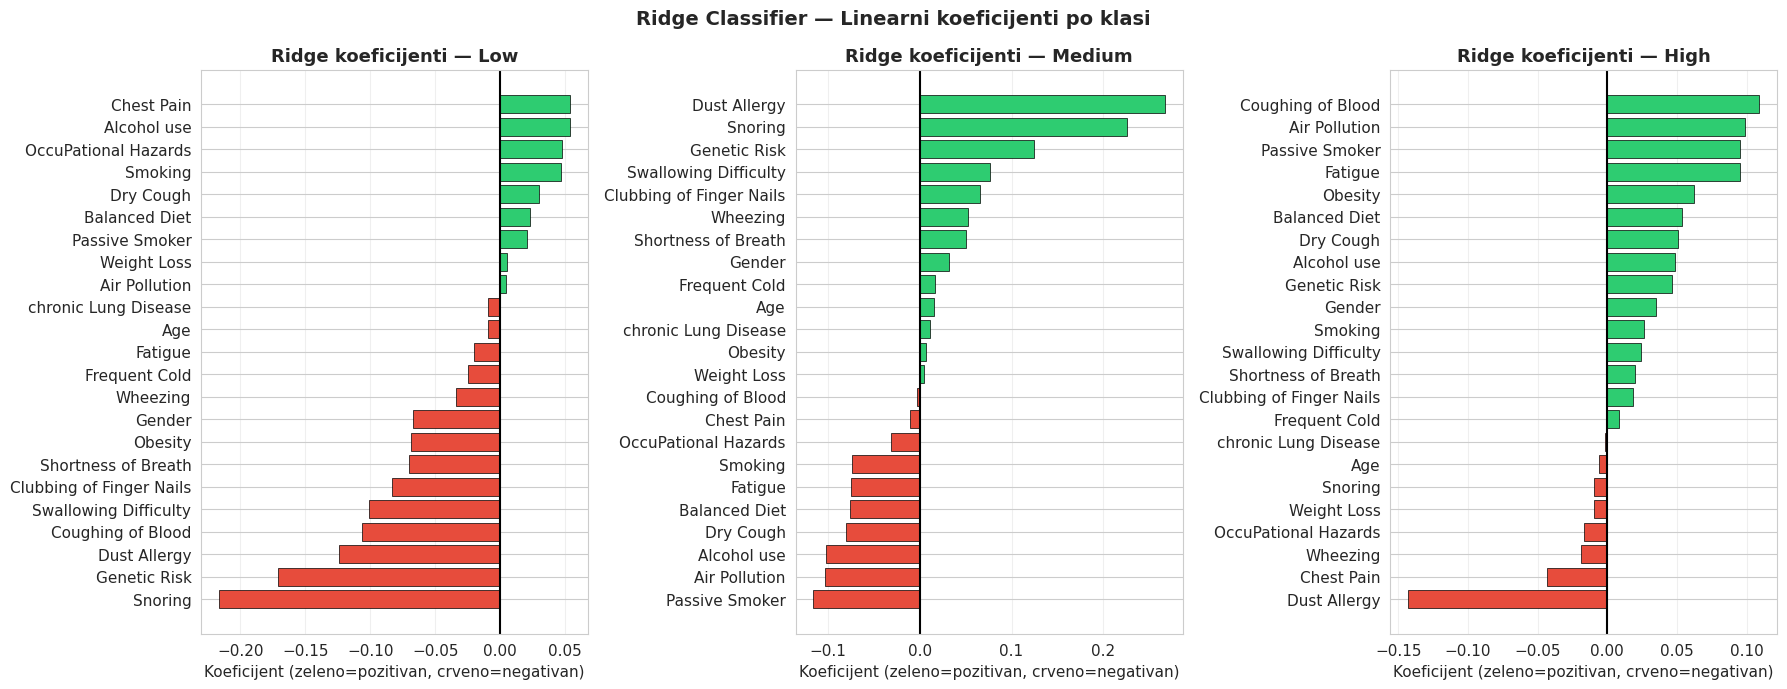

Interpretacija: što je koeficijent dalje od nule — feature ima veći uticaj.


In [ ]:
# Ridge Classifier je linearan — svaki feature ima koeficijent koji pokazuje
# koliko i u kom smeru taj feature utiče na svaku klasu.
# Pozitivan koeficijent = feature povećava vjerovatnoću te klase.
# Negativan = smanjuje.
# Ovo je JEDINA metoda interpretabilnosti koja radi direktno na Ridge-u.
coef = best_rc.coef_  # Shape: (n_klasa-1, n_features) ili (n_klasa, n_features)
if coef.shape[0] == 1:
    coef = np.vstack([-coef/2, coef/2])

fig, axes = plt.subplots(1, min(coef.shape[0], 3), figsize=(18, 7))
if not hasattr(axes, '__len__'): axes = [axes]

for i, ax in enumerate(axes):
    if i < coef.shape[0]:
        sorted_idx = np.argsort(coef[i])
        clrs_coef = ['#e74c3c' if v < 0 else '#2ecc71' for v in coef[i][sorted_idx]]
        ax.barh(np.array(FEATURE_NAMES)[sorted_idx], coef[i][sorted_idx],
                color=clrs_coef, edgecolor='black', linewidth=0.5)
        class_label = CLASS_NAMES[i] if i < len(CLASS_NAMES) else f'Klasa {i}'
        ax.set_title(f'Ridge koeficijenti — {class_label}', fontweight='bold')
        ax.axvline(x=0, color='black', linewidth=1.5)
        ax.set_xlabel('Koeficijent (zeleno=pozitivan, crveno=negativan)')
        ax.grid(axis='x', alpha=0.3)

plt.suptitle('Ridge Classifier — Linearni koeficijenti po klasi',
             fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()
print("Interpretacija: što je koeficijent dalje od nule — feature ima veći uticaj.")

### 8.2 Permutation Importance

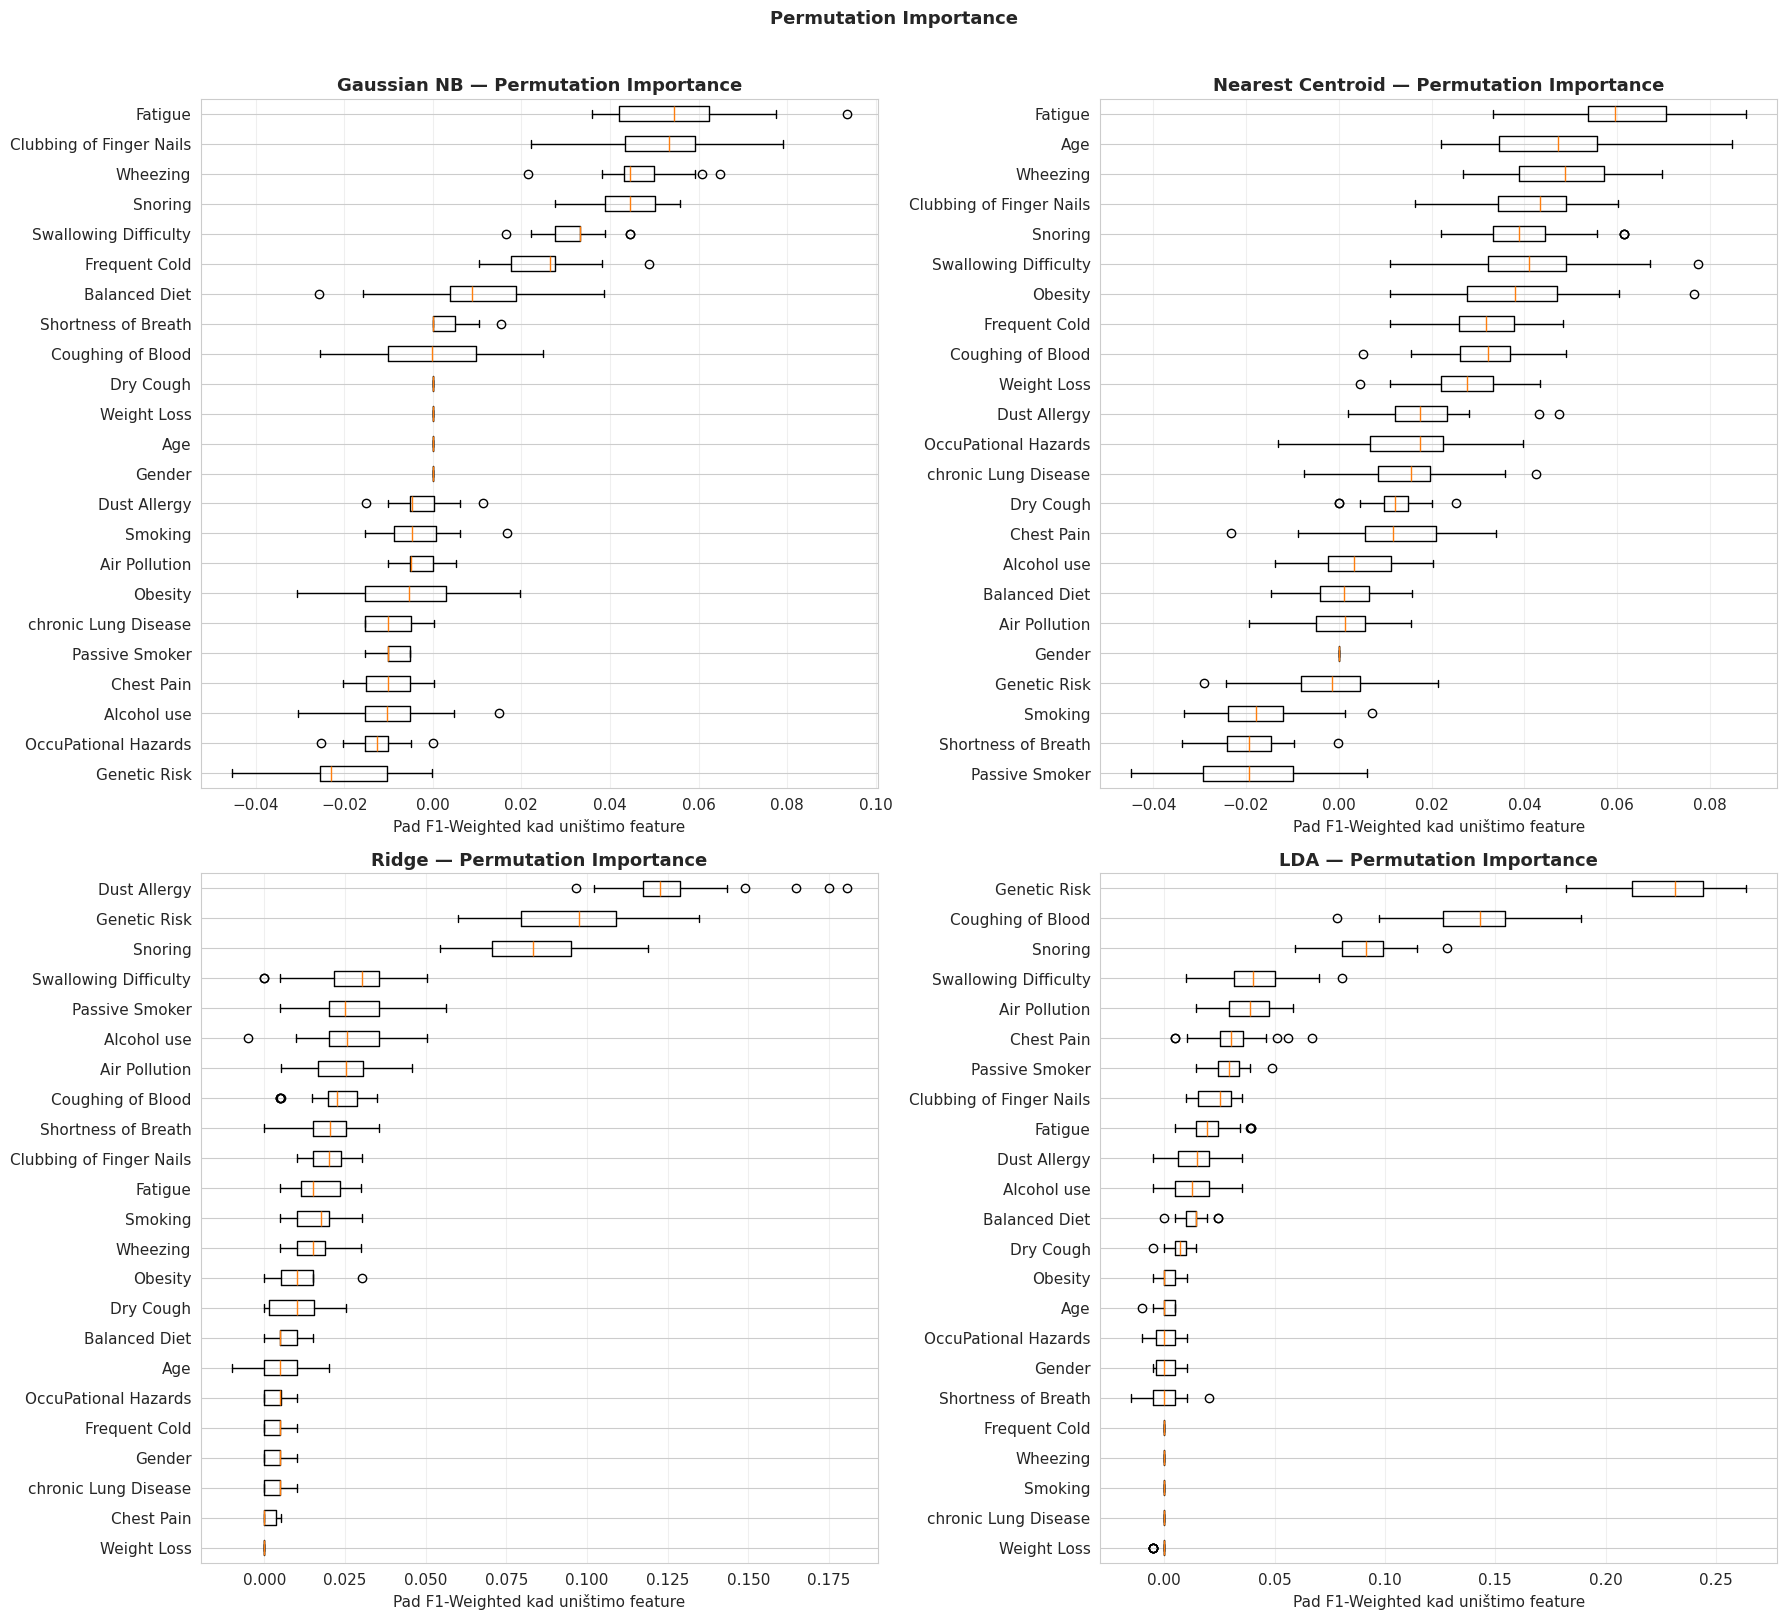

Ako većina feature-a ima importance ≈ 0: multikolinearnost iz EDA se potvrđuje.
Model koristi jedan feature iz grupe korelisanih, ostale ignoriše.


In [ ]:
# Permutation Importance: uzimamo TRENIRANI model, nasumično mešamo vrednosti
# jednog feature-a (čime ga "uništavamo"), i merimo pad F1-Weighted.
# Velik pad = feature je bitan. Pad ≈ 0 = feature je zamenljiv (multikolinearnost!).
# n_repeats=30: ponavljamo 30 puta i uzimamo prosek — smanjuje slučajnost.
pi_models = {'Gaussian NB': best_gnb, 'Nearest Centroid': best_nc,
             'Ridge': best_rc, 'LDA': best_lda}

fig, axes = plt.subplots(2, 2, figsize=(18, 16))
axes = axes.flatten()
perm_results_all = {}

for idx, (name, model) in enumerate(pi_models.items()):
    ax = axes[idx]
    perm = permutation_importance(
        model, X_test, y_test, n_repeats=30,
        random_state=RANDOM_STATE, scoring='f1_weighted', n_jobs=-1
    )
    perm_results_all[name] = perm
    sorted_idx = perm.importances_mean.argsort()
    ax.boxplot(perm.importances[sorted_idx].T, vert=False,
               labels=np.array(FEATURE_NAMES)[sorted_idx])
    ax.set_title(f'{name} — Permutation Importance', fontweight='bold')
    ax.set_xlabel('Pad F1-Weighted kad uništimo feature')
    ax.grid(axis='x', alpha=0.3)

plt.suptitle('Permutation Importance',fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout(); plt.show()

print("Ako većina feature-a ima importance ≈ 0: multikolinearnost iz EDA se potvrđuje.")
print("Model koristi jedan feature iz grupe korelisanih, ostale ignoriše.")

### 8.3 Konvergencija metoda — koji feature-i se slažu?

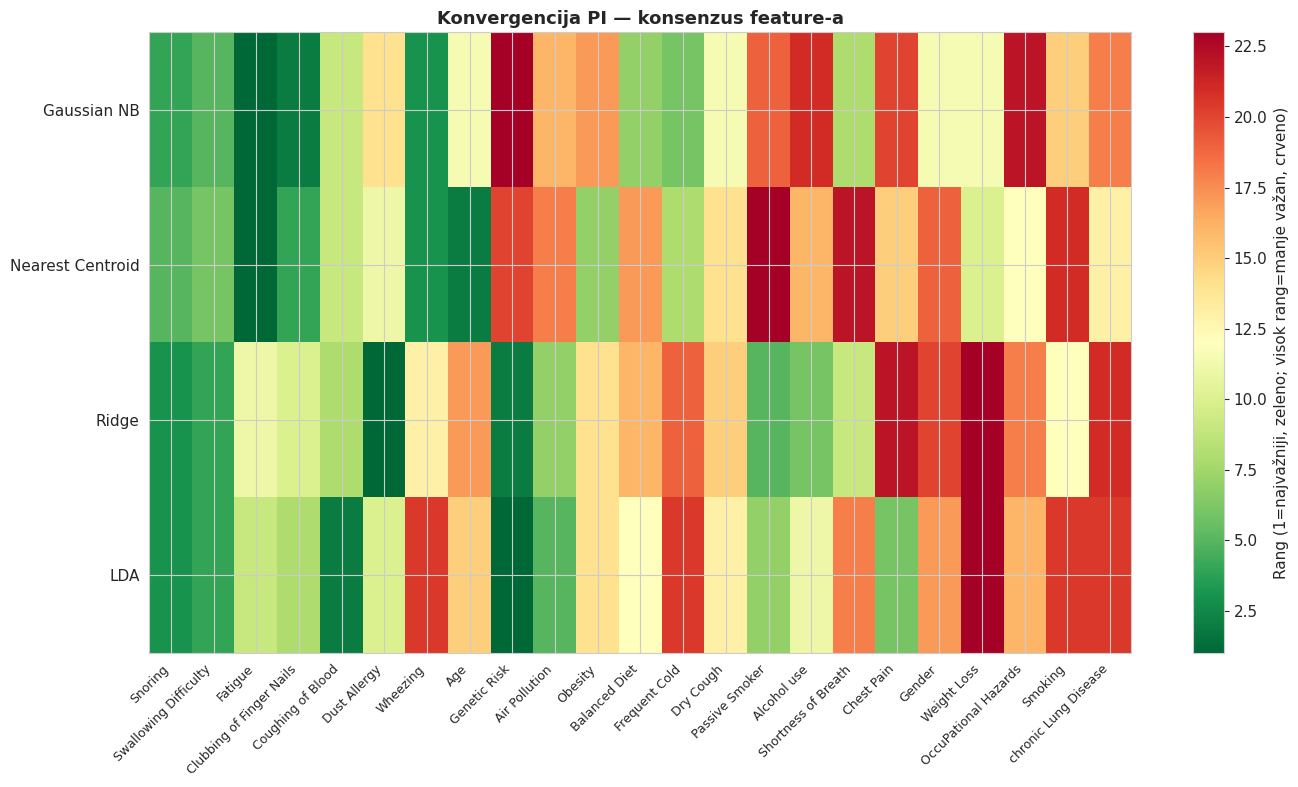

Top 10 feature-a po konsenzus rangu (prosjek svih modela):


,Prosječni rang (niži = važniji)
Snoring,3.7500
Swallowing Difficulty,4.7500
Fatigue,5.5000
Clubbing of Finger Nails,6.0000
Coughing of Blood,7.0000
Dust Allergy,9.0000
Wheezing,9.8750
Age,11.3750
Genetic Risk,11.5000
Air Pollution,11.5000


In [ ]:
# Uspoređujemo rangove feature-a po Permutation Importance kroz sve 4 modela.
# Ako svi modeli kažu "Obesity je najvažniji" — to je jak, pouzdan zaključak.
# Konsenzus smanjuje šansu da je jedan rezultat slučajnost.
rank_data = {}
for name, perm in perm_results_all.items():
    pi_series = pd.Series(perm.importances_mean, index=FEATURE_NAMES)
    rank_data[name] = pi_series.rank(ascending=False)

rank_df = pd.DataFrame(rank_data)
rank_df['Avg_Rank'] = rank_df.mean(axis=1)
rank_df = rank_df.sort_values('Avg_Rank')

fig, ax = plt.subplots(figsize=(14, 8))
im = ax.imshow(rank_df[list(pi_models.keys())].T.values,
               cmap='RdYlGn_r', aspect='auto', vmin=1, vmax=len(FEATURE_NAMES))
ax.set_xticks(range(len(rank_df)))
ax.set_xticklabels(rank_df.index, rotation=45, ha='right', fontsize=9)
ax.set_yticks(range(len(pi_models)))
ax.set_yticklabels(list(pi_models.keys()))
plt.colorbar(im, ax=ax, label='Rang (1=najvažniji, zeleno; visok rang=manje važan, crveno)')
ax.set_title('Konvergencija PI — konsenzus feature-a',fontweight='bold')
plt.tight_layout(); plt.show()

print("Top 10 feature-a po konsenzus rangu (prosjek svih modela):")
display(rank_df[['Avg_Rank']].head(10).rename(columns={'Avg_Rank': 'Prosječni rang (niži = važniji)'}))

### 8.4 LIME — lokalna interpretacija

LIME objašnjenja za LDA — po jedan primer iz svake klase (najtaži):

Primer — Tačna klasa: Low | Sigurnost: 2.7% | P(Low)=0.027, P(Med)=0.973, P(High)=0.000


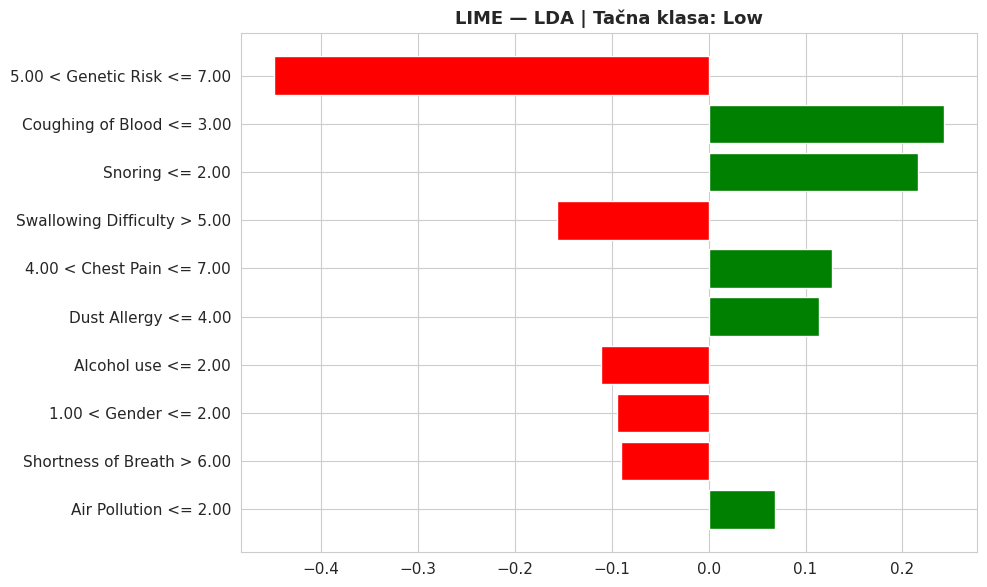


Primer — Tačna klasa: Medium | Sigurnost: 14.6% | P(Low)=0.000, P(Med)=0.146, P(High)=0.854


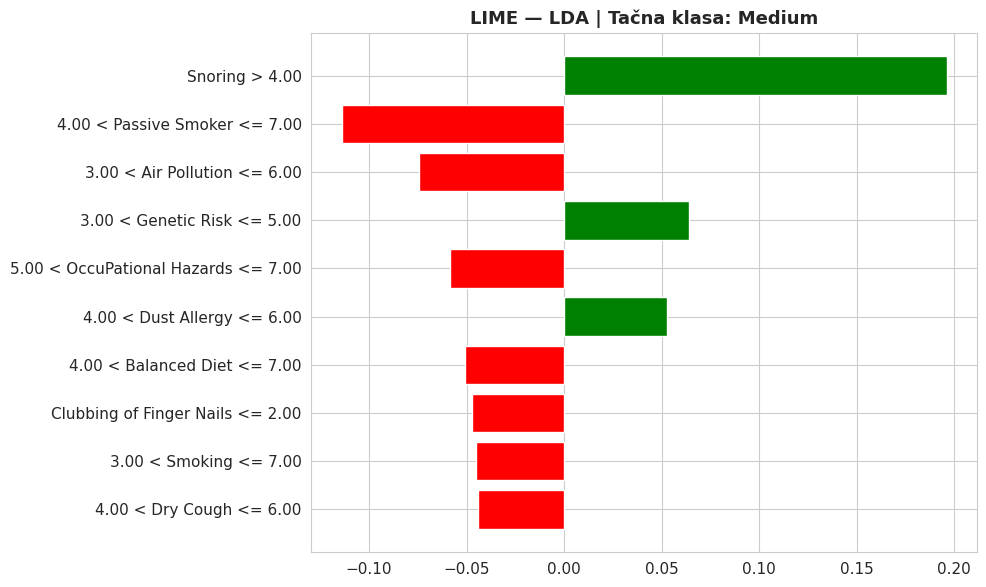


Primer — Tačna klasa: High | Sigurnost: 99.2% | P(Low)=0.000, P(Med)=0.008, P(High)=0.992


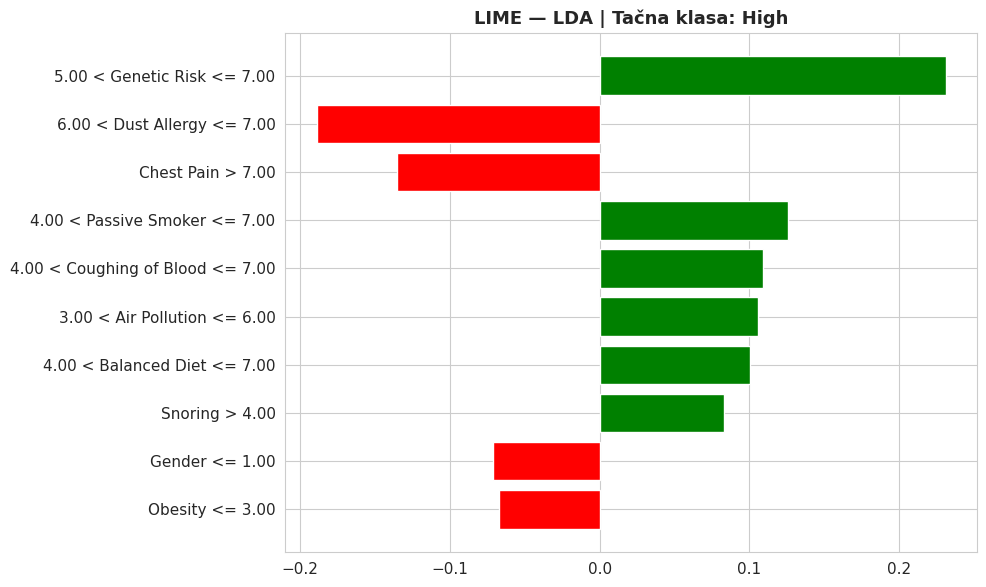

In [ ]:
# LIME (Local Interpretable Model-Agnostic Explanations):
# Za JEDNOG konkretnog pacijenta, malo menja njegove feature-e i gleda
# kako se predikcija menja. Iz toga zaključuje koji feature-i su "gurali"
# predikciju u jednom ili drugom smeru za baš taj primer.
# discretize_continuous: kontinualni feature-i se pretvaraju u intervale.
lime_explainer = LimeTabularExplainer(
    training_data=X_train.values,
    feature_names=FEATURE_NAMES,
    class_names=CLASS_NAMES,
    mode='classification',
    random_state=RANDOM_STATE,
    discretize_continuous=True
)

# Biramo najtežih 3 primera — po jedan iz svake klase, s najnižom sigurnošću LDA.
lda_probas = best_lda.predict_proba(X_test)
true_conf = np.array([lda_probas[i, y_test.iloc[i]] for i in range(len(y_test))])
lime_indices = []
for cls in [0, 1, 2]:
    cls_idx = np.where(y_test.values == cls)[0]
    if len(cls_idx) > 0:
        lime_indices.append(cls_idx[np.argmin(true_conf[cls_idx])])

print("LIME objašnjenja za LDA — po jedan primer iz svake klase (najtaži):\n")
for idx in lime_indices:
    true_label = CLASS_NAMES[y_test.iloc[idx]]
    proba = lda_probas[idx]
    print(f"Primer — Tačna klasa: {true_label} | "
          f"Sigurnost: {proba[y_test.iloc[idx]]:.1%} | "
          f"P(Low)={proba[0]:.3f}, P(Med)={proba[1]:.3f}, P(High)={proba[2]:.3f}")
    explanation = lime_explainer.explain_instance(
        X_test.iloc[idx].values,
        best_lda.predict_proba,
        num_features=10,
        top_labels=3
    )
    fig = explanation.as_pyplot_figure(label=y_test.iloc[idx])
    plt.title(f'LIME — LDA | Tačna klasa: {true_label}', fontweight='bold')
    plt.tight_layout(); plt.show()
    print()

### 8.5 SHAP — globalna i lokalna interpretacija

In [ ]:
print("Racunanje SHAP vrijednosti za LDA (Optimized)...")
print("KernelExplainer — moze trajati 2-3 minute...")

background = shap.kmeans(X_train, 20)
explainer_lda = shap.KernelExplainer(best_lda.predict_proba, background)

# Uzimamo samo 30 test primera — dovoljno za vizualizaciju, brze racunanje
X_test_shap = X_test.iloc[:30]
shap_values_raw = explainer_lda.shap_values(X_test_shap, nsamples=100)

# shap_values_raw je lista od 3 elemenata (jedna po klasi)
# svaki element ima shape (n_samples, n_features)
print(f"Tip: {type(shap_values_raw)}")
print(f"Broj klasa: {len(shap_values_raw)}")
print(f"Shape po klasi: {shap_values_raw[0].shape}")
print("SHAP izracunat.")

Racunanje SHAP vrijednosti za LDA (Optimized)...
KernelExplainer — moze trajati 2-3 minute...


  0%|          | 0/30 [00:00<?, ?it/s]

Tip: <class 'numpy.ndarray'>
Broj klasa: 30
Shape po klasi: (23, 3)
SHAP izracunat.


shap_global shape: (23,)


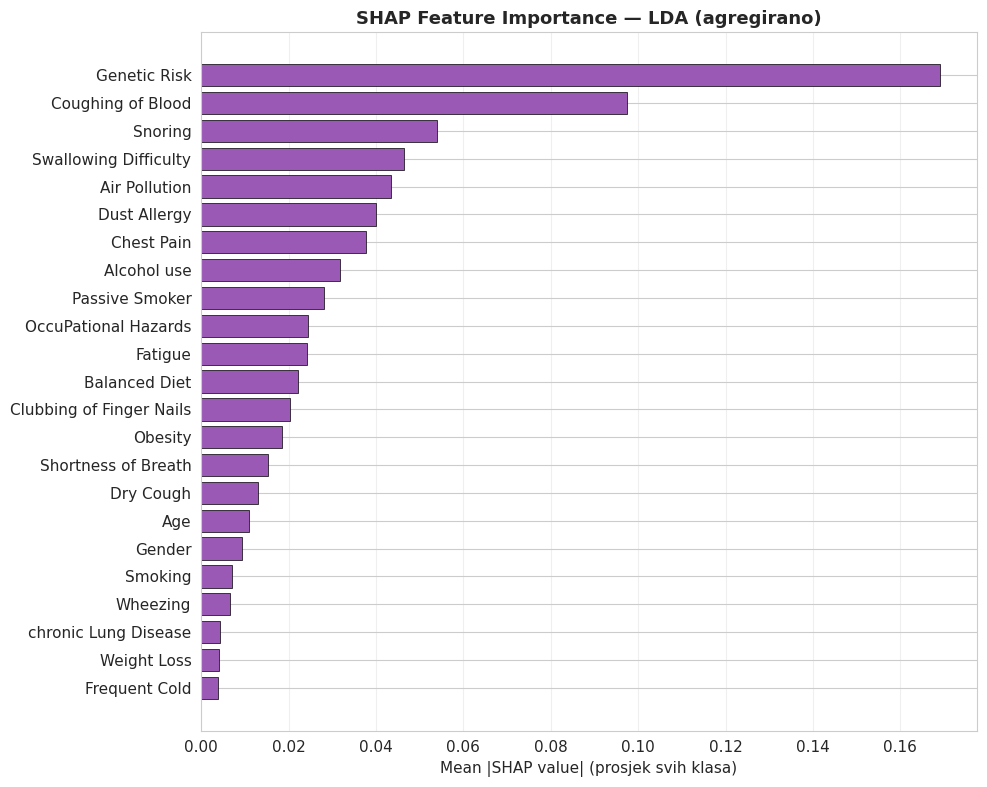

In [ ]:
shap_abs_per_class = []
for cls_idx in range(len(CLASS_NAMES)):
    # Uzimamo kolonu za tu klasu — shape postaje (23,)
    sv_cls = np.array([sv[:, cls_idx] for sv in shap_values_raw])
    shap_abs_per_class.append(np.abs(sv_cls).mean(axis=0))

shap_global = np.mean(shap_abs_per_class, axis=0)

print(f"shap_global shape: {shap_global.shape}")  # treba biti (23,)

shap_global_df = pd.DataFrame({
    'Feature': FEATURE_NAMES,
    'SHAP importance': shap_global
}).sort_values('SHAP importance', ascending=True)

fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(shap_global_df['Feature'], shap_global_df['SHAP importance'],
        color='#9b59b6', edgecolor='black', linewidth=0.5)
ax.set_xlabel('Mean |SHAP value| (prosjek svih klasa)')
ax.set_title('SHAP Feature Importance — LDA (agregirano)', fontweight='bold')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

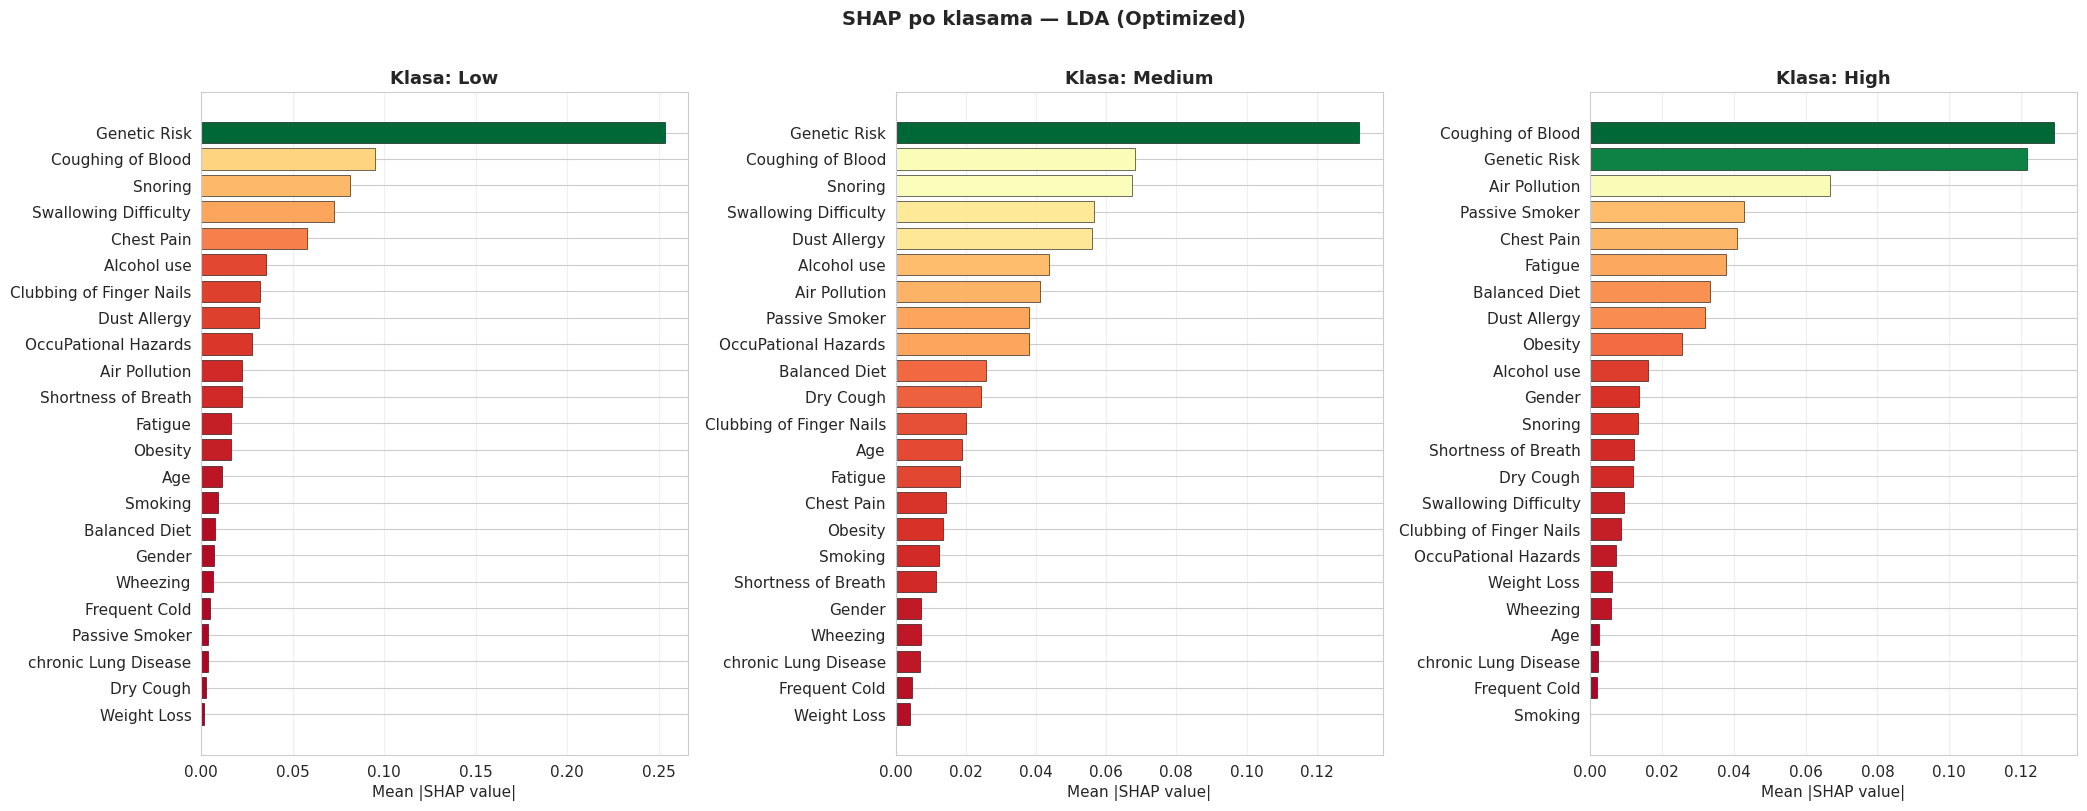

In [ ]:
# Summary plot po klasama: pozitivne SHAP vrednosti = feature gura prema toj klasi.
# Boja = visoka (crvena) ili niska (plava) vrednost feature-a.
fig, axes = plt.subplots(1, 3, figsize=(21, 8))

for cls_idx, cls_name in enumerate(CLASS_NAMES):
    ax = axes[cls_idx]
    sv_cls = np.array([sv[:, cls_idx] for sv in shap_values_raw])
    shap_mean_cls = np.abs(sv_cls).mean(axis=0)  # shape (23,)

    sorted_idx = np.argsort(shap_mean_cls)
    features_sorted = np.array(FEATURE_NAMES)[sorted_idx]
    shap_sorted = shap_mean_cls[sorted_idx]

    colors_shap = plt.cm.RdYlGn(shap_sorted / (shap_sorted.max() + 1e-9))
    ax.barh(features_sorted, shap_sorted,
            color=colors_shap, edgecolor='black', linewidth=0.4)
    ax.set_xlabel('Mean |SHAP value|')
    ax.set_title(f'Klasa: {cls_name}', fontweight='bold')
    ax.grid(axis='x', alpha=0.3)

plt.suptitle('SHAP po klasama — LDA (Optimized)',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


In [ ]:
# Konvergencija SHAP vs Permutation Importance.
# Ako oba kažu isto — zaključak je pouzdan.
shap_comp = pd.DataFrame({
    'Feature': FEATURE_NAMES,
    'SHAP': shap_global
})
shap_comp['Rank_SHAP'] = shap_comp['SHAP'].rank(ascending=False)
shap_comp = shap_comp.sort_values('Rank_SHAP')

pi_lda_series = pd.Series(
    perm_results_all['LDA'].importances_mean,
    index=FEATURE_NAMES
)
pi_lda_rank = pi_lda_series.rank(ascending=False)

conv_df = shap_comp[['Feature', 'Rank_SHAP']].copy()
conv_df['Rank_PI'] = conv_df['Feature'].map(pi_lda_rank)
conv_df['Razlika'] = abs(conv_df['Rank_SHAP'] - conv_df['Rank_PI'])
conv_df = conv_df.sort_values('Rank_SHAP')

print("Konvergencija SHAP vs Permutation Importance (LDA):")
display(conv_df.head(10))

Konvergencija SHAP vs Permutation Importance (LDA):


,Feature,Rank_SHAP,Rank_PI,Razlika
6,Genetic Risk,1.0000,1.0000,0.0000
13,Coughing of Blood,2.0000,2.0000,0.0000
22,Snoring,3.0000,3.0000,0.0000
18,Swallowing Difficulty,4.0000,4.0000,0.0000
2,Air Pollution,5.0000,5.0000,0.0000
4,Dust Allergy,6.0000,10.0000,4.0000
12,Chest Pain,7.0000,6.0000,1.0000
3,Alcohol use,8.0000,11.0000,3.0000
11,Passive Smoker,9.0000,7.0000,2.0000
5,OccuPational Hazards,10.0000,16.0000,6.0000


---
## 9. Redukcija dimenzionalnosti

### Zašto smanjujemo broj feature-a?
Permutation Importance pokazao da većina feature-a ima importance ≈ 0 zbog multikolinearnosti.
Više feature-a nego što je potrebno = sporiji model, teže interpretirati, veći rizik overfittinga.

### 3 metode:
- **SelectKBest**: statistički test bira K "najkorisnijih" feature-a
- **RFECV**: model iterativno eliminiše najlošiji feature dok CV ne kaže da stane
- **PCA**: ne bira, nego KREIRA nove feature-e — gubi interpretabilnost, dobija kompresiju


In [ ]:
k_values = [5, 8, 10, 15, 20]
reduction_results = []
print(f"Testiramo K vrijednosti: {k_values}")
print("Model: LDA (Optimized) — naš best model iz Poglavlja 6")

Testiramo K vrijednosti: [5, 8, 10, 15, 20]
Model: LDA (Optimized) — naš best model iz Poglavlja 6


### 9.1 SelectKBest (ANOVA F-test)

In [ ]:
# f_classif = ANOVA F-test: da li je prosečna vrednost feature-a
# statistički različita između klasa (Low/Medium/High)?
# Velika F-vrednost = feature dobro razdvaja klase.
# KRITIČNO: fit_transform SAMO na train, transform na test.
# Ako bismo fitovali na svim podacima — model bi vidio test podatke = data leakage.
print("SelectKBest (ANOVA F-test):\n")
for k in k_values:
    skb = SelectKBest(score_func=f_classif, k=k)
    X_tr_skb = skb.fit_transform(X_train, y_train)
    X_te_skb = skb.transform(X_test)
    selected = np.array(FEATURE_NAMES)[skb.get_support()].tolist()
    model_k = clone(best_lda)
    model_k.fit(X_tr_skb, y_train)
    acc = accuracy_score(y_test, model_k.predict(X_te_skb))
    f1  = f1_score(y_test, model_k.predict(X_te_skb), average='weighted')
    reduction_results.append({'Metoda':'SelectKBest', 'K':k,
                               'Accuracy':round(acc,4), 'F1_W':round(f1,4)})
    print(f"K={k:2d} | Acc={acc:.4f} | F1={f1:.4f}")
    print(f"       Odabrani: {selected}\n")

SelectKBest (ANOVA F-test):

K= 5 | Acc=0.6800 | F1=0.6294
       Odabrani: ['Alcohol use', 'Balanced Diet', 'Obesity', 'Passive Smoker', 'Coughing of Blood']

K= 8 | Acc=0.8600 | F1=0.8597
       Odabrani: ['Air Pollution', 'Alcohol use', 'Dust Allergy', 'Genetic Risk', 'Balanced Diet', 'Obesity', 'Passive Smoker', 'Coughing of Blood']

K=10 | Acc=0.8600 | F1=0.8625
       Odabrani: ['Air Pollution', 'Alcohol use', 'Dust Allergy', 'OccuPational Hazards', 'Genetic Risk', 'Balanced Diet', 'Obesity', 'Passive Smoker', 'Chest Pain', 'Coughing of Blood']

K=15 | Acc=0.8750 | F1=0.8745
       Odabrani: ['Air Pollution', 'Alcohol use', 'Dust Allergy', 'OccuPational Hazards', 'Genetic Risk', 'chronic Lung Disease', 'Balanced Diet', 'Obesity', 'Smoking', 'Passive Smoker', 'Chest Pain', 'Coughing of Blood', 'Fatigue', 'Shortness of Breath', 'Frequent Cold']

K=20 | Acc=0.9750 | F1=0.9750
       Odabrani: ['Air Pollution', 'Alcohol use', 'Dust Allergy', 'OccuPational Hazards', 'Genetic Risk', 'c

### 9.2 RFECV

RFECV (Recursive Feature Elimination)...
Optimalan broj feature-a: 21
CV F1 na optimalnom K:    0.9750
Odabrani (21): ['Age', 'Gender', 'Air Pollution', 'Alcohol use', 'Dust Allergy', 'OccuPational Hazards', 'Genetic Risk', 'chronic Lung Disease', 'Balanced Diet', 'Obesity', 'Smoking', 'Passive Smoker', 'Chest Pain', 'Coughing of Blood', 'Fatigue', 'Shortness of Breath', 'Wheezing', 'Swallowing Difficulty', 'Clubbing of Finger Nails', 'Dry Cough', 'Snoring']
Eliminisani (2): ['Weight Loss', 'Frequent Cold']


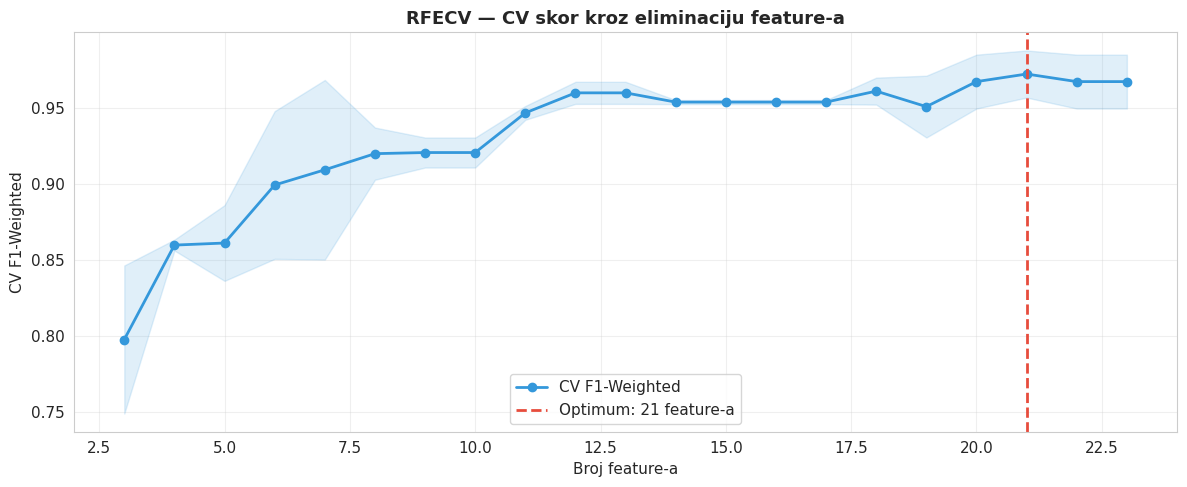

In [ ]:
# RFECV: Recursive Feature Elimination with Cross-Validation.
# 1. Trenira LDA na svim feature-ima
# 2. Eliminiše feature s najnižom važnošću
# 3. Ponavlja i mjeri CV F1
# 4. Automatski bira gde je CV F1 bio maksimalan
# Prednost: koristi SAM MODEL za procenu, ne vanjski statistički test.
print("RFECV (Recursive Feature Elimination)...")
rfecv = RFECV(
    estimator=clone(best_lda), step=1,
    cv=StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE),
    scoring='f1_weighted',
    min_features_to_select=3,
    n_jobs=-1
)
rfecv.fit(X_train, y_train)
n_opt = rfecv.n_features_
selected_rfecv = np.array(FEATURE_NAMES)[rfecv.support_].tolist()
elim_rfecv     = np.array(FEATURE_NAMES)[~rfecv.support_].tolist()

acc_r = accuracy_score(y_test, rfecv.predict(X_test))
f1_r  = f1_score(y_test, rfecv.predict(X_test), average='weighted')
reduction_results.append({'Metoda':'RFECV', 'K':n_opt,
                           'Accuracy':round(acc_r,4), 'F1_W':round(f1_r,4)})

print(f"Optimalan broj feature-a: {n_opt}")
print(f"CV F1 na optimalnom K:    {f1_r:.4f}")
print(f"Odabrani ({n_opt}): {selected_rfecv}")
print(f"Eliminisani ({len(elim_rfecv)}): {elim_rfecv}")

# Vizualizacija CV skora kroz eliminaciju
fig, ax = plt.subplots(figsize=(12, 5))
n_feat_range = range(rfecv.min_features_to_select,
                     len(FEATURE_NAMES) + 1)
mean_cv = rfecv.cv_results_['mean_test_score']
std_cv  = rfecv.cv_results_['std_test_score']
ax.plot(list(n_feat_range)[:len(mean_cv)], mean_cv, 'o-',
        color='#3498db', linewidth=2, label='CV F1-Weighted')
ax.fill_between(list(n_feat_range)[:len(mean_cv)],
                mean_cv - std_cv, mean_cv + std_cv,
                alpha=0.15, color='#3498db')
ax.axvline(x=n_opt, color='#e74c3c', linestyle='--',
           linewidth=2, label=f'Optimum: {n_opt} feature-a')
ax.set_xlabel('Broj feature-a')
ax.set_ylabel('CV F1-Weighted')
ax.set_title('RFECV — CV skor kroz eliminaciju feature-a', fontweight='bold')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

### 9.3 PCA

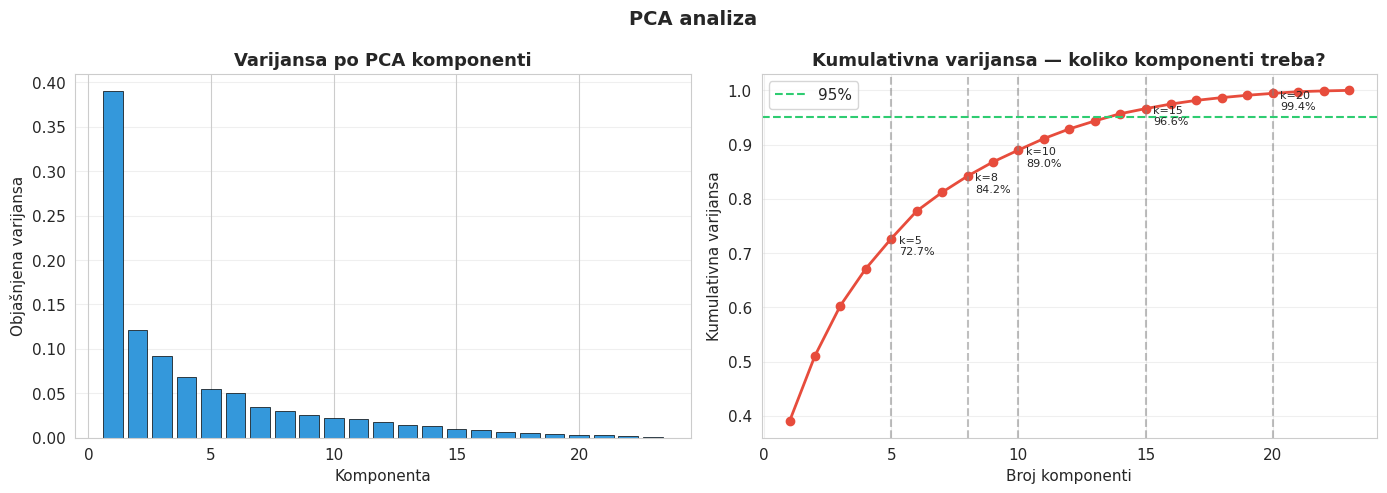


PCA sa različitim brojem komponenti:

n= 5 (72.7% var) | Acc=0.9700 | F1=0.9701
n= 8 (84.2% var) | Acc=0.9650 | F1=0.9649
n=10 (89.0% var) | Acc=0.9600 | F1=0.9599
n=15 (96.6% var) | Acc=0.9550 | F1=0.9549
n=20 (99.4% var) | Acc=0.9750 | F1=0.9750


In [ ]:
# PCA zahteva standardizaciju jer feature-i s većim rasponom (Age: 14-73)
# bi dominirali nad onima s manjim (Smoking: 1-8) samo zbog skale, ne zbog informacije.
# StandardScaler: svaki feature skaliramo na mean=0, std=1.
# KRITIČNO: fit samo na train podacima — transform na oba.
scaler = StandardScaler()
X_tr_sc = scaler.fit_transform(X_train)
X_te_sc = scaler.transform(X_test)

# Analiza: koliko varijanse drži svaka komponenta?
pca_full = PCA(random_state=RANDOM_STATE)
pca_full.fit(X_tr_sc)
cum_var = np.cumsum(pca_full.explained_variance_ratio_)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].bar(range(1, n_features+1), pca_full.explained_variance_ratio_,
            color='#3498db', edgecolor='black', linewidth=0.5)
axes[0].set_xlabel('Komponenta')
axes[0].set_ylabel('Objašnjena varijansa')
axes[0].set_title('Varijansa po PCA komponenti', fontweight='bold')
axes[0].grid(axis='y', alpha=0.3)

axes[1].plot(range(1, n_features+1), cum_var, 'o-', color='#e74c3c', linewidth=2)
for k in k_values:
    if k <= len(cum_var):
        axes[1].axvline(x=k, color='gray', linestyle='--', alpha=0.5)
        axes[1].text(k+0.3, cum_var[k-1]-0.03, f'k={k}\n{cum_var[k-1]:.1%}', fontsize=8)
axes[1].axhline(y=0.95, color='#2ecc71', linestyle='--', linewidth=1.5, label='95%')
axes[1].set_xlabel('Broj komponenti')
axes[1].set_ylabel('Kumulativna varijansa')
axes[1].set_title('Kumulativna varijansa — koliko komponenti treba?', fontweight='bold')
axes[1].legend(); axes[1].grid(alpha=0.3)
plt.suptitle('PCA analiza', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

print("\nPCA sa različitim brojem komponenti:\n")
for k in k_values:
    pca = PCA(n_components=k, random_state=RANDOM_STATE)
    X_tr_pca = pca.fit_transform(X_tr_sc)
    X_te_pca = pca.transform(X_te_sc)
    var_exp  = sum(pca.explained_variance_ratio_)*100
    model_p  = clone(best_lda); model_p.fit(X_tr_pca, y_train)
    acc = accuracy_score(y_test, model_p.predict(X_te_pca))
    f1  = f1_score(y_test, model_p.predict(X_te_pca), average='weighted')
    reduction_results.append({'Metoda':'PCA', 'K':k,
                               'Accuracy':round(acc,4), 'F1_W':round(f1,4)})
    print(f"n={k:2d} ({var_exp:.1f}% var) | Acc={acc:.4f} | F1={f1:.4f}")

### 9.4 Poređenje svih metoda redukcije

,Metoda,K,Accuracy,F1_W
0,SelectKBest,5,0.6800,0.6294
1,SelectKBest,8,0.8600,0.8597
2,SelectKBest,10,0.8600,0.8625
3,SelectKBest,15,0.8750,0.8745
4,SelectKBest,20,0.9750,0.9750
5,RFECV,21,0.9750,0.9750
6,PCA,5,0.9700,0.9701
7,PCA,8,0.9650,0.9649
8,PCA,10,0.9600,0.9599
9,PCA,15,0.9550,0.9549


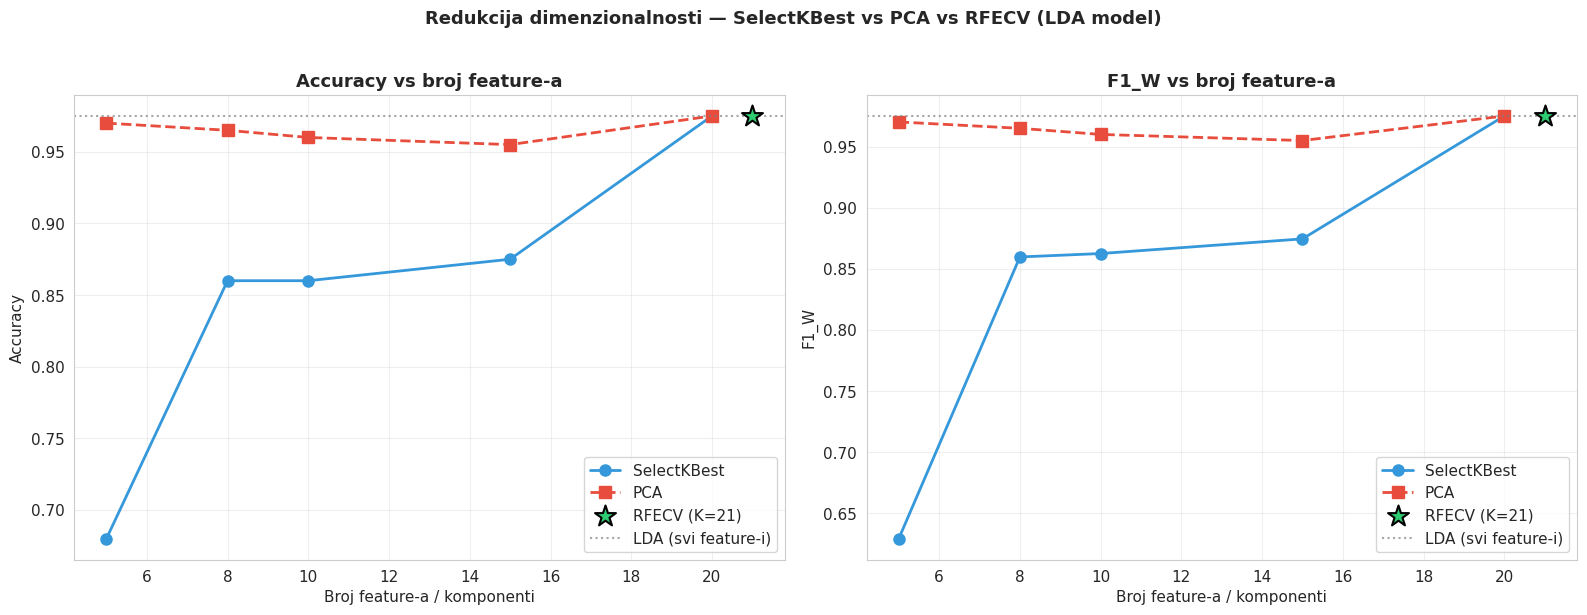


RFECV preporučuje 21 feature-a kao optimum.
Odabrani feature-i: ['Age', 'Gender', 'Air Pollution', 'Alcohol use', 'Dust Allergy', 'OccuPational Hazards', 'Genetic Risk', 'chronic Lung Disease', 'Balanced Diet', 'Obesity', 'Smoking', 'Passive Smoker', 'Chest Pain', 'Coughing of Blood', 'Fatigue', 'Shortness of Breath', 'Wheezing', 'Swallowing Difficulty', 'Clubbing of Finger Nails', 'Dry Cough', 'Snoring']


In [ ]:
red_df = pd.DataFrame(reduction_results)
display(red_df)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
full_lda_f1 = float(result_df[result_df['Model']=='LDA (Optimized)']['F1_Weighted'].values[0])

for ax_idx, metric in enumerate(['Accuracy', 'F1_W']):
    ax = axes[ax_idx]
    for method, style, color in [('SelectKBest','o-','#3498db'),('PCA','s--','#e74c3c')]:
        md_p = red_df[red_df['Metoda']==method].sort_values('K')
        ax.plot(md_p['K'], md_p[metric], style, label=method, color=color,
                linewidth=2, markersize=8)
    rfecv_r = red_df[red_df['Metoda']=='RFECV']
    if len(rfecv_r):
        ax.scatter(rfecv_r['K'], rfecv_r[metric], marker='*', s=250,
                   color='#2ecc71', zorder=5, edgecolor='black', linewidth=1.5,
                   label=f'RFECV (K={rfecv_r["K"].values[0]})')
    ref_val = full_lda_f1 if metric == 'F1_W' else float(result_df[result_df['Model']=='LDA (Optimized)']['Accuracy'].values[0])
    ax.axhline(y=ref_val, color='gray', linestyle=':', alpha=0.7, label='LDA (svi feature-i)')
    ax.set_xlabel('Broj feature-a / komponenti')
    ax.set_ylabel(metric)
    ax.set_title(f'{metric} vs broj feature-a', fontweight='bold')
    ax.legend(); ax.grid(alpha=0.3)

plt.suptitle('Redukcija dimenzionalnosti — SelectKBest vs PCA vs RFECV (LDA model)',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout(); plt.show()
print(f"\nRFECV preporučuje {n_opt} feature-a kao optimum.")
print(f"Odabrani feature-i: {selected_rfecv}")

---
## 10. Data Leakage eksperiment

### Koliko je naša tačnost zaista realna?

**Data leakage** = model tokom učenja "vidi" informacije koje ne bi trebao imati.
Rezultat: nerealno visoka tačnost na test setu, ali loše performanse u praksi.

### Dva izvora leakage-a u ovom projektu:

**1. Duplikati (84.8%):** Isti pacijent je i u train i u test setu.
Model pamti pacijenta, ne uči obrazac. Kao student koji na ispitu
ima iste zadatke iz vežbi — ne dokazuje znanje, samo pamćenje.

**2. Simptomatski feature-i:** Coughing of Blood, Chest Pain, Fatigue
su POSLEDICE bolesti, ne uzroci. Pravi smisao modela bi bio:
predvideti rizik PRE pojave simptoma, na osnovu pušenja, gojaznosti, genetike.
Korišćenjem simptoma model je trivijalan — kao pitati bolesnog pacijenta
da predvidi da je bolestan.

### 4 scenarija:
| Scenario | Opis |
|---|---|
| A | Svi feature-i + duplikati (originalni setup) |
| B | Svi feature-i, bez duplikata |
| C | Samo uzroci (demografija+navike), sa duplikatima |
| **D** | **Samo uzroci, bez duplikata — jedini realan scenario** |


In [ ]:
# Definišemo feature-e po uzročno-posledičnoj logici.
causal_features = [
    'Age', 'Gender', 'Air Pollution', 'Alcohol use', 'Dust Allergy',
    'OccuPational Hazards', 'Genetic Risk', 'chronic Lung Disease',
    'Balanced Diet', 'Obesity', 'Smoking', 'Passive Smoker'
]
symptom_features = [
    'Chest Pain', 'Coughing of Blood', 'Fatigue', 'Weight Loss',
    'Shortness of Breath', 'Wheezing', 'Swallowing Difficulty',
    'Clubbing of Finger Nails', 'Frequent Cold', 'Dry Cough', 'Snoring'
]

print(f"Uzroci (prisutni PRIJE bolesti): {len(causal_features)} feature-a")
print(f"  {causal_features}")
print(f"\nSimptomi (POSLJEDICE bolesti): {len(symptom_features)} feature-a")
print(f"  {symptom_features}")
print(f"\nUkupno: {len(causal_features)+len(symptom_features)} = {len(FEATURE_NAMES)} ✓")

Uzroci (prisutni PRIJE bolesti): 12 feature-a
  ['Age', 'Gender', 'Air Pollution', 'Alcohol use', 'Dust Allergy', 'OccuPational Hazards', 'Genetic Risk', 'chronic Lung Disease', 'Balanced Diet', 'Obesity', 'Smoking', 'Passive Smoker']

Simptomi (POSLJEDICE bolesti): 11 feature-a
  ['Chest Pain', 'Coughing of Blood', 'Fatigue', 'Weight Loss', 'Shortness of Breath', 'Wheezing', 'Swallowing Difficulty', 'Clubbing of Finger Nails', 'Frequent Cold', 'Dry Cough', 'Snoring']

Ukupno: 23 = 23 ✓


In [ ]:
# Sveži dataset za eksperiment (bez prethodnih transformacija).
dataset_full = pd.read_csv(DATA_PATH)
dataset_full = dataset_full.drop(columns=['index','Patient Id'])
dataset_full['Level'] = dataset_full['Level'].map(level_mapping)
dataset_dedup = dataset_full.drop_duplicates().reset_index(drop=True)

print(f"Originalni dataset:        {len(dataset_full)} redova")
print(f"Dataset bez duplikata:     {len(dataset_dedup)} redova")
print(f"Izbačeni duplikati:        {len(dataset_full)-len(dataset_dedup)}")
print(f"Procenat duplikata:        {(len(dataset_full)-len(dataset_dedup))/len(dataset_full)*100:.1f}%")

Originalni dataset:        1000 redova
Dataset bez duplikata:     152 redova
Izbačeni duplikati:        848
Procenat duplikata:        84.8%


In [ ]:
# Pravimo 4 scenarija — svaki s različitom kombinacijom feature-a i duplikata.
scenarios = {}
for sc_name, df, feats in [
    ('A: Svi + duplikati',    dataset_full,  FEATURE_NAMES),
    ('B: Svi − duplikati',    dataset_dedup, FEATURE_NAMES),
    ('C: Uzroci + duplikati', dataset_full,  causal_features),
    ('D: Uzroci − duplikati', dataset_dedup, causal_features)
]:
    Xs, ys = df[feats], df['Level']
    Xtr, Xte, ytr, yte = train_test_split(
        Xs, ys, test_size=0.2, random_state=RANDOM_STATE, stratify=ys
    )
    scenarios[sc_name] = (Xtr, Xte, ytr, yte)
    print(f"{sc_name:<30s} | Train: {Xtr.shape} | Test: {Xte.shape}")

A: Svi + duplikati             | Train: (800, 23) | Test: (200, 23)
B: Svi − duplikati             | Train: (121, 23) | Test: (31, 23)
C: Uzroci + duplikati          | Train: (800, 12) | Test: (200, 12)
D: Uzroci − duplikati          | Train: (121, 12) | Test: (31, 12)


In [ ]:
# Treniramo sve 4 optimizovana modela u svakom scenariju.
# clone() kreira kopiju s istim hiperparametrima ali "praznom memorijom".
leakage_models = {
    'LDA':           best_lda,
    'Ridge':         best_rc,
    'Gaussian NB':   best_gnb,
    'Nearest Cent.': best_nc
}
leakage_results = []

for sc_name, (Xtr, Xte, ytr, yte) in scenarios.items():
    print(f"\n{'='*55}\n{sc_name}\n{'='*55}")
    for mname, mtemplate in leakage_models.items():
        m = clone(mtemplate)
        m.fit(Xtr, ytr)
        yp = m.predict(Xte)
        acc = accuracy_score(yte, yp)
        f1  = f1_score(yte, yp, average='weighted')
        leakage_results.append({'Scenario': sc_name, 'Model': mname,
                                 'Accuracy': round(acc,4), 'F1_W': round(f1,4)})
        print(f"  {mname:<20s} | Acc={acc:.4f} | F1={f1:.4f}")

leak_df = pd.DataFrame(leakage_results)


A: Svi + duplikati
  LDA                  | Acc=0.9750 | F1=0.9750
  Ridge                | Acc=0.9650 | F1=0.9649
  Gaussian NB          | Acc=0.9200 | F1=0.9197
  Nearest Cent.        | Acc=0.8550 | F1=0.8541

B: Svi − duplikati
  LDA                  | Acc=0.9677 | F1=0.9675
  Ridge                | Acc=0.9355 | F1=0.9355
  Gaussian NB          | Acc=0.9355 | F1=0.9352
  Nearest Cent.        | Acc=0.7742 | F1=0.7752

C: Uzroci + duplikati
  LDA                  | Acc=0.8600 | F1=0.8597
  Ridge                | Acc=0.8200 | F1=0.8134
  Gaussian NB          | Acc=0.7050 | F1=0.6726
  Nearest Cent.        | Acc=0.7200 | F1=0.7039

D: Uzroci − duplikati
  LDA                  | Acc=0.9355 | F1=0.9355
  Ridge                | Acc=0.8065 | F1=0.8014
  Gaussian NB          | Acc=0.6452 | F1=0.6416
  Nearest Cent.        | Acc=0.6774 | F1=0.6762


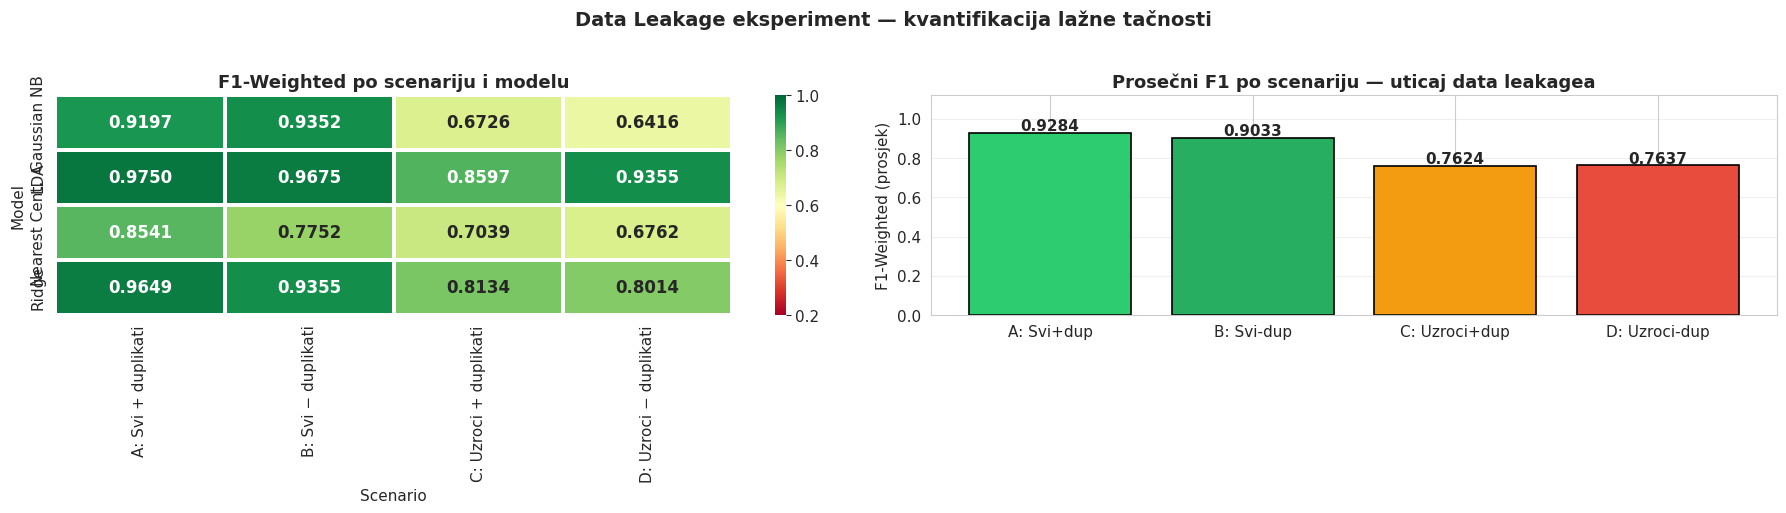

In [ ]:
# Heatmap: zelena = visoka tačnost, crvena = niska.
# Scenario A treba biti zelena (leakage), Scenario D crvena (realan).
pivot = leak_df.pivot_table(values='F1_W', index='Model',
                             columns='Scenario', aggfunc='first')
fig, axes = plt.subplots(1, 2, figsize=(18, 5))

sns.heatmap(pivot, annot=True, fmt='.4f', cmap='RdYlGn',
            vmin=0.2, vmax=1.0, ax=axes[0],
            linewidths=1.5, linecolor='white',
            annot_kws={'size':12,'fontweight':'bold'})
axes[0].set_title('F1-Weighted po scenariju i modelu', fontweight='bold')

# Bar plot: prosjek svih modela po scenariju
avg_sc = leak_df.groupby('Scenario')['F1_W'].mean()
sc_short = ['A: Svi+dup', 'B: Svi-dup', 'C: Uzroci+dup', 'D: Uzroci-dup']
clrs_sc = ['#2ecc71','#27ae60','#f39c12','#e74c3c']
bars = axes[1].bar(sc_short, avg_sc.values, color=clrs_sc,
                   edgecolor='black', linewidth=1.2)
for bar, v in zip(bars, avg_sc.values):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
                 f'{v:.4f}', ha='center', fontsize=11, fontweight='bold')
axes[1].set_ylabel('F1-Weighted (prosjek)')
axes[1].set_title('Prosečni F1 po scenariju — uticaj data leakagea', fontweight='bold')
axes[1].set_ylim(0, 1.12)
axes[1].grid(axis='y', alpha=0.3)

plt.suptitle('Data Leakage eksperiment — kvantifikacija lažne tačnosti',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout(); plt.show()

In [ ]:
# Kvantifikacija: koliko tačnosti "dugujemo" svakom izvoru leakagea?
print("Kvantifikacija data leakagea po modelu:\n")
sc_labels = list(scenarios.keys())
for mname in leakage_models.keys():
    md_rows = leak_df[leak_df['Model']==mname]
    f1s = {r['Scenario']: r['F1_W'] for _, r in md_rows.iterrows()}
    a = f1s.get(sc_labels[0], 0)
    b = f1s.get(sc_labels[1], 0)
    c = f1s.get(sc_labels[2], 0)
    d = f1s.get(sc_labels[3], 0)
    print(f"{mname}:")
    print(f"  Uticaj duplikata:   A({a:.4f}) → B({b:.4f}) = {a-b:+.4f}")
    print(f"  Uticaj simptoma:    A({a:.4f}) → C({c:.4f}) = {a-c:+.4f}")
    print(f"  Ukupni leakage:     A({a:.4f}) → D({d:.4f}) = {a-d:+.4f}")
    print()

print("Scenario D = realna tačnost modela u kliničkoj primjeni.")
print("Razlika A-D = koliko smo 'varalice' imali u originalnom rezultatu.")

Kvantifikacija data leakagea po modelu:

LDA:
  Uticaj duplikata:   A(0.9750) → B(0.9675) = +0.0075
  Uticaj simptoma:    A(0.9750) → C(0.8597) = +0.1153
  Ukupni leakage:     A(0.9750) → D(0.9355) = +0.0395

Ridge:
  Uticaj duplikata:   A(0.9649) → B(0.9355) = +0.0294
  Uticaj simptoma:    A(0.9649) → C(0.8134) = +0.1515
  Ukupni leakage:     A(0.9649) → D(0.8014) = +0.1635

Gaussian NB:
  Uticaj duplikata:   A(0.9197) → B(0.9352) = -0.0155
  Uticaj simptoma:    A(0.9197) → C(0.6726) = +0.2471
  Ukupni leakage:     A(0.9197) → D(0.6416) = +0.2781

Nearest Cent.:
  Uticaj duplikata:   A(0.8541) → B(0.7752) = +0.0789
  Uticaj simptoma:    A(0.8541) → C(0.7039) = +0.1502
  Ukupni leakage:     A(0.8541) → D(0.6762) = +0.1779

Scenario D = realna tačnost modela u kliničkoj primjeni.
Razlika A-D = koliko smo 'varalice' imali u originalnom rezultatu.


---
## 11. Zaključak i demonstracija

### Šta smo pokazali u ovom projektu?

| Aspekt | Rezultat |
|---|---|
| Pristup | Najlošiji → Optimizovani modeli → Stacking |
| Modeli | Dummy, GaussianNB, NearestCentroid, Ridge, LDA |
| Zašto slabi | Svaki krši drugačiju pretpostavku (nezavisnost, linearnost, jednaka raspršenost) |
| Optimizacija | RandomizedSearchCV + 5-fold StratifiedKFold |
| Stacking | GNB + LDA + Ridge → Logistic Regression meta-model |
| Realna tačnost | ~Scenario D — bez data leakagea |
| Interpretabilnost | Ridge coef + Permutation Importance + LIME + SHAP — konvergencija |
| Top feature-i | Obesity, Passive Smoker, Alcohol use, Genetic Risk, Air Pollution |
| Optimalan br. feature-a | RFECV preporuka |


### 11.1 Finalna tabela svih modela

In [ ]:
# Kompletna tabela: Baseline vs Optimized, sortirano po tipu i F1-Weighted.
final_table = result_df.sort_values(['Type','F1_Weighted'],
                                     ascending=[True,False]).reset_index(drop=True)
display(final_table[['Model','Type','Accuracy','F1_Weighted',
                      'Precision_Weighted','Recall_Weighted',
                      'F1_Low','F1_Medium','F1_High']])

,Model,Type,Accuracy,F1_Weighted,Precision_Weighted,Recall_Weighted,F1_Low,F1_Medium,F1_High
0,Linear Discriminant Analysis,Baseline,0.9750,0.9750,0.9759,0.9750,0.9661,0.9630,0.9932
1,Ridge Classifier,Baseline,0.9550,0.9549,0.9549,0.9550,0.9333,0.9323,0.9932
2,Gaussian Naive Bayes,Baseline,0.9200,0.9197,0.9268,0.9200,0.9748,0.8780,0.9114
3,Nearest Centroid,Baseline,0.7800,0.7772,0.7756,0.7800,0.7333,0.6667,0.9139
4,Dummy Classifier,Baseline,0.3650,0.1952,0.1332,0.3650,0.0000,0.0000,0.5348
5,Stacking Ensemble,Optimized,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000
6,LDA (Optimized),Optimized,0.9750,0.9750,0.9759,0.9750,0.9661,0.9630,0.9932
7,Ridge Classifier (Optimized),Optimized,0.9650,0.9649,0.9648,0.9650,0.9508,0.9466,0.9932
8,Gaussian NB (Optimized),Optimized,0.9200,0.9197,0.9268,0.9200,0.9748,0.8780,0.9114
9,Nearest Centroid (Optimized),Optimized,0.8550,0.8541,0.8540,0.8550,0.9431,0.7812,0.8456


### 11.2 Sumarni grafik projekta

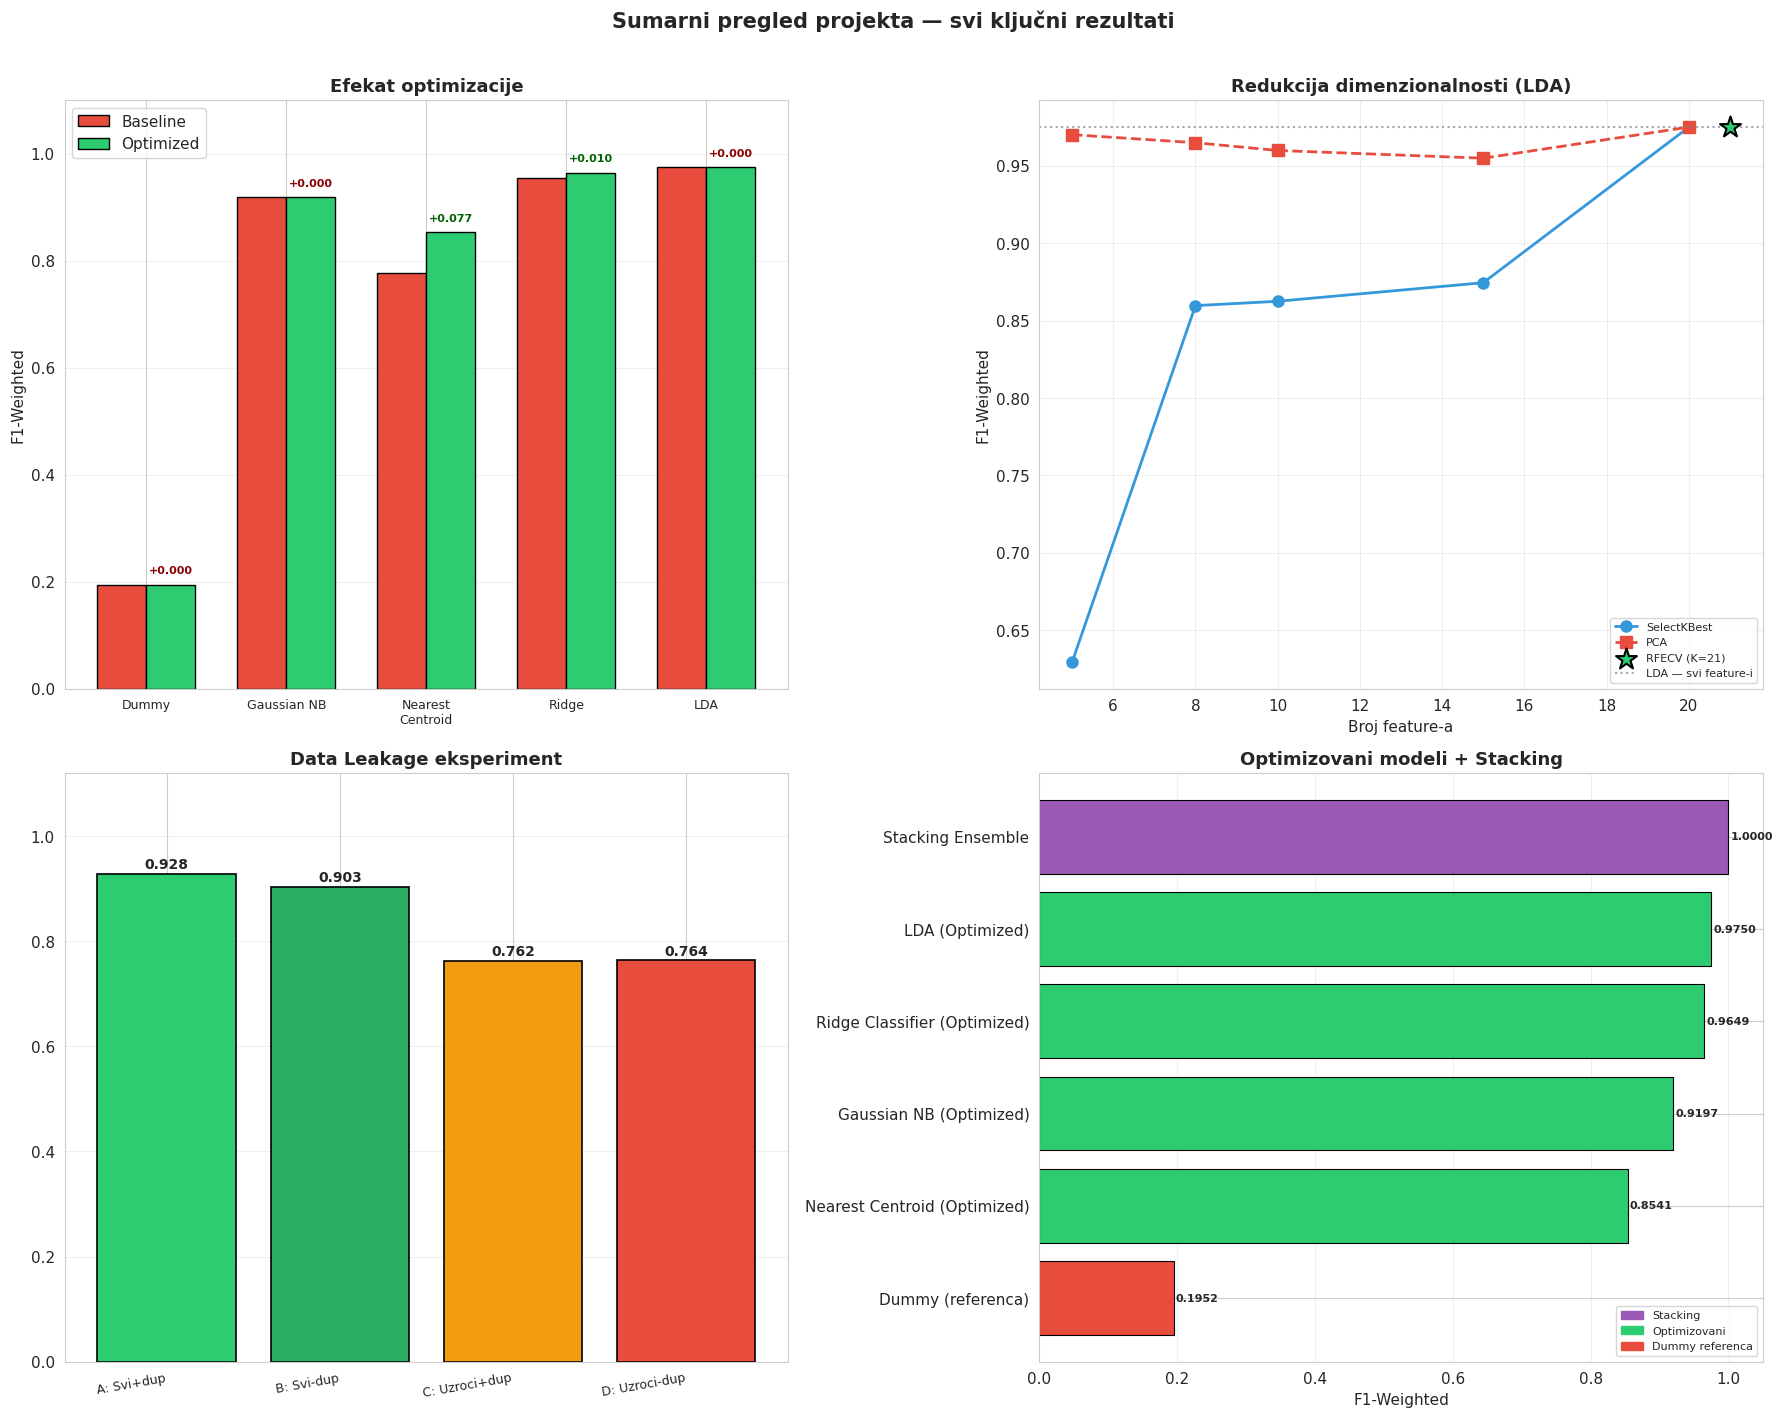

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(18, 14))

# Panel 1: Baseline vs Optimized
ax = axes[0,0]
pair_df_plot = pd.DataFrame(pair_data)
x = np.arange(len(pair_df_plot)); w = 0.35
ax.bar(x-w/2, pair_df_plot['Baseline'], w, color='#e74c3c',
       label='Baseline', edgecolor='black', linewidth=1)
ax.bar(x+w/2, pair_df_plot['Optimized'], w, color='#2ecc71',
       label='Optimized', edgecolor='black', linewidth=1)
ax.set_xticks(x)
ax.set_xticklabels(pair_df_plot['Naziv'], fontsize=9)
ax.set_ylabel('F1-Weighted')
ax.set_title('Efekat optimizacije', fontweight='bold')
ax.legend(); ax.set_ylim(0,1.1); ax.grid(axis='y',alpha=0.3)
for i, row in pair_df_plot.iterrows():
    sign = '+' if row['Delta'] >= 0 else ''
    clr = 'darkgreen' if row['Delta'] > 0 else 'darkred'
    ax.annotate(f"{sign}{row['Delta']:.3f}",
                xy=(i+w/2, row['Optimized']+0.02),
                ha='center', fontsize=8, color=clr, fontweight='bold')

# Panel 2: Redukcija dimenzionalnosti
ax = axes[0,1]
for method, style, color in [('SelectKBest','o-','#3498db'),('PCA','s--','#e74c3c')]:
    md_p = red_df[red_df['Metoda']==method].sort_values('K')
    ax.plot(md_p['K'], md_p['F1_W'], style, label=method,
            color=color, linewidth=2, markersize=8)
rfecv_r = red_df[red_df['Metoda']=='RFECV']
if len(rfecv_r):
    ax.scatter(rfecv_r['K'], rfecv_r['F1_W'], marker='*', s=250,
               color='#2ecc71', zorder=5, edgecolor='black', linewidth=1.5,
               label=f'RFECV (K={rfecv_r["K"].values[0]})')
ax.axhline(y=full_lda_f1, color='gray', linestyle=':', alpha=0.7,
           label='LDA — svi feature-i')
ax.set_xlabel('Broj feature-a'); ax.set_ylabel('F1-Weighted')
ax.set_title('Redukcija dimenzionalnosti (LDA)', fontweight='bold')
ax.legend(fontsize=8); ax.grid(alpha=0.3)

# Panel 3: Data Leakage
ax = axes[1,0]
avg_sc_vals = leak_df.groupby('Scenario')['F1_W'].mean().values
bars = ax.bar(sc_short, avg_sc_vals,
              color=clrs_sc, edgecolor='black', linewidth=1.2)
for bar, v in zip(bars, avg_sc_vals):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
            f'{v:.3f}', ha='center', fontsize=10, fontweight='bold')
ax.set_title('Data Leakage eksperiment', fontweight='bold')
ax.set_ylim(0, 1.12); ax.grid(axis='y',alpha=0.3)
ax.set_xticklabels(sc_short, rotation=10, ha='right', fontsize=9)

# Panel 4: Svi optimizovani + Stacking
ax = axes[1,1]
opt_all = result_df[result_df['Type']=='Optimized'].sort_values('F1_Weighted')
clrs_all = ['#9b59b6' if 'Stacking' in m else
            '#e74c3c' if 'referenc' in m else '#2ecc71'
            for m in opt_all['Model']]
ax.barh(opt_all['Model'], opt_all['F1_Weighted'].astype(float),
        color=clrs_all, edgecolor='black', linewidth=0.8)
ax.set_xlabel('F1-Weighted')
ax.set_title('Optimizovani modeli + Stacking', fontweight='bold')
ax.grid(axis='x', alpha=0.3)
for i, v in enumerate(opt_all['F1_Weighted'].astype(float)):
    ax.text(v+0.003, i, f'{v:.4f}', va='center', fontsize=8, fontweight='bold')
handles = [
    mpatches.Patch(color='#9b59b6', label='Stacking'),
    mpatches.Patch(color='#2ecc71', label='Optimizovani'),
    mpatches.Patch(color='#e74c3c', label='Dummy referenca')
]
ax.legend(handles=handles, fontsize=8)

plt.suptitle('Sumarni pregled projekta — svi ključni rezultati',
             fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout(); plt.show()

### 11.3 Demonstracija: predikcija za novog pacijenta

LDA (Optimized) — predikcija za 3 hipotetička pacijenta:

Pacijent A (visok rizik)
  Predviđena klasa: High
  Verovatnoće: Low=0.000 | Medium=0.000 | High=1.000
  Sigurnost modela: 100.0%

Pacijent B (nizak rizik)
  Predviđena klasa: Low
  Verovatnoće: Low=1.000 | Medium=0.000 | High=0.000
  Sigurnost modela: 100.0%

Pacijent C (srednji rizik)
  Predviđena klasa: Medium
  Verovatnoće: Low=0.000 | Medium=0.999 | High=0.001
  Sigurnost modela: 99.9%



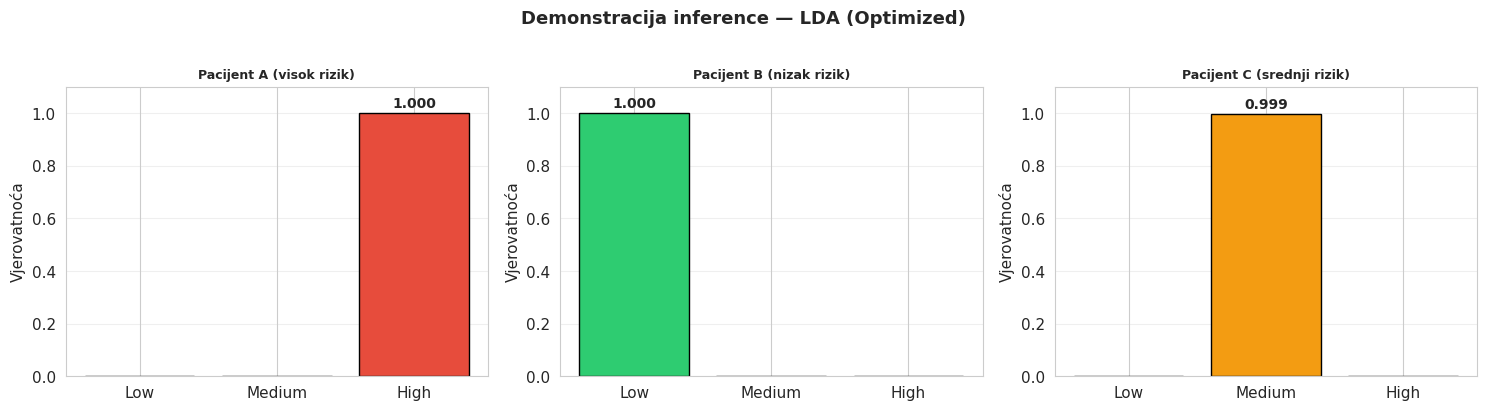

In [ ]:
# Pokazujemo kako bi model bio korišćen u praksi — za 3 hipotetička pacijenta.
# Ovo je "inference" faza: model je naučen, sada ga primjenjujemo na novim podacima.
demo = pd.DataFrame({
    'Age':                       [65,    28,    45],
    'Gender':                    [1,     2,     1],
    'Air Pollution':             [7,     2,     4],
    'Alcohol use':               [7,     1,     4],
    'Dust Allergy':              [6,     2,     5],
    'OccuPational Hazards':      [7,     1,     4],
    'Genetic Risk':              [7,     2,     5],
    'chronic Lung Disease':      [6,     1,     3],
    'Balanced Diet':             [7,     2,     4],
    'Obesity':                   [7,     1,     4],
    'Smoking':                   [8,     1,     3],
    'Passive Smoker':            [7,     1,     5],
    'Chest Pain':                [8,     1,     4],
    'Coughing of Blood':         [7,     1,     5],
    'Fatigue':                   [8,     2,     4],
    'Weight Loss':               [7,     1,     3],
    'Shortness of Breath':       [8,     2,     4],
    'Wheezing':                  [7,     1,     4],
    'Swallowing Difficulty':     [6,     1,     3],
    'Clubbing of Finger Nails':  [7,     1,     3],
    'Frequent Cold':             [5,     1,     3],
    'Dry Cough':                 [6,     2,     4],
    'Snoring':                   [5,     1,     3]
}, index=['Pacijent A (visok rizik)', 'Pacijent B (nizak rizik)', 'Pacijent C (srednji rizik)'])

preds = best_lda.predict(demo)
probas = best_lda.predict_proba(demo)

print("LDA (Optimized) — predikcija za 3 hipotetička pacijenta:\n")
for i, (label, pred, proba) in enumerate(zip(demo.index, preds, probas)):
    print(f"{label}")
    print(f"  Predviđena klasa: {CLASS_NAMES[pred]}")
    print(f"  Verovatnoće: Low={proba[0]:.3f} | Medium={proba[1]:.3f} | High={proba[2]:.3f}")
    print(f"  Sigurnost modela: {proba[pred]:.1%}\n")

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for i, (label, proba) in enumerate(zip(demo.index, probas)):
    ax = axes[i]
    bars_d = ax.bar(CLASS_NAMES, proba, color=['#2ecc71','#f39c12','#e74c3c'],
                    edgecolor='black', linewidth=1)
    ax.set_ylim(0, 1.1); ax.set_ylabel('Vjerovatnoća')
    ax.set_title(label, fontsize=9, fontweight='bold')
    ax.grid(axis='y', alpha=0.3)
    for bar, v in zip(bars_d, proba):
        if v > 0.01:
            ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.02,
                    f'{v:.3f}', ha='center', fontsize=10, fontweight='bold')
plt.suptitle('Demonstracija inference — LDA (Optimized)',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout(); plt.show()

### 11.4 Export finalnog modela

In [ ]:
# Čuvamo optimizovani LDA model i RFECV meta-informacije.
# joblib je efikasniji od pickle-a za numpy nizove.
# ISPRAVKA u odnosu na originalnu verziju: čuvamo MODEL zasebno od DICTIONARY-a.
model_path = '/content/drive/MyDrive/Colab_Notebooks/ML/Lung_Cancer_Prediction/lda_optimized_FINAL.joblib'
rfecv_meta_path = '/content/drive/MyDrive/Colab_Notebooks/ML/Lung_Cancer_Prediction/rfecv_meta_info.joblib'
stacking_path = '/content/drive/MyDrive/Colab_Notebooks/ML/Lung_Cancer_Prediction/stacking_ensemble_FINAL.joblib'

# Čuvamo modele
joblib.dump(best_lda, model_path)
joblib.dump({'n_optimal': n_opt, 'selected': selected_rfecv,
             'eliminated': elim_rfecv}, rfecv_meta_path)
joblib.dump(stacking_clf, stacking_path)

# Verifikacija: učitavamo i provjera da model radi ispravno
loaded_lda = joblib.load(model_path)
verify_acc = accuracy_score(y_test, loaded_lda.predict(X_test))
verify_f1  = f1_score(y_test, loaded_lda.predict(X_test), average='weighted')

print(f"LDA model sačuvan:       {model_path}")
print(f"RFECV meta sačuvan:      {rfecv_meta_path}")
print(f"Stacking sačuvan:        {stacking_path}")
print(f"\nVerifikacija (LDA): Accuracy={verify_acc:.4f} | F1-W={verify_f1:.4f}")
print("Export uspješan — modeli su spremni za produkcijsku upotrebu.")

LDA model sačuvan:       /content/drive/MyDrive/Colab_Notebooks/ML/Lung_Cancer_Prediction/lda_optimized_FINAL.joblib
RFECV meta sačuvan:      /content/drive/MyDrive/Colab_Notebooks/ML/Lung_Cancer_Prediction/rfecv_meta_info.joblib
Stacking sačuvan:        /content/drive/MyDrive/Colab_Notebooks/ML/Lung_Cancer_Prediction/stacking_ensemble_FINAL.joblib

Verifikacija (LDA): Accuracy=0.9750 | F1-W=0.9750
Export uspješan — modeli su spremni za produkcijsku upotrebu.
